In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from PIL import Image

In [4]:
import os
import pandas as pd

train_images_dir = "lits-256x256-folder/train_frames/train_frames"
train_masks_dir  = "lits-256x256-folder/train_masks/train_masks"

image_files = sorted([f for f in os.listdir(train_images_dir) if f.endswith('.jpg')])
mask_files  = sorted([f for f in os.listdir(train_masks_dir) if f.endswith('.tiff')])


image_paths = [os.path.join(train_images_dir, f) for f in image_files]
mask_paths  = [os.path.join(train_masks_dir, f) for f in mask_files]

train_df = pd.DataFrame({
    "image_path": image_paths,
    "mask_path": mask_paths
})

train_df

,image_path,mask_path
0,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
1,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
2,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
3,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
4,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
...,...,...
49837,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
49838,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
49839,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...
49840,lits-256x256-folder/train_frames/train_frames\...,lits-256x256-folder/train_masks/train_masks\vo...


In [5]:
import os
import pandas as pd

val_images_dir = "lits-256x256-folder/val_frames/val_frames"
val_masks_dir  = "lits-256x256-folder/val_masks/val_masks"

image_files = sorted([f for f in os.listdir(val_images_dir) if f.endswith('.jpg')])
mask_files  = sorted([f for f in os.listdir(val_masks_dir) if f.endswith('.tiff')])


image_paths = [os.path.join(val_images_dir, f) for f in image_files]
mask_paths  = [os.path.join(val_masks_dir, f) for f in mask_files]

val_df = pd.DataFrame({
    "image_path": image_paths,
    "mask_path": mask_paths
})

val_df

,image_path,mask_path
0,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
1,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
2,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
3,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
4,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
...,...,...
8791,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
8792,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
8793,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...
8794,lits-256x256-folder/val_frames/val_frames\volu...,lits-256x256-folder/val_masks/val_masks\volume...


In [ ]:
import matplotlib.patches as mpatches

LABEL_COLORS = {
    0: (0, 0, 0),       # Background - Black
    1: (255, 0, 255),   # Liver
    2: (255, 0, 0),     # Tumor: Red
}

legend_handles = [
    mpatches.Patch(color=np.array(color)/255.0, label=f"{label_id}: {name}")
    for label_id, (name, color) in zip(
        LABEL_COLORS.keys(),
        [("Background", (0,0,0)), ("Liver", (255,0,255)), ("Tumor", (255,0,0))]
    )]

def colorize_mask(mask):
    mask = np.array(mask).astype(np.uint8)
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        color_mask[mask == label] = color
    return color_mask

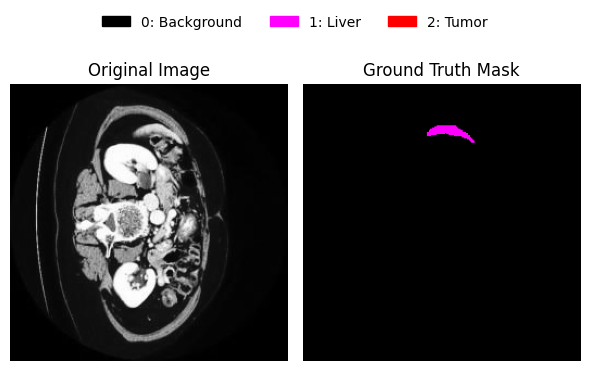

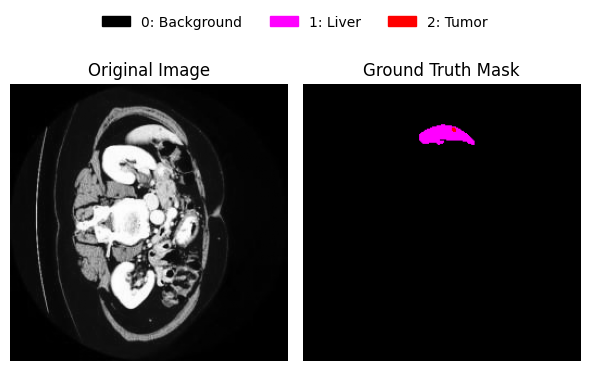

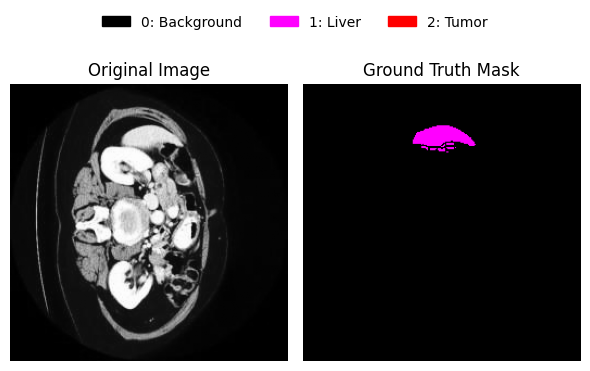

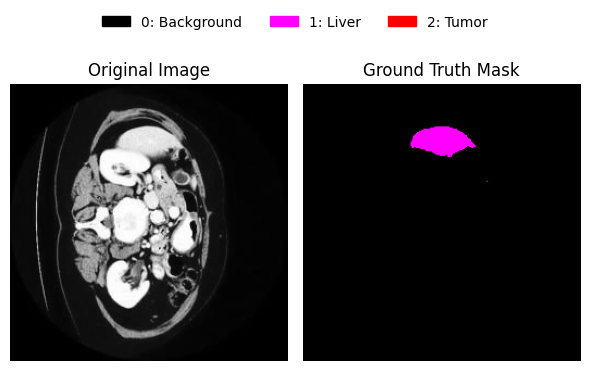

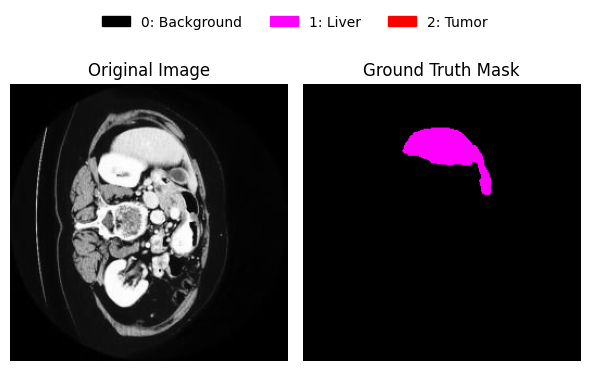

In [ ]:
count = 0
i = 0
while count < 5 and i < len(train_df):
    img_path = train_df.loc[i, "image_path"]
    mask_path = train_df.loc[i, "mask_path"]
    
    img = Image.open(img_path).convert("L")
    mask = Image.open(mask_path)
    
    mask_array = np.array(mask)
    mask_array[mask_array > 2] = 2
    
    if mask_array.max() > 0:
        colored_mask = colorize_mask(mask_array)
        
        fig, axs = plt.subplots(1, 2, figsize=(6, 4))
        
        axs[0].imshow(img, cmap='gray')
        axs[0].set_title("Original Image")
        axs[0].axis('off')
        
        axs[1].imshow(colored_mask)
        axs[1].set_title("Ground Truth Mask")
        axs[1].axis('off')
        
        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.05),
            ncol=3,
            fontsize=10,
            frameon=False
        )
        
        plt.tight_layout()
        plt.show()
        count += 1
    i += 1

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(64, 64, interpolation=0),  
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5, interpolation=0), 
    A.Normalize(mean=(0.5,), std=(0.5,)),  
    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(64, 64, interpolation=0),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [9]:
from torch.utils.data import Dataset

class LiTS(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        image = np.array(Image.open(img_path).convert("L"), dtype=np.float32) / 255.0
        image = np.expand_dims(image, axis=0)  # (1,H,W)

        mask = np.array(Image.open(mask_path), dtype=np.int64)
        mask[mask > 2] = 2
        mask = torch.from_numpy(mask)

        image = torch.from_numpy(image).float()

        if self.transform:
            augmented = self.transform(image=image.permute(1,2,0).numpy(), mask=mask.numpy())

            if isinstance(augmented['image'], torch.Tensor):
                image = augmented['image']
            else:
                image = torch.from_numpy(augmented['image']).permute(2,0,1).float()

            if isinstance(augmented['mask'], torch.Tensor):
                mask = augmented['mask']
            else:
                mask = torch.from_numpy(augmented['mask']).long()

        return image, mask

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

train_dataset = LiTS(train_df, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)

val_dataset = LiTS(val_df, transform=val_transform)
val_loader  = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

In [11]:
for images, masks in train_loader:
    print(images.shape, masks.shape)
    break

torch.Size([64, 1, 64, 64]) torch.Size([64, 64, 64])


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_att = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, stride=1, padding=(kernel_size-1)//2),
            nn.Sigmoid()
        )

    def forward(self, x):
        ca = self.channel_att(x)
        x = x * ca
        sa = torch.cat([x.max(1, keepdim=True)[0], x.mean(1, keepdim=True)], dim=1)
        sa = self.spatial_att(sa)
        x = x * sa
        return x

class ViTBlock(nn.Module):
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, num_heads=num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class ViTEncoder(nn.Module):
    def __init__(self, dim=768, num_layers=12):
        super().__init__()
        self.layers = nn.ModuleList([ViTBlock(dim) for _ in range(num_layers)])

    def forward(self, x):
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2)  
        feats = []
        for i, blk in enumerate(self.layers):
            seq = blk(seq)
            if i in [2, 5, 8, 11]:
                tmp = seq.transpose(1, 2).reshape(B, C, H, W)
                feats.append(tmp)
        return feats  

class HybridSkipAttention(nn.Module):
    def __init__(self, res_ch, vit_ch, out_ch, res_up=1, vit_up=1, num_heads=8):
        super().__init__()
        self.res_conv = nn.Conv2d(res_ch, out_ch, 3, padding=1)
        self.vit_conv = nn.Conv2d(vit_ch, out_ch, 3, padding=1)

        self.res_deconvs = nn.ModuleList([nn.ConvTranspose2d(out_ch, out_ch, 2, 2) for _ in range(res_up)])
        self.vit_deconvs = nn.ModuleList([nn.ConvTranspose2d(out_ch, out_ch, 2, 2) for _ in range(vit_up)])

        self.fuse_conv = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.cbam = CBAM(out_ch)

        self.norm1 = nn.LayerNorm(out_ch)
        self.attn  = nn.MultiheadAttention(out_ch, num_heads=num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(out_ch)
        self.mlp   = nn.Sequential(
            nn.Linear(out_ch, out_ch*4),
            nn.GELU(),
            nn.Linear(out_ch*4, out_ch)
        )

    def forward(self, res_feat, vit_feat, return_att=False):
        r = self.res_conv(res_feat)
        v = self.vit_conv(vit_feat)

        for de in self.res_deconvs: r = de(r)
        for de in self.vit_deconvs: v = de(v)

        min_h = min(r.shape[2], v.shape[2])
        min_w = min(r.shape[3], v.shape[3])
        r = r[:, :, :min_h, :min_w]
        v = v[:, :, :min_h, :min_w]

        x = r + v
        x = self.fuse_conv(x)

        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2)
        seq_attn, attn_weights = self.attn(self.norm1(seq), self.norm1(seq), self.norm1(seq))
        seq = seq + seq_attn
        seq = seq + self.mlp(self.norm2(seq))
        x = seq.transpose(1, 2).reshape(B, C, H, W)

        x = self.cbam(x)

        if return_att:
            return x, attn_weights
        else:
            return x

class BottleneckFusion(nn.Module):
    def __init__(self, res_in_ch=2048, vit_in_ch=768, out_ch=768, num_heads=8):
        super().__init__()
        self.res_up = nn.ConvTranspose2d(res_in_ch, res_in_ch, kernel_size=2, stride=2)
        self.attn_norm = nn.LayerNorm(res_in_ch)
        self.attn = nn.MultiheadAttention(res_in_ch, num_heads=num_heads, batch_first=True)
        self.vit_proj = nn.Linear(vit_in_ch, res_in_ch)
        self.conv = nn.Conv2d(res_in_ch + vit_in_ch, out_ch, 3, padding=1)

    def forward(self, res4, vit12):
        r = self.res_up(res4)

        min_h = min(r.shape[2], vit12.shape[2])
        min_w = min(r.shape[3], vit12.shape[3])
        r = r[:, :, :min_h, :min_w]
        vit12 = vit12[:, :, :min_h, :min_w]

        B, C_r, H, W = r.shape
        r_seq = r.flatten(2).transpose(1, 2)     
        vit_seq = vit12.flatten(2).transpose(1, 2) 

        vit_seq_proj = self.vit_proj(vit_seq)     

        r_seq_norm = self.attn_norm(r_seq)
        attn_out, _ = self.attn(r_seq_norm, vit_seq_proj, vit_seq_proj)
        r_seq = r_seq + attn_out

        r = r_seq.transpose(1, 2).reshape(B, C_r, H, W)

        x = torch.cat([r, vit12], dim=1)
        x = self.conv(x)
        return x

class SegmentationModel(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.DEFAULT)

        old_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=old_conv1.out_channels,
            kernel_size=old_conv1.kernel_size,
            stride=old_conv1.stride,
            padding=old_conv1.padding,
            bias=False
        )
        with torch.no_grad():
            backbone.conv1.weight[:] = old_conv1.weight.mean(dim=1, keepdim=True)

        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # 256 ch
        self.layer2 = backbone.layer2   # 512 ch
        self.layer3 = backbone.layer3   # 1024 ch
        self.layer4 = backbone.layer4   # 2048 ch

        self.l3_to_vit = nn.Sequential(
            nn.Conv2d(1024, 768, 3, padding=1),
            nn.Conv2d(768, 768, 3, padding=1)
        )

        self.vit = ViTEncoder(dim=768, num_layers=12)
        self.bottleneck = BottleneckFusion(res_in_ch=2048, vit_in_ch=768, out_ch=768)

        self.up1 = nn.ConvTranspose2d(768, 512, 2, 2)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.up4 = nn.ConvTranspose2d(128,  64, 2, 2)

        self.skip1 = HybridSkipAttention(res_ch=1024, vit_ch=768, out_ch=512, res_up=1, vit_up=1)
        self.skip2 = HybridSkipAttention(res_ch=512,  vit_ch=768, out_ch=256, res_up=1, vit_up=2)
        self.skip3 = HybridSkipAttention(res_ch=256,  vit_ch=768, out_ch=128, res_up=1, vit_up=3)

        self.input_skip = nn.Conv2d(1, 64, 3, padding=1)

        self.final_conv = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        # x: [B,1,H,W]
        l0 = self.stem(x)        # [B,64,H/4,W/4]
        l1 = self.layer1(l0)     # [B,256,]
        l2 = self.layer2(l1)     # [B,512,]
        l3 = self.layer3(l2)     # [B,1024,]
        l4 = self.layer4(l3)     # [B,2048,]

        vit_in = self.l3_to_vit(l3)                   
        vit_L3, vit_L6, vit_L9, vit_L12 = self.vit(vit_in)

        b = self.bottleneck(l4, vit_L12)                 

        up1 = self.up1(b)   + self.skip1(l3, vit_L9)      
        up2 = self.up2(up1) + self.skip2(l2, vit_L6)      
        up3 = self.up3(up2) + self.skip3(l1, vit_L3)      
        up4 = self.up4(up3) + self.input_skip(x)          

        out = self.final_conv(up4)                     
        return out

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SegmentationModel(num_classes=3).to(device)

In [14]:
import torch
import torch.nn.functional as F
import numpy as np
from medpy.metric.binary import hd

class metrics:
    @staticmethod
    def dice(preds, targets, eps=1e-7):
        preds_onehot = F.one_hot(preds.argmax(dim=1), num_classes=preds.shape[1]).permute(0,3,1,2).float()
        targets_onehot = F.one_hot(targets, num_classes=preds.shape[1]).permute(0,3,1,2).float()
        intersection = (preds_onehot * targets_onehot).sum(dim=(0,2,3))
        union = preds_onehot.sum(dim=(0,2,3)) + targets_onehot.sum(dim=(0,2,3))
        dice = (2. * intersection + eps) / (union + eps)
        return dice.mean().item()

    @staticmethod
    def iou(preds, targets, eps=1e-7):
        preds_onehot = F.one_hot(preds.argmax(dim=1), num_classes=preds.shape[1]).permute(0,3,1,2).float()
        targets_onehot = F.one_hot(targets, num_classes=preds.shape[1]).permute(0,3,1,2).float()
        intersection = (preds_onehot * targets_onehot).sum(dim=(0,2,3))
        union = (preds_onehot + targets_onehot - preds_onehot * targets_onehot).sum(dim=(0,2,3))
        iou = (intersection + eps) / (union + eps)
        return iou.mean().item()

    @staticmethod
    def pixel_accuracy(preds, targets):
        return (preds.argmax(dim=1) == targets).float().mean().item()

    @staticmethod
    def precision_recall_f1(preds, targets, eps=1e-7):
        preds_onehot = F.one_hot(preds.argmax(dim=1), num_classes=preds.shape[1]).permute(0,3,1,2).float()
        targets_onehot = F.one_hot(targets, num_classes=preds.shape[1]).permute(0,3,1,2).float()
        
        tp = (preds_onehot * targets_onehot).sum(dim=(0,2,3))
        fp = (preds_onehot * (1 - targets_onehot)).sum(dim=(0,2,3))
        fn = ((1 - preds_onehot) * targets_onehot).sum(dim=(0,2,3))
        
        precision = (tp + eps) / (tp + fp + eps)
        recall = (tp + eps) / (tp + fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        
        return {"precision": precision.mean().item(),
                "recall": recall.mean().item(),
                "f1": f1.mean().item()}

    @staticmethod
    def hausdorff_distance(preds, targets):
        preds_onehot = F.one_hot(preds.argmax(dim=1), num_classes=preds.shape[1]).permute(0,3,1,2).float()
        targets_onehot = F.one_hot(targets, num_classes=preds.shape[1]).permute(0,3,1,2).float()
        distances = []
        for b in range(preds_onehot.shape[0]):
            for c in range(preds_onehot.shape[1]):
                p = preds_onehot[b,c].cpu().numpy().astype(bool)
                t = targets_onehot[b,c].cpu().numpy().astype(bool)
                if p.sum() == 0 or t.sum() == 0:
                    distances.append(np.nan)
                else:
                    try:
                        distances.append(hd(p, t))
                    except:
                        distances.append(np.nan)
        return np.nanmean(distances)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim


class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super(DiceLoss, self).__init__()
        self.eps = eps

    def forward(self, preds, targets):
        num_classes = preds.shape[1]
        preds = F.softmax(preds, dim=1)
        preds_one_hot = F.one_hot(preds.argmax(dim=1), num_classes=num_classes).permute(0,3,1,2).float()
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).permute(0,3,1,2).float()

        intersection = (preds_one_hot * targets_one_hot).sum(dim=(0,2,3))
        union = preds_one_hot.sum(dim=(0,2,3)) + targets_one_hot.sum(dim=(0,2,3))
        dice = (2. * intersection + self.eps) / (union + self.eps)
        return 1 - dice.mean()

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss()

def combined_loss(outputs, targets, ce_weight=0.5, dice_weight=0.5):
    return ce_weight * ce_loss(outputs, targets) + dice_weight * dice_loss(outputs, targets)

criterion = combined_loss
optimizer = torch.optim.RAdam(model.parameters(), lr=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

In [16]:
from tqdm import tqdm

train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_accs, val_accs = [], []
train_ious, val_ious = [], []
train_hd_list, val_hd_list = [], []
train_precisions, val_precisions = [], []
train_recalls, val_recalls = [], []
train_f1s, val_f1s = [], []

num_epochs = 2500
for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_acc = 0.0
    train_iou = 0.0
    train_hd = 0.0
    train_precision = 0.0
    train_recall = 0.0
    train_f1 = 0.0

    for images, masks in tqdm(train_loader):
        # images, masks = images.to(device), masks.to(device)
        images, masks = images.to(device), masks.to(device).long()  


        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += metrics.dice(outputs, masks)
        train_acc += metrics.pixel_accuracy(outputs, masks)
        train_iou += metrics.iou(outputs, masks)
        train_hd += metrics.hausdorff_distance(outputs, masks)

        prf = metrics.precision_recall_f1(outputs, masks)
        train_precision += prf["precision"]
        train_recall += prf["recall"]
        train_f1 += prf["f1"]

    n_train = len(train_loader)
    avg_train_loss = train_loss / n_train
    avg_train_dice = train_dice / n_train
    avg_train_acc = train_acc / n_train
    avg_train_iou = train_iou / n_train
    avg_train_hd = train_hd / n_train
    avg_train_precision = train_precision / n_train
    avg_train_recall = train_recall / n_train
    avg_train_f1 = train_f1 / n_train

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_acc = 0.0
    val_iou = 0.0
    val_hd = 0.0
    val_precision = 0.0
    val_recall = 0.0
    val_f1 = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader):
            # images, masks = images.to(device), masks.to(device)
            images, masks = images.to(device), masks.to(device).long()  

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_dice += metrics.dice(outputs, masks)
            val_acc += metrics.pixel_accuracy(outputs, masks)
            val_iou += metrics.iou(outputs, masks)
            val_hd += metrics.hausdorff_distance(outputs, masks)

            prf = metrics.precision_recall_f1(outputs, masks)
            val_precision += prf["precision"]
            val_recall += prf["recall"]
            val_f1 += prf["f1"]

    n_val = len(val_loader)
    avg_val_loss = val_loss / n_val
    avg_val_dice = val_dice / n_val
    avg_val_acc = val_acc / n_val
    avg_val_iou = val_iou / n_val
    avg_val_hd = val_hd / n_val
    avg_val_precision = val_precision / n_val
    avg_val_recall = val_recall / n_val
    avg_val_f1 = val_f1 / n_val

    # save history
    train_losses.append(avg_train_loss); val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice); val_dices.append(avg_val_dice)
    train_accs.append(avg_train_acc); val_accs.append(avg_val_acc)
    train_ious.append(avg_train_iou); val_ious.append(avg_val_iou)
    train_hd_list.append(avg_train_hd); val_hd_list.append(avg_val_hd)
    train_precisions.append(avg_train_precision); val_precisions.append(avg_val_precision)
    train_recalls.append(avg_train_recall); val_recalls.append(avg_val_recall)
    train_f1s.append(avg_train_f1); val_f1s.append(avg_val_f1)

    print(f"Epoch {epoch:2d} | "
          f"Train Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | Acc: {avg_train_acc:.4f} | "
          f"IoU: {avg_train_iou:.4f} | Precision: {avg_train_precision:.4f} | Recall: {avg_train_recall:.4f} | F1: {avg_train_f1:.4f} | HD: {avg_train_hd:.2f} || "
          f"Val Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | Acc: {avg_val_acc:.4f} | "
          f"IoU: {avg_val_iou:.4f} | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | F1: {avg_val_f1:.4f} | HD: {avg_val_hd:.2f}")

100%|████████████████████████████████████████████████████████████████████████████████| 138/138 [00:34<00:00,  4.01it/s]


Epoch  1 | Train Loss: 0.4279 | Dice: 0.3500 | Acc: 0.9264 | IoU: 0.3297 | Precision: 0.8286 | Recall: 0.3553 | F1: 0.3500 | HD: 11.07 || Val Loss: 0.2581 | Dice: 0.5396 | Acc: 0.9804 | IoU: 0.5029 | Precision: 0.9189 | Recall: 0.5211 | F1: 0.5396 | HD: 6.84


100%|████████████████████████████████████████████████████████████████████████████████| 138/138 [00:35<00:00,  3.89it/s]


Epoch  2 | Train Loss: 0.2585 | Dice: 0.5288 | Acc: 0.9844 | IoU: 0.4708 | Precision: 0.9018 | Recall: 0.5036 | F1: 0.5288 | HD: 5.95 || Val Loss: 0.2107 | Dice: 0.6215 | Acc: 0.9854 | IoU: 0.5738 | Precision: 0.8652 | Recall: 0.6481 | F1: 0.6215 | HD: 6.07


100%|████████████████████████████████████████████████████████████████████████████████| 138/138 [00:35<00:00,  3.93it/s]


...

Epoch 231 | Train Loss: 0.0202 | Dice: 0.9620 | Acc: 0.9990 | IoU: 0.9306 | Precision: 0.9661 | Recall: 0.9588 | F1: 0.9620 | HD: 0.85 || Val Loss: 0.0341 | Dice: 0.9349 | Acc: 0.9989 | IoU: 0.9029 | Precision: 0.9530 | Recall: 0.9349 | F1: 0.9349 | HD: 0.88


100%|████████████████████████████████████████████████████████████████████████████████| 138/138 [00:35<00:00,  3.87it/s]


Epoch 232 | Train Loss: 0.0206 | Dice: 0.9613 | Acc: 0.9990 | IoU: 0.9296 | Precision: 0.9655 | Recall: 0.9578 | F1: 0.9613 | HD: 0.85 || Val Loss: 0.0258 | Dice: 0.9510 | Acc: 0.9990 | IoU: 0.9222 | Precision: 0.9585 | Recall: 0.9487 | F1: 0.9510 | HD: 0.81


  6%|█████                                                                            | 49/779 [00:20<05:02,  2.41it/s]


KeyboardInterrupt: 

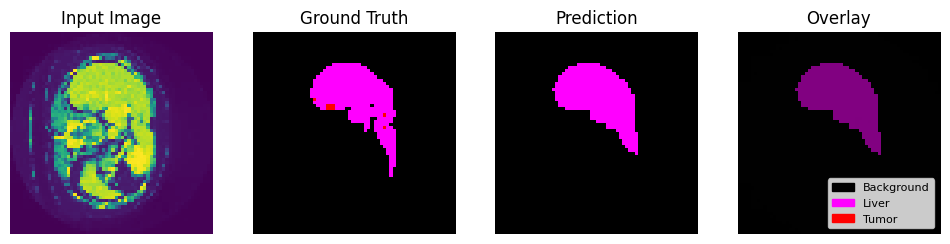

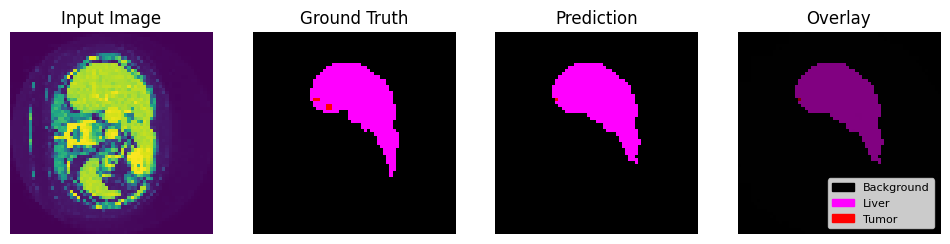

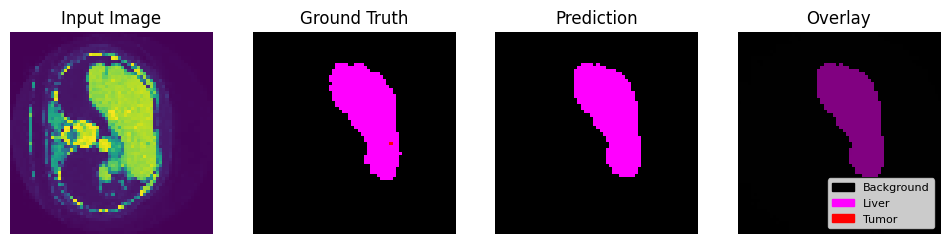

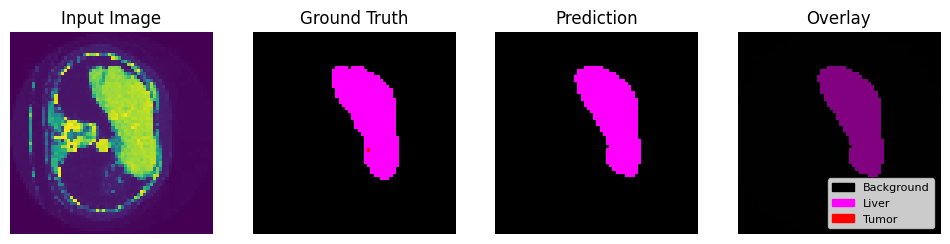

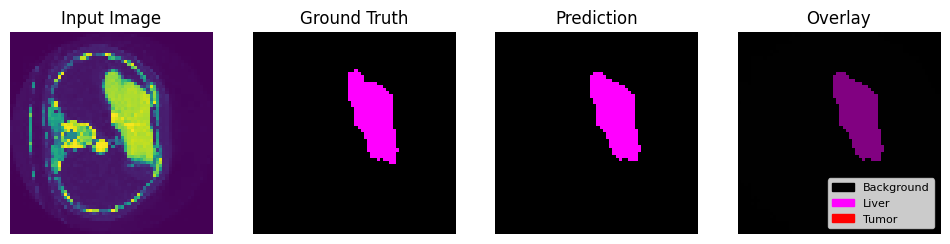

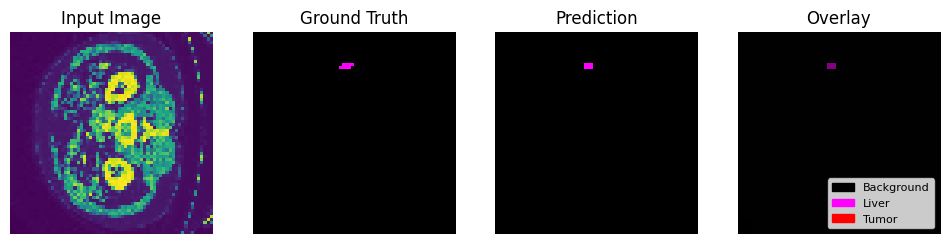

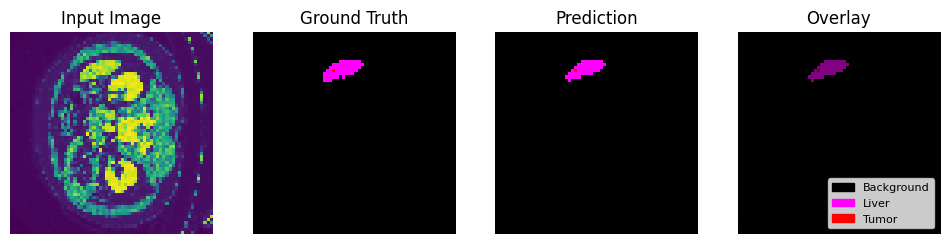

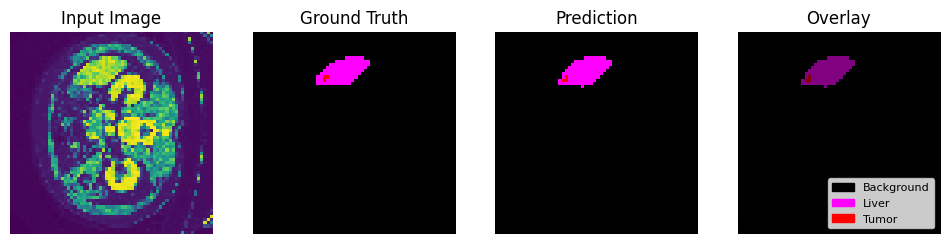

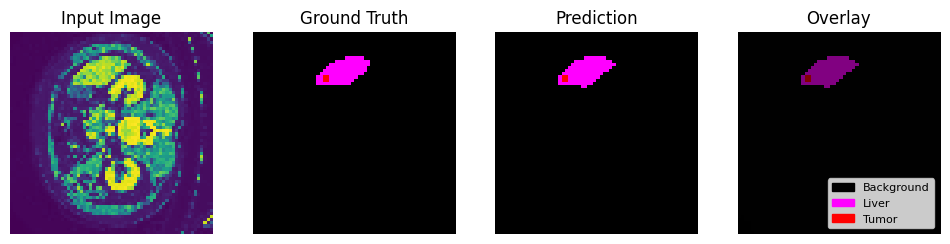

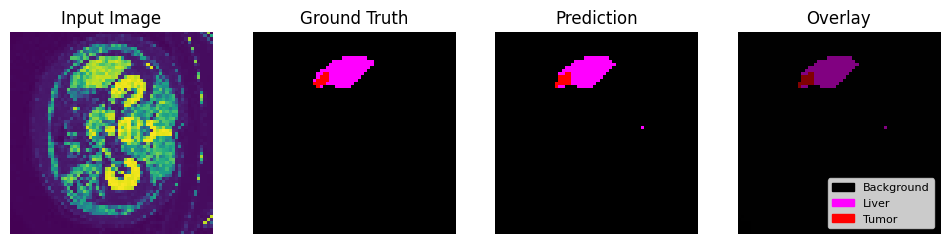

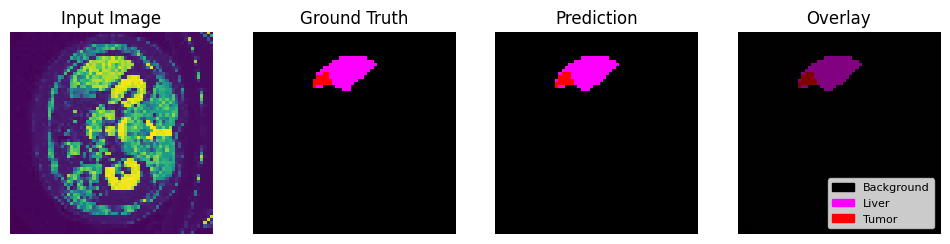

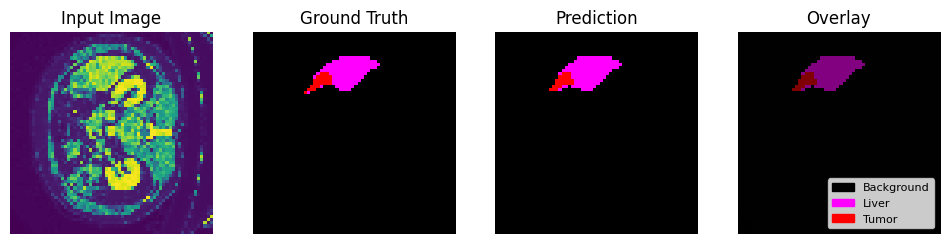

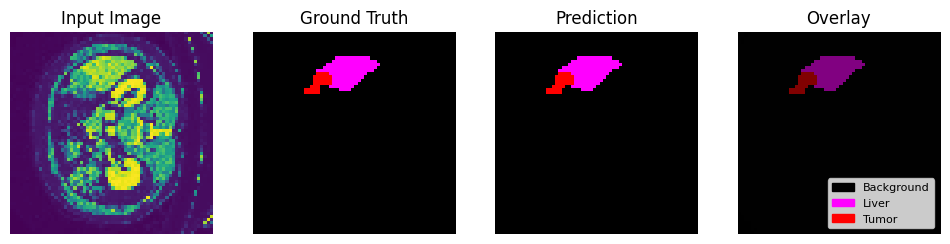

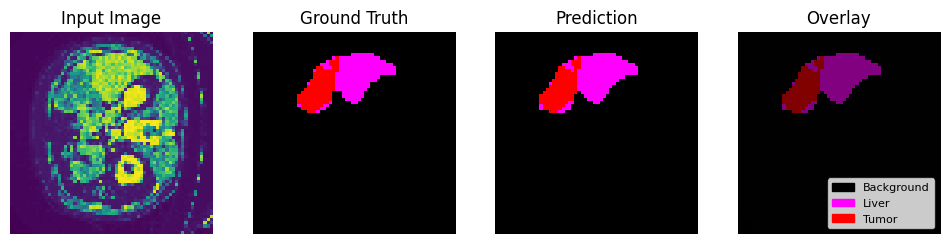

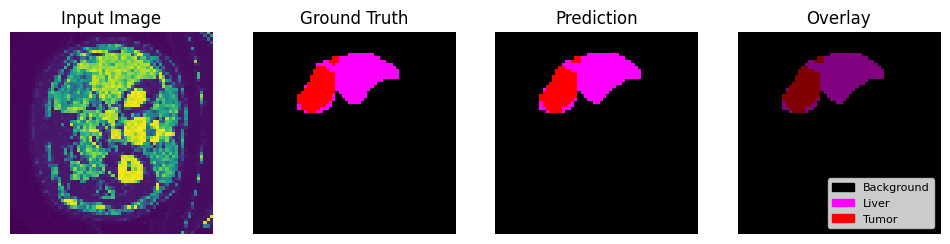

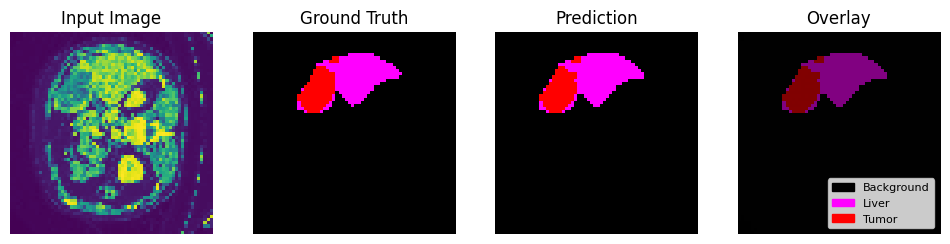

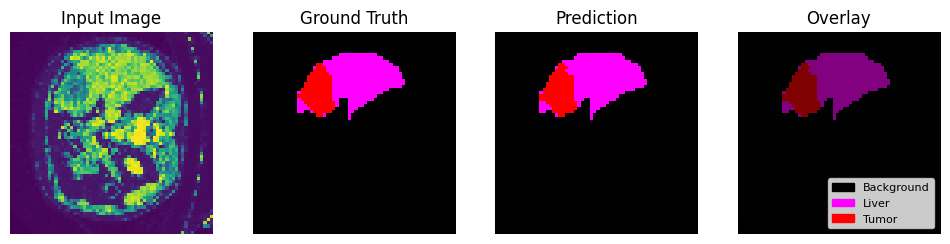

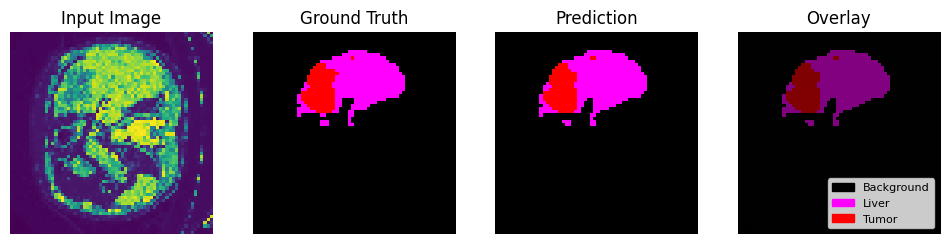

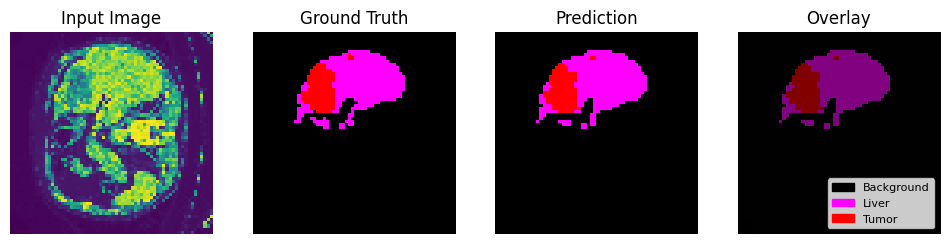

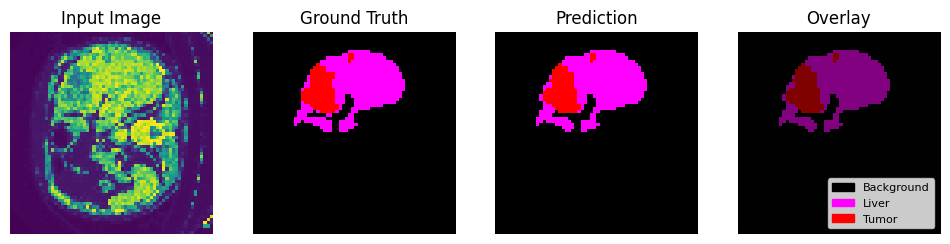

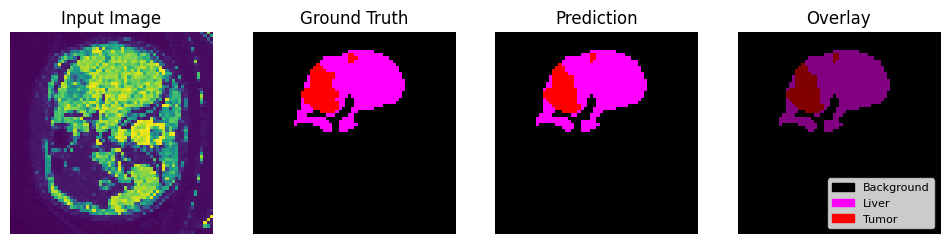

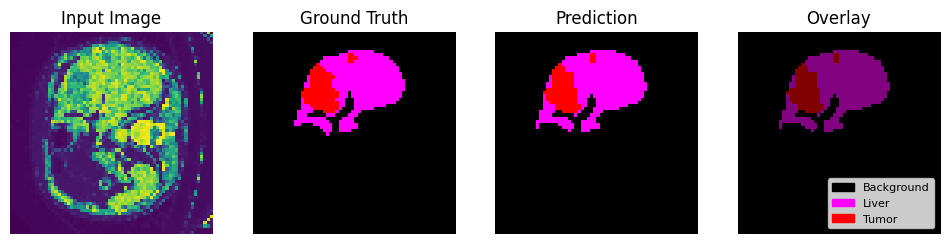

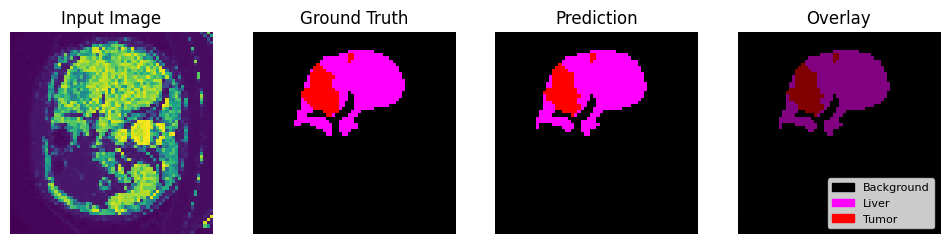

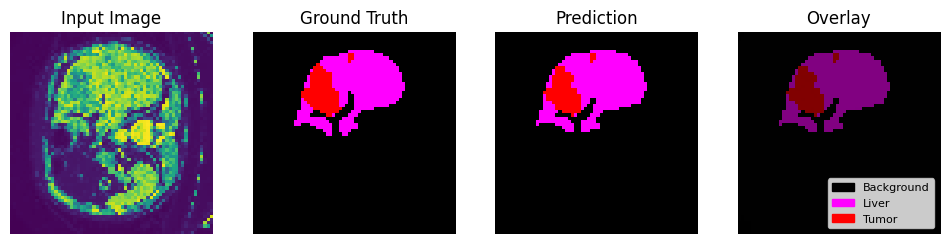

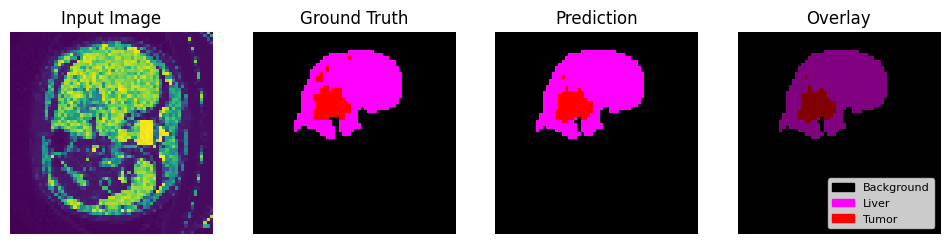

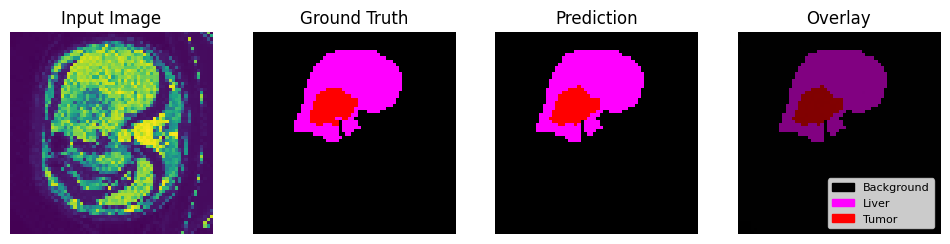

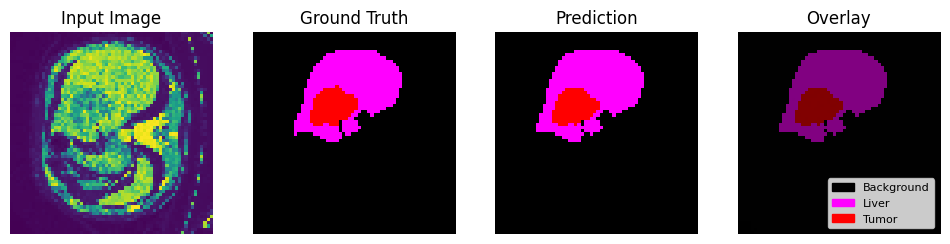

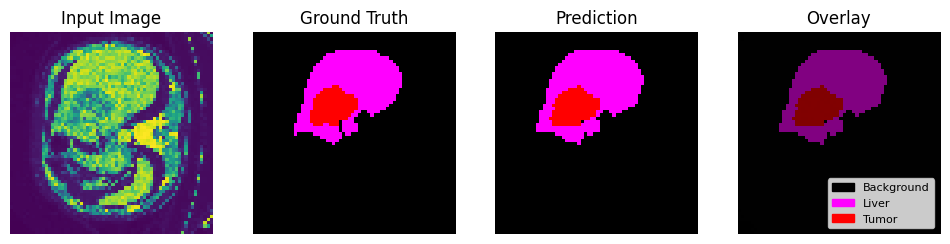

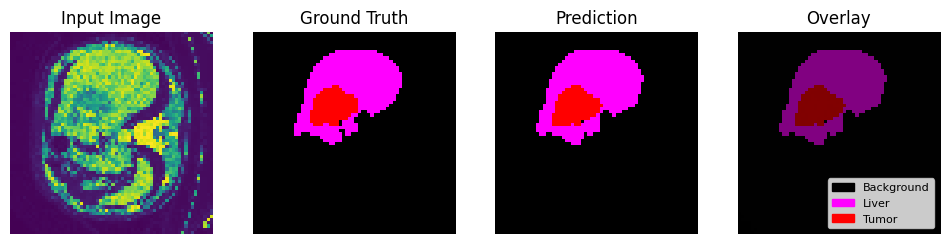

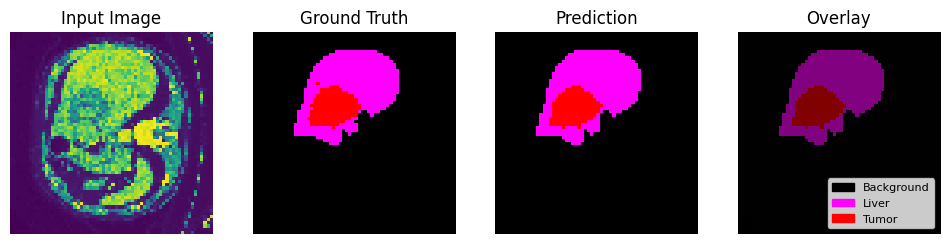

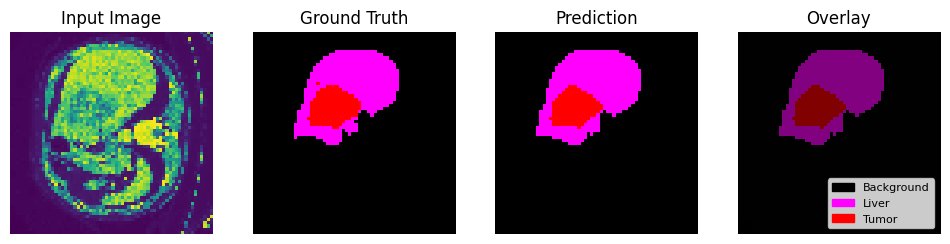

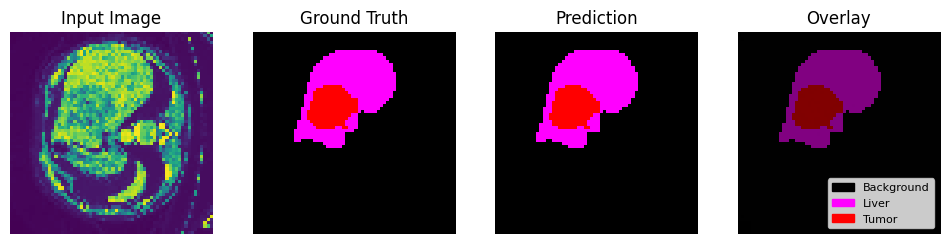

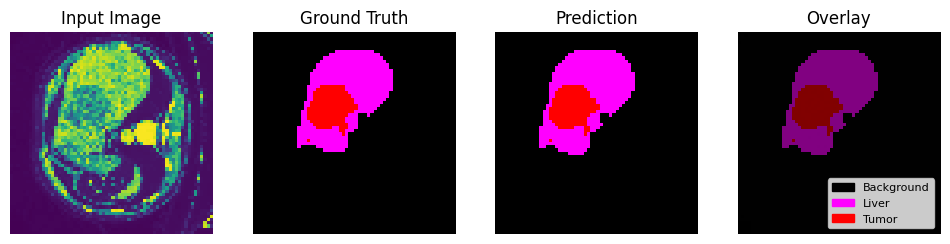

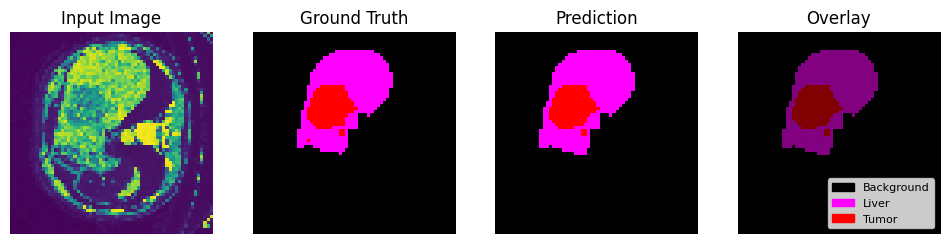

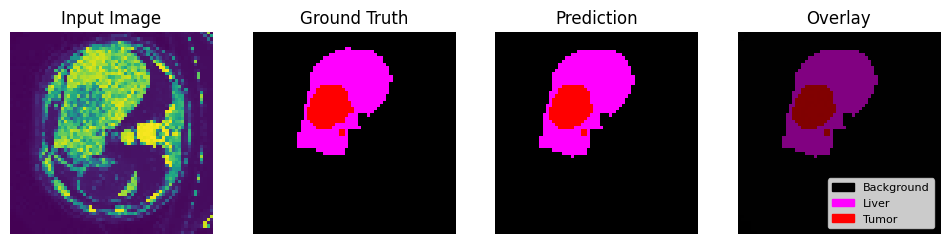

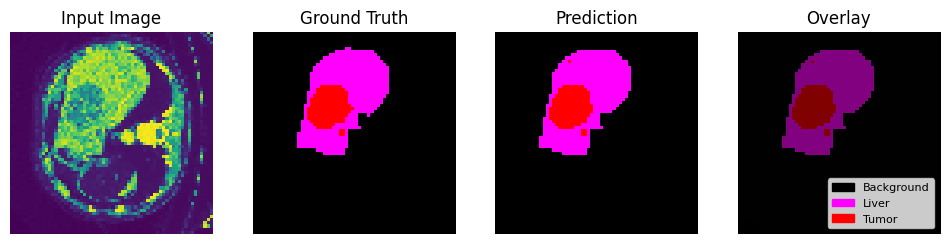

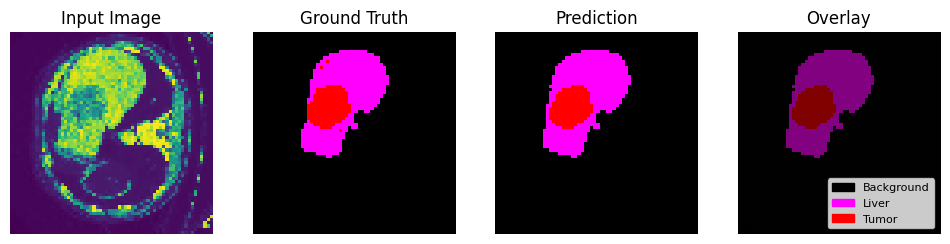

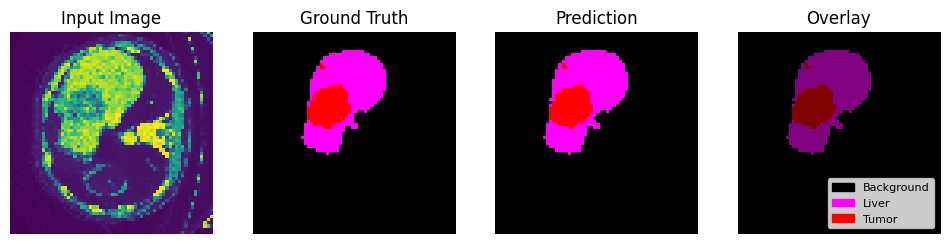

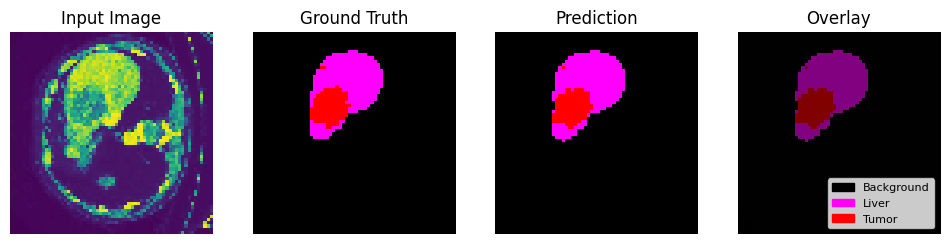

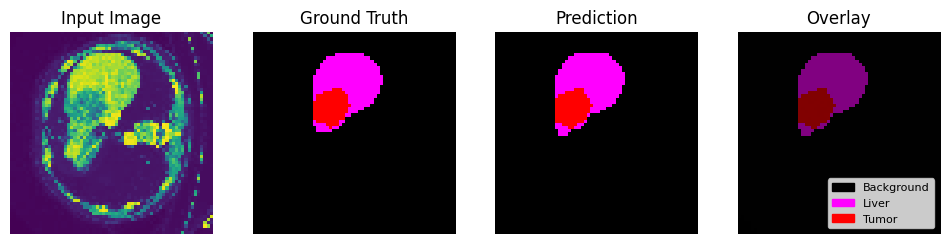

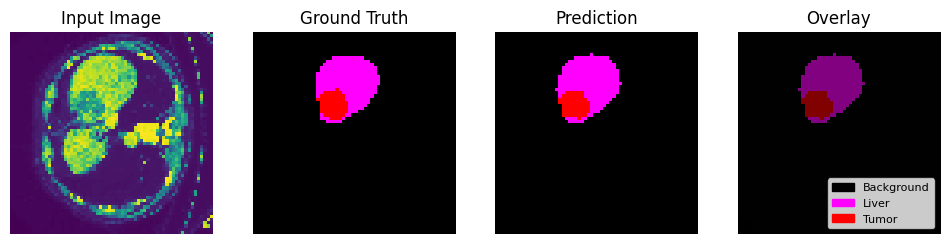

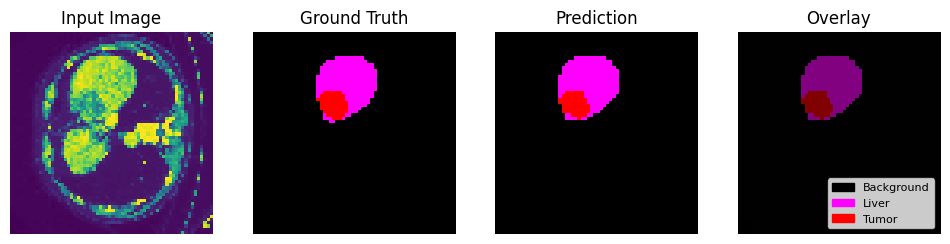

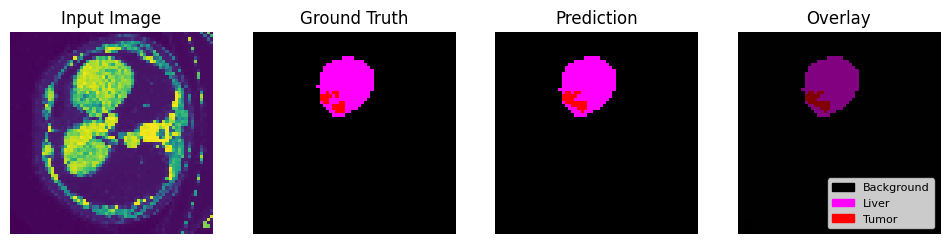

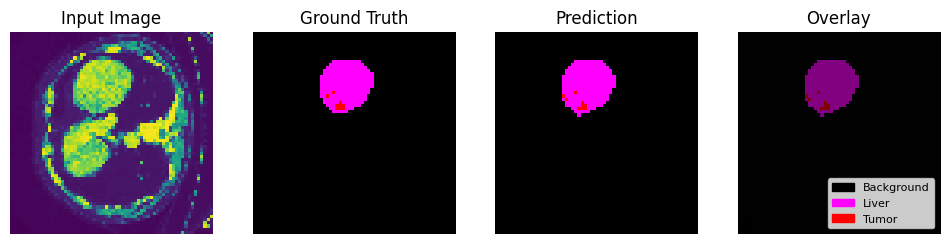

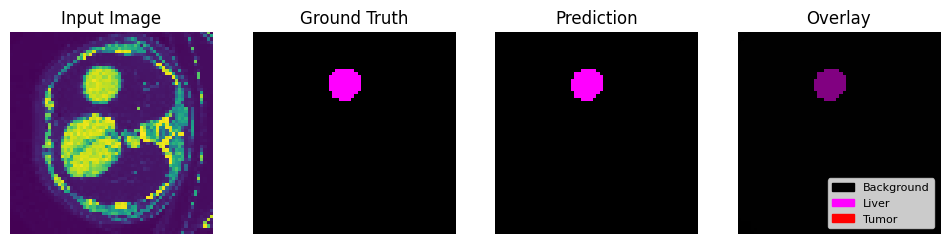

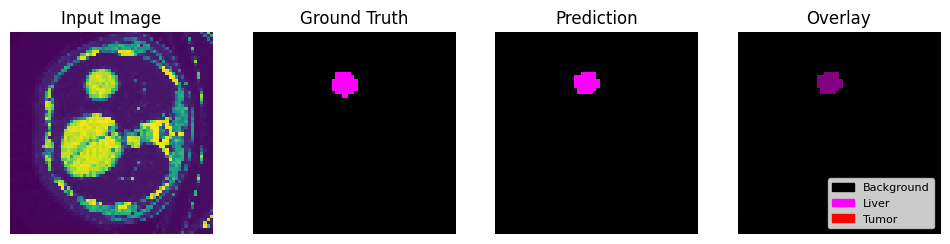

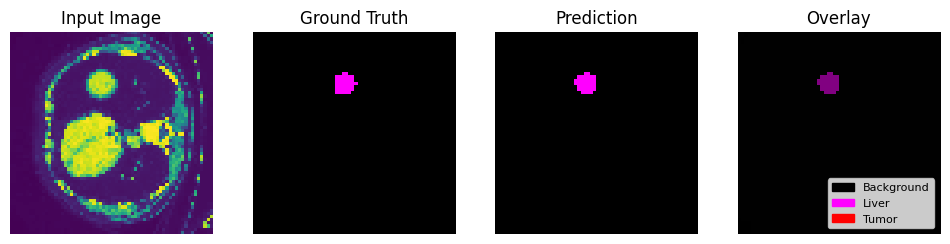

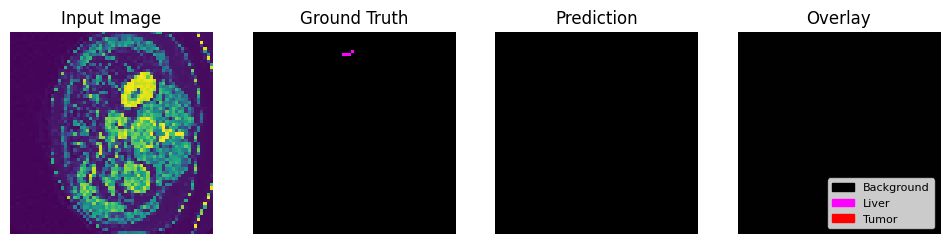

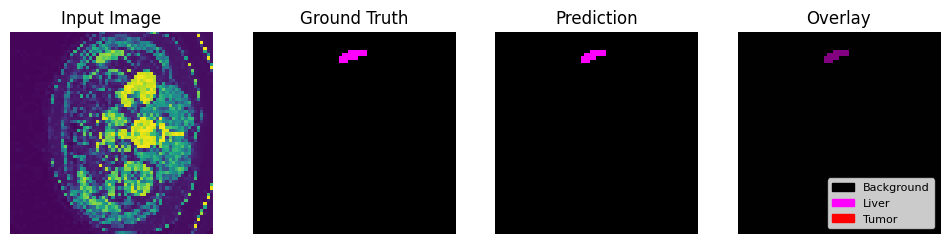

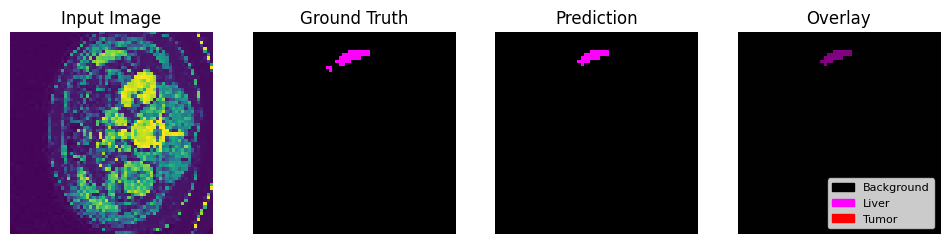

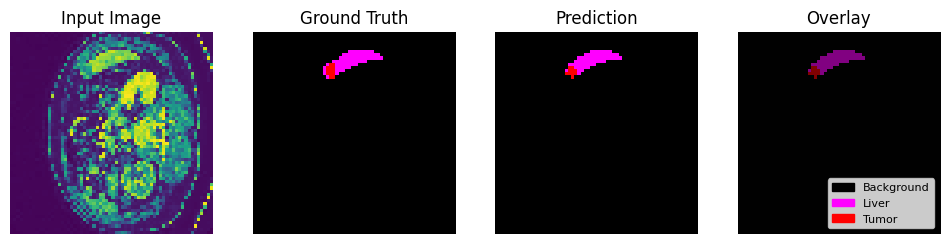

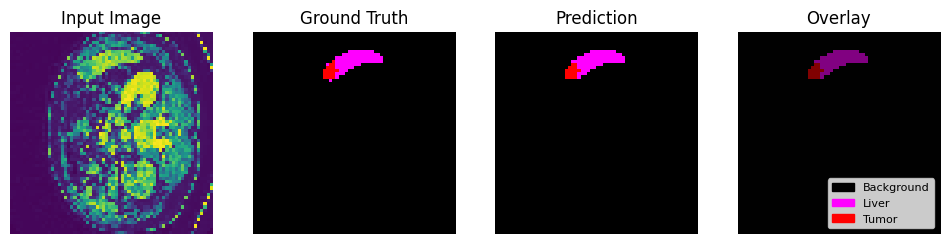

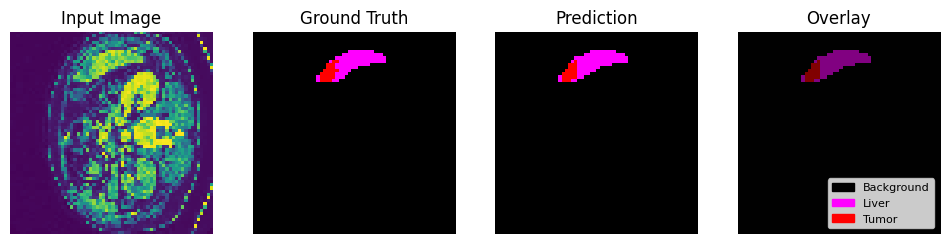

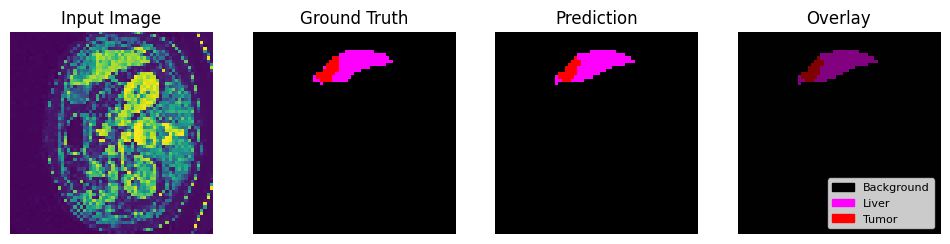

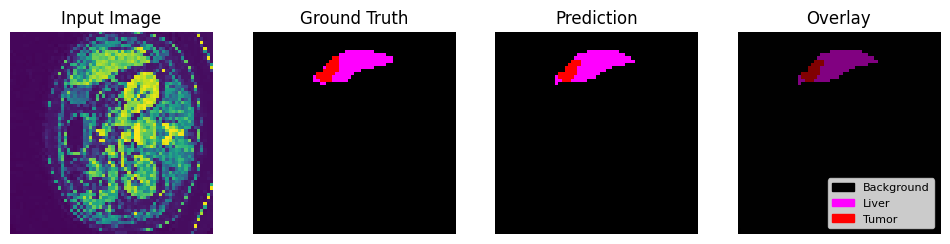

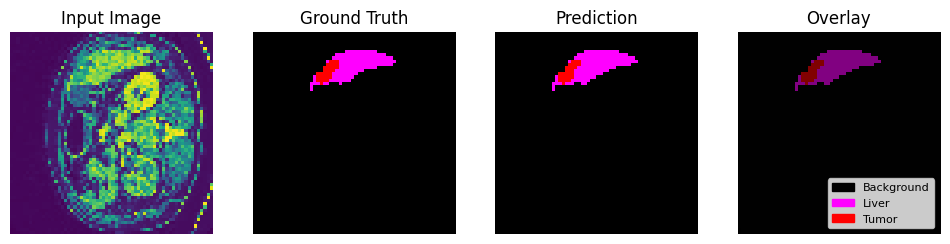

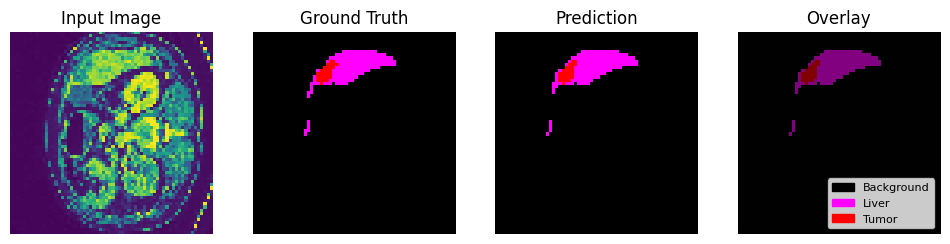

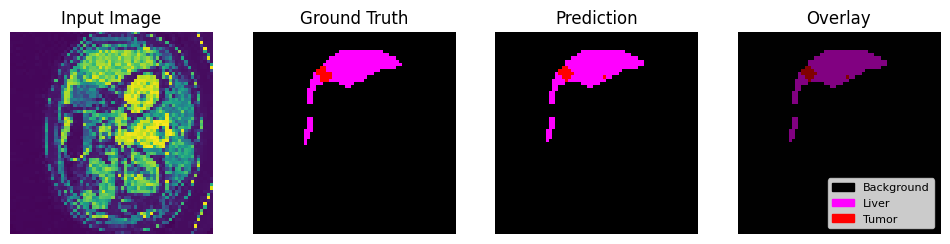

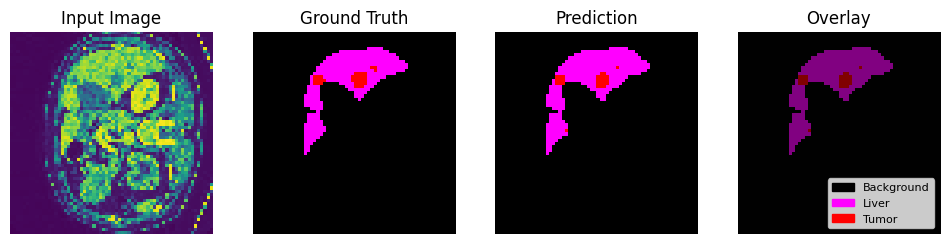

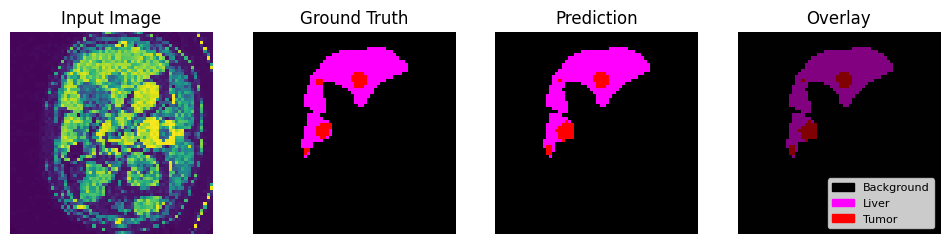

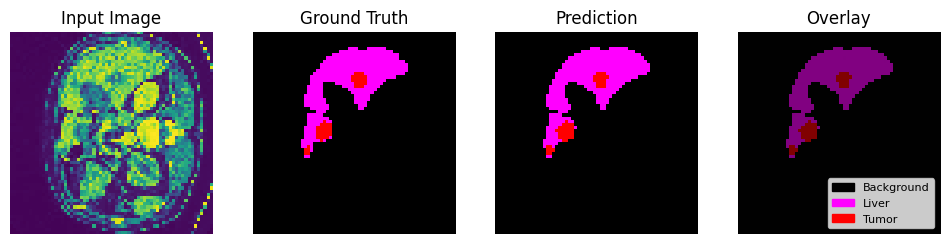

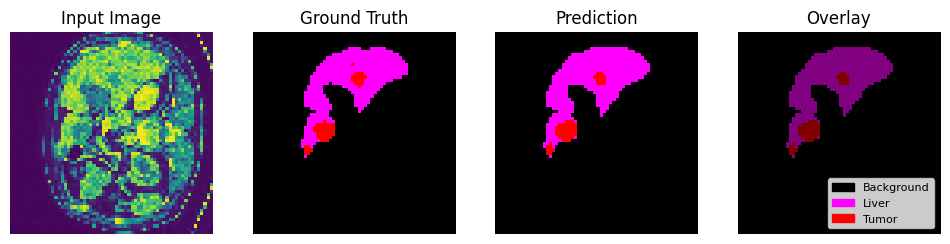

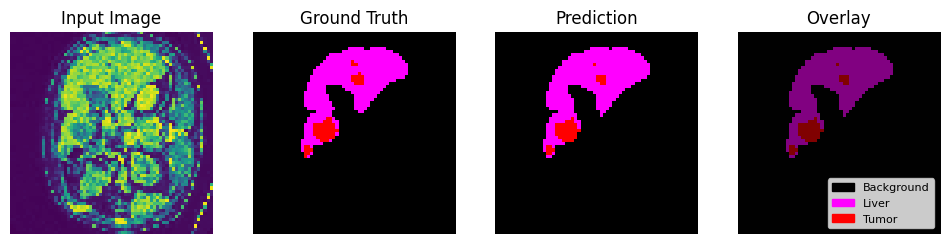

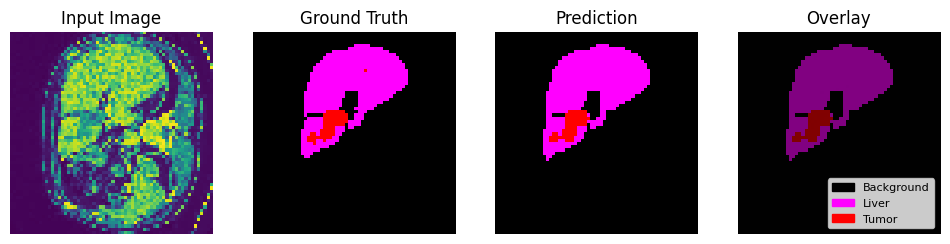

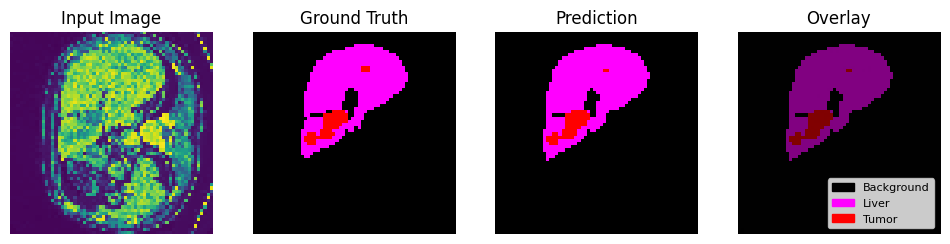

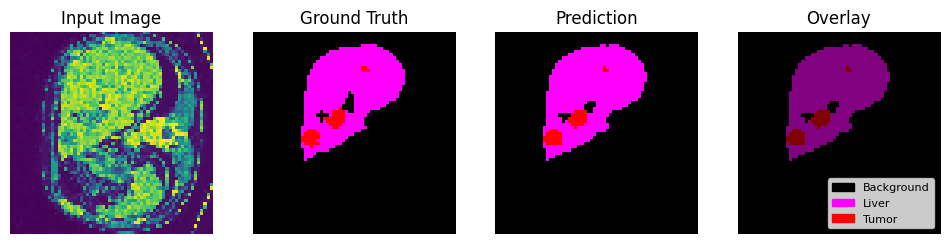

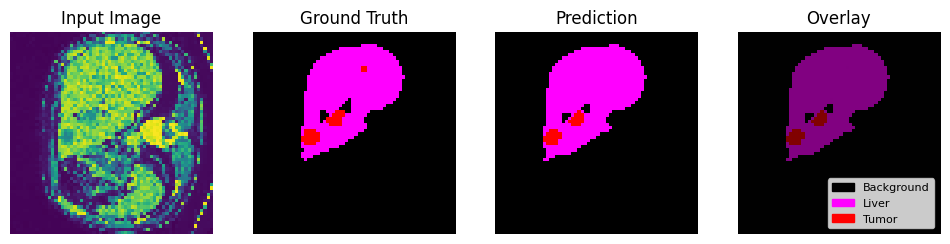

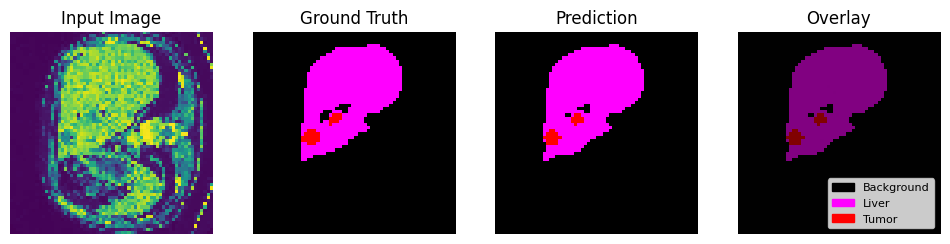

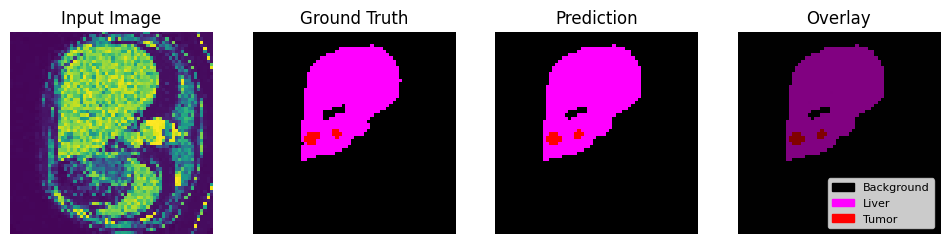

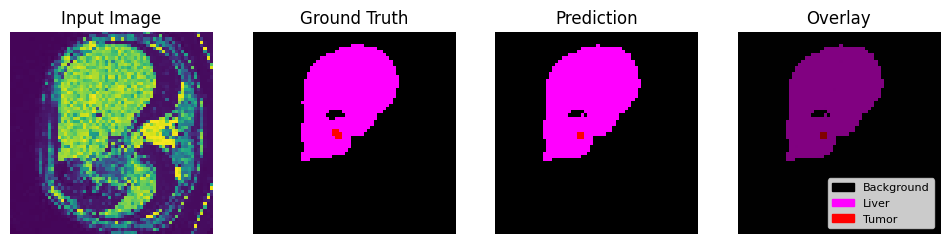

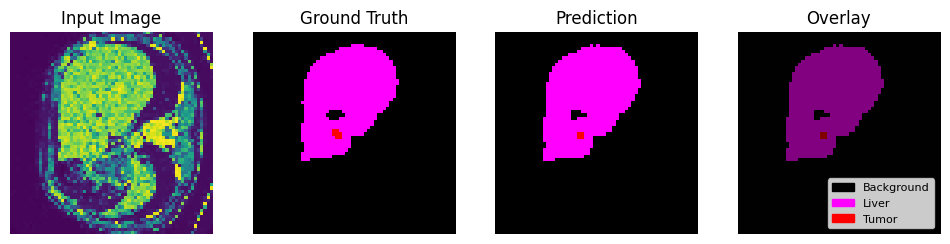

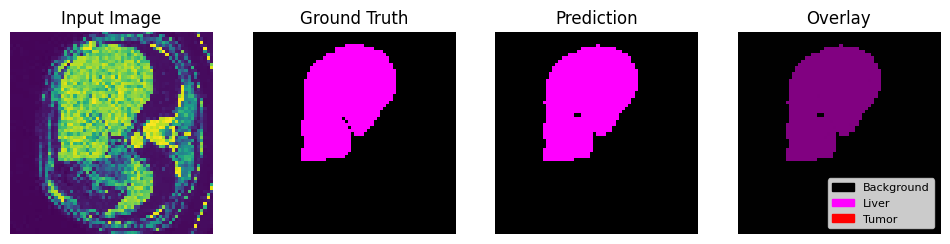

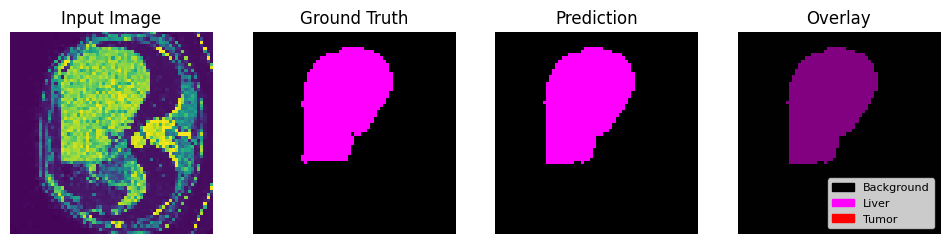

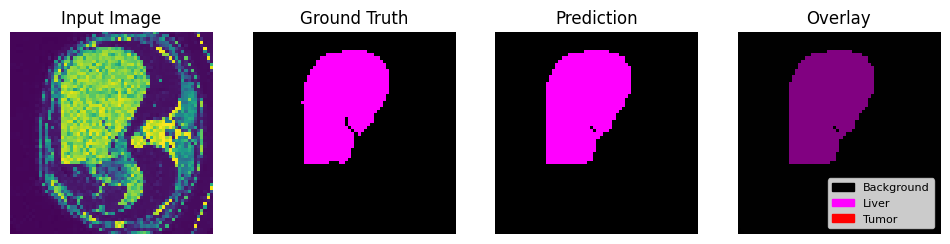

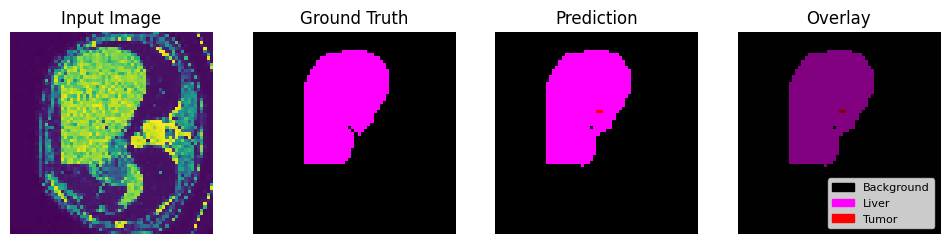

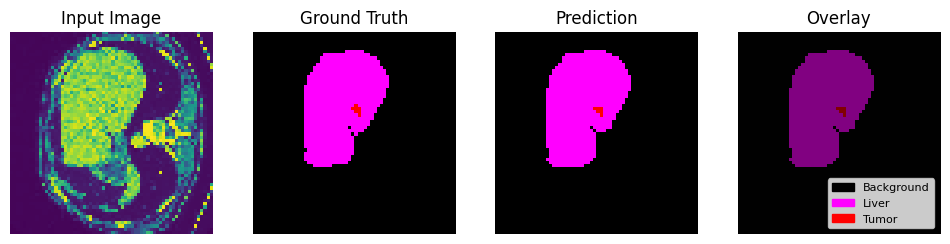

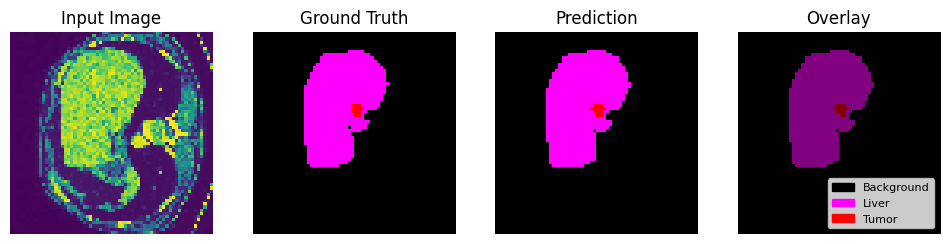

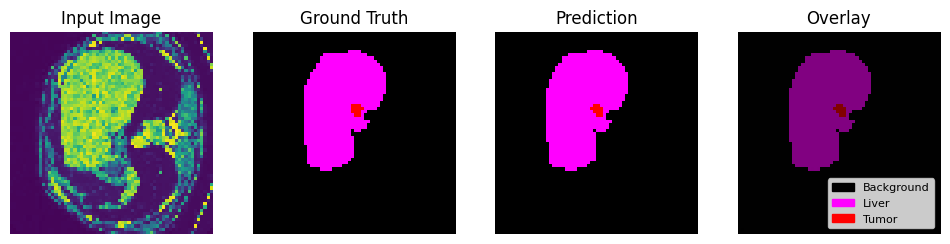

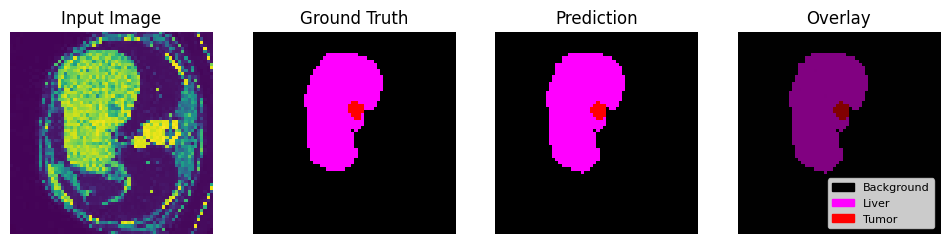

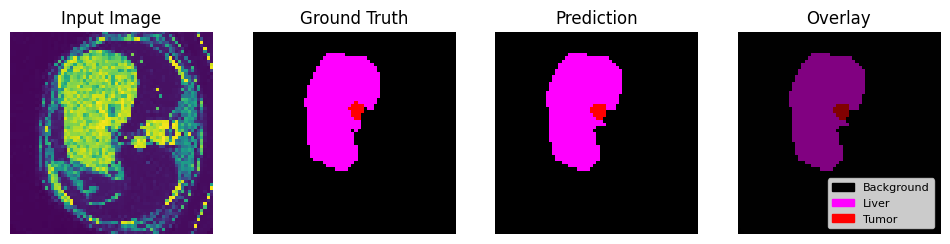

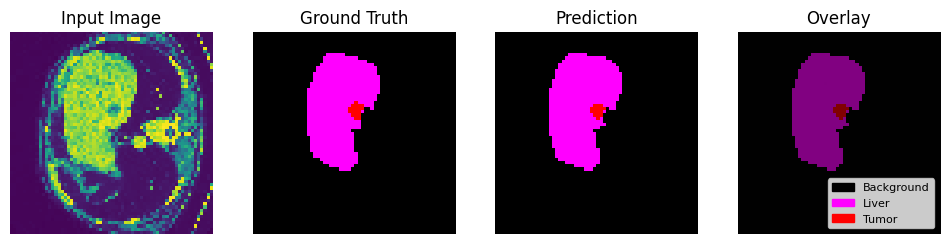

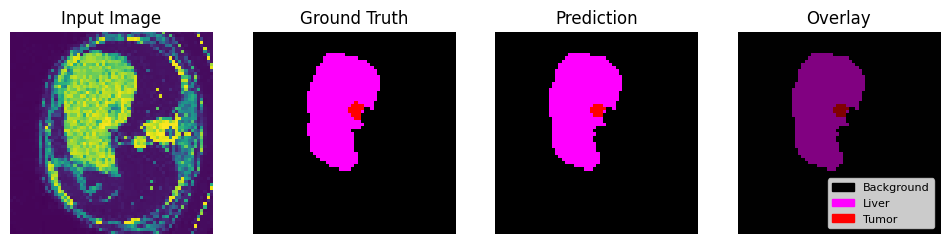

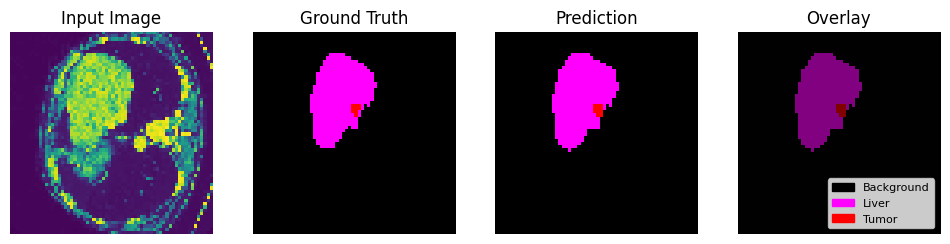

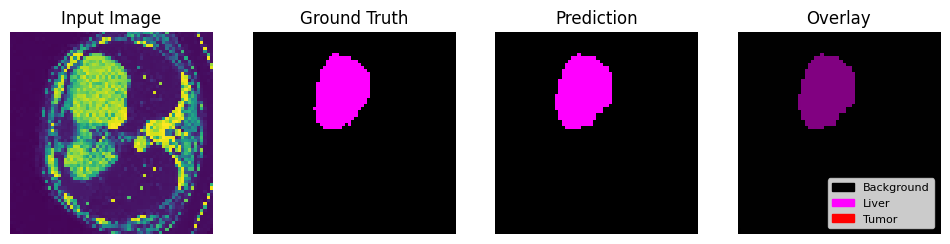

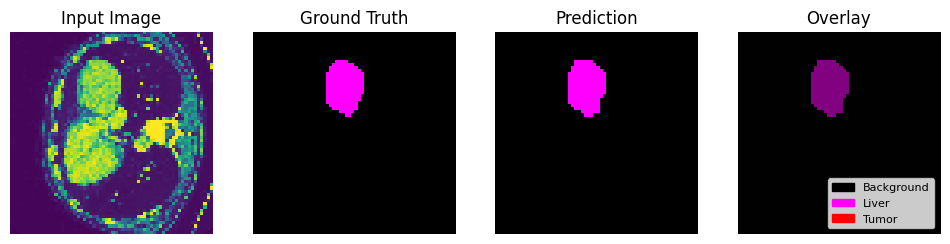

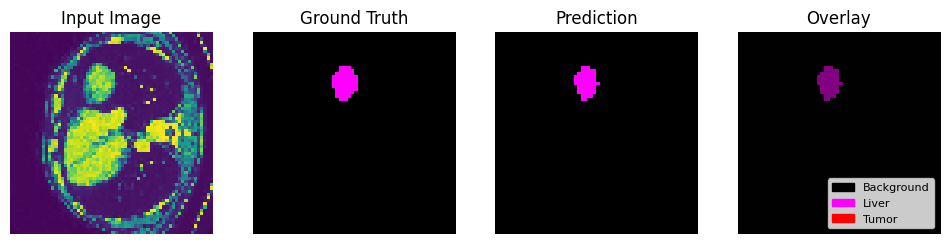

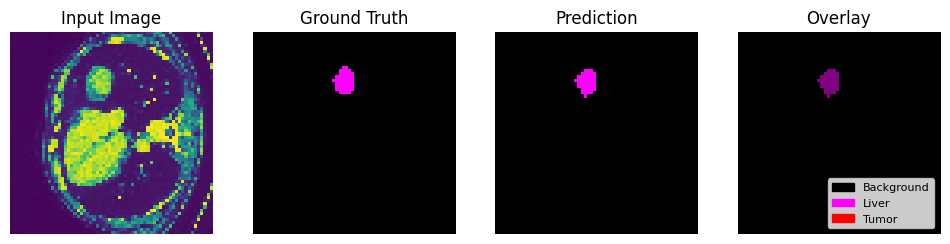

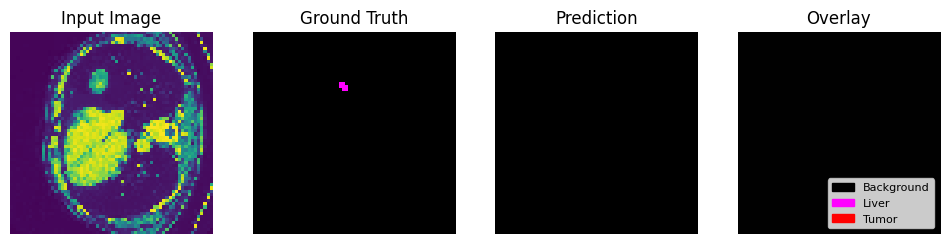

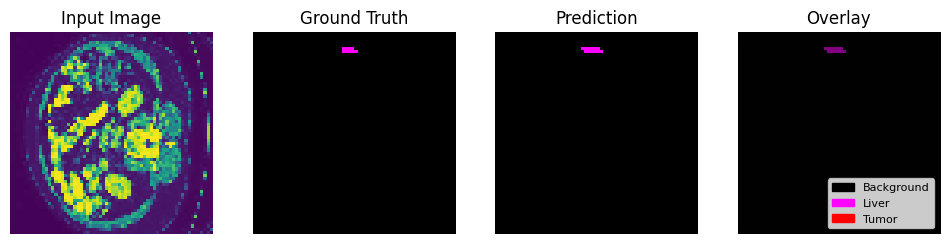

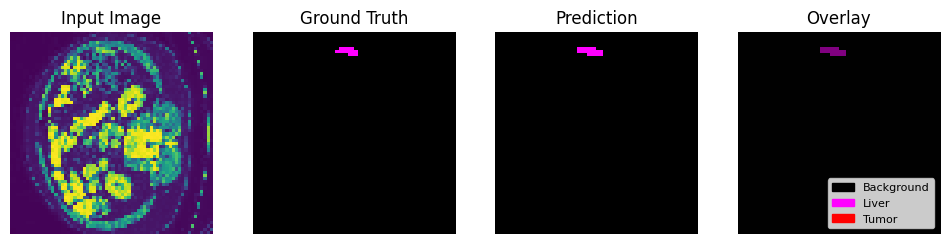

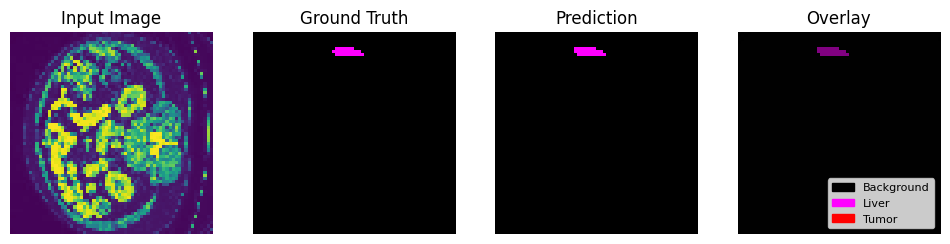

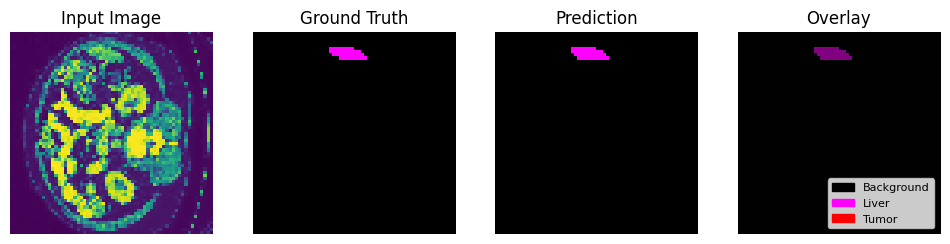

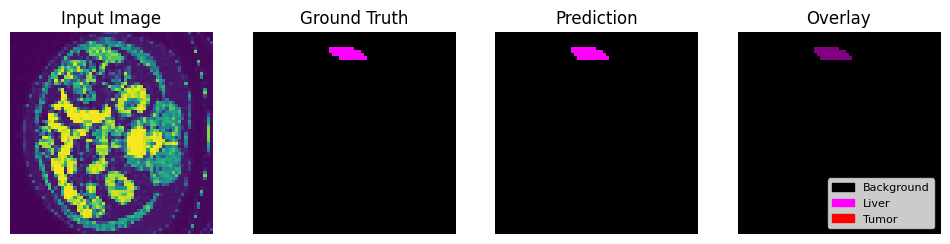

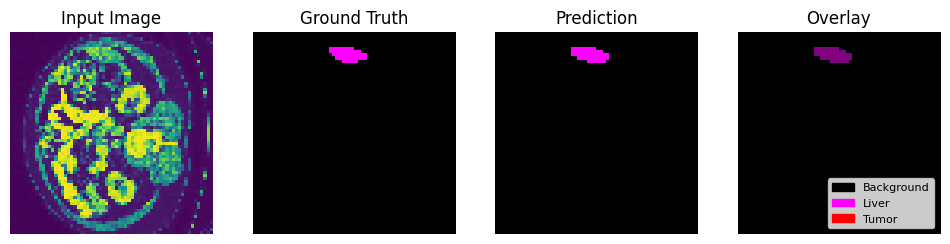

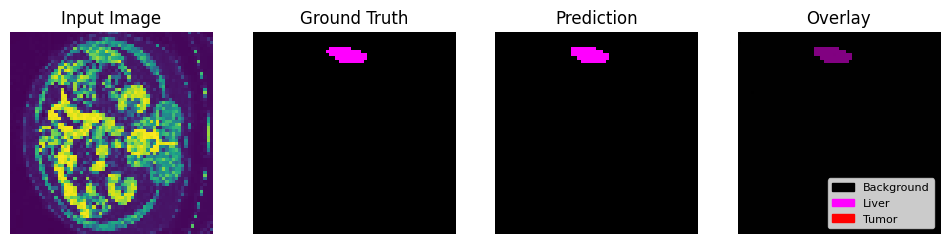

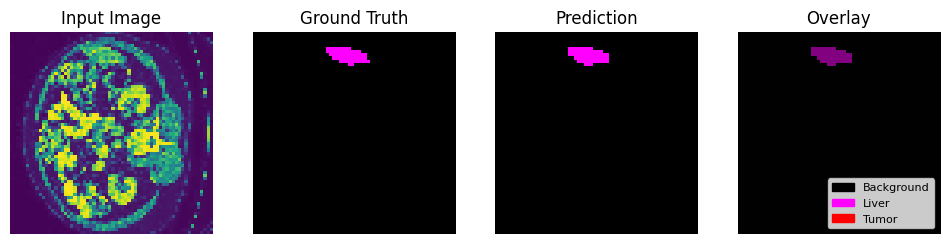

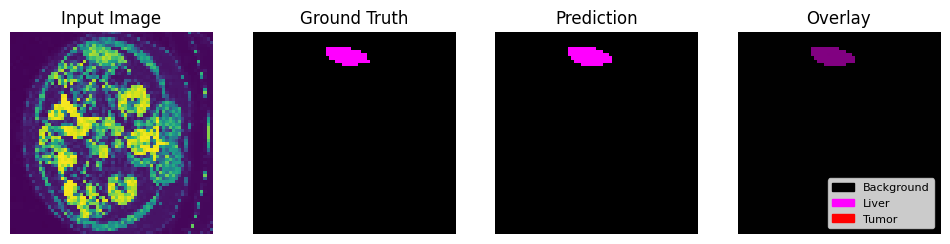

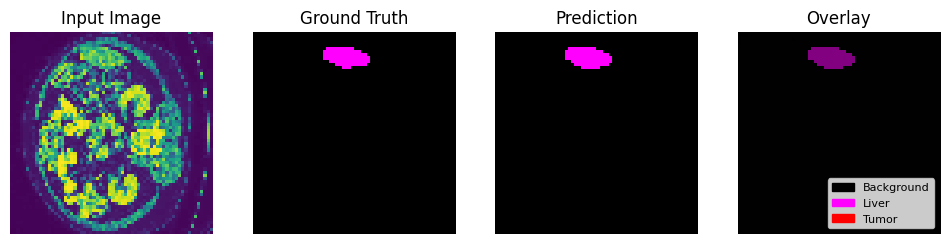

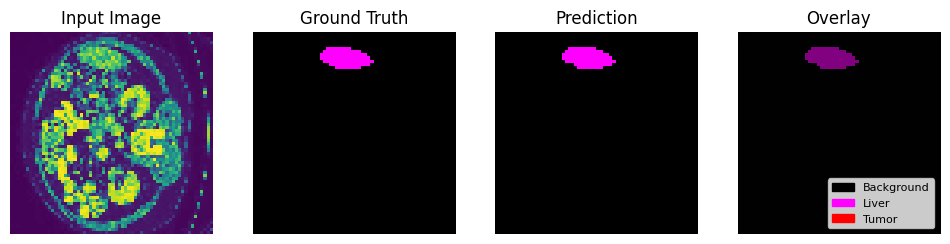

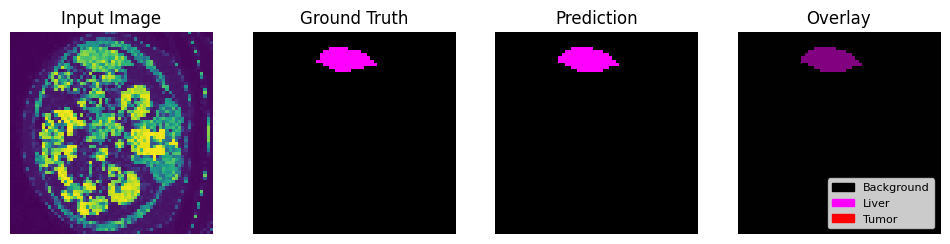

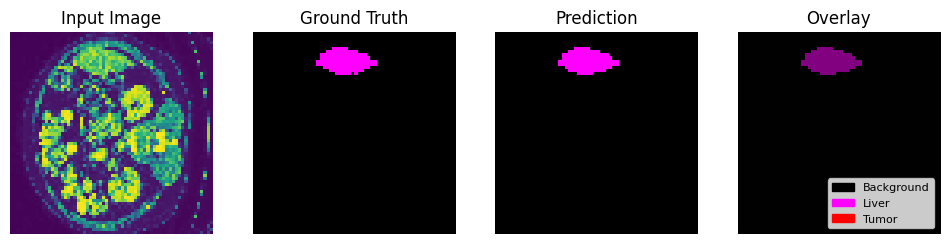

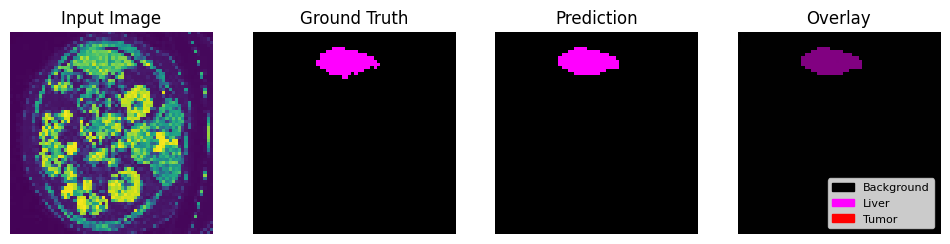

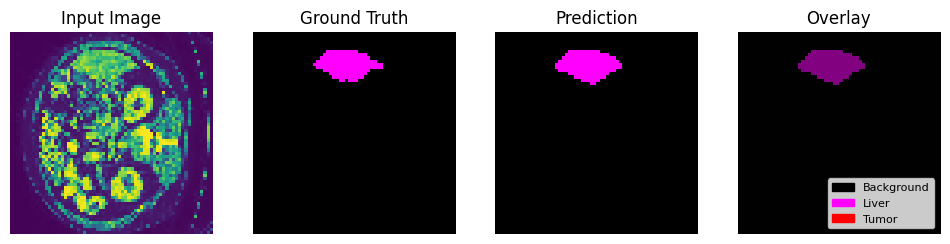

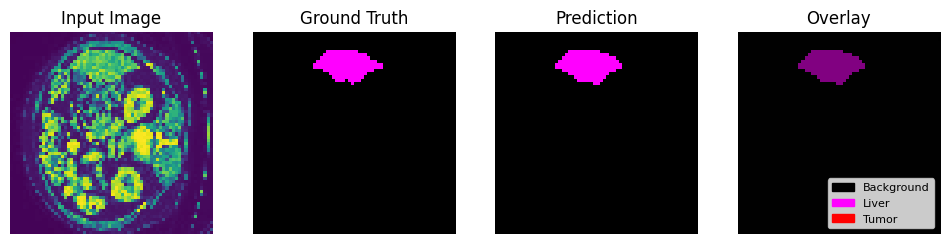

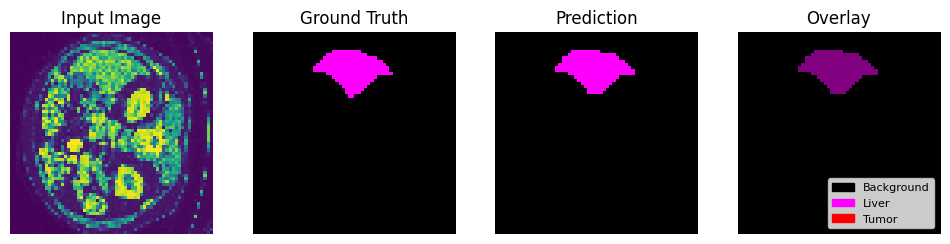

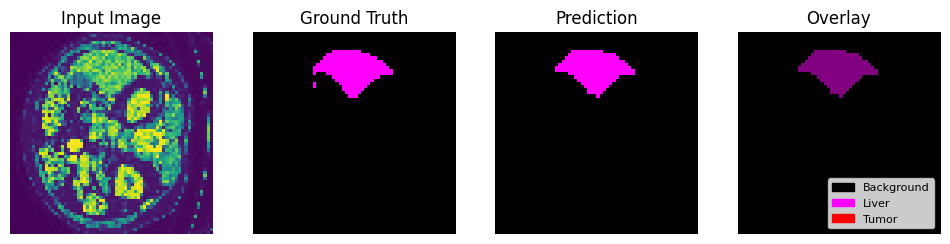

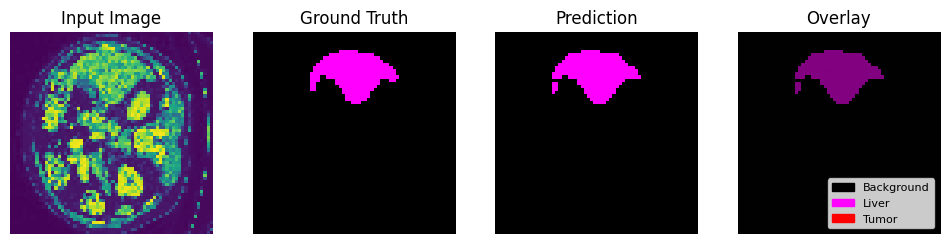

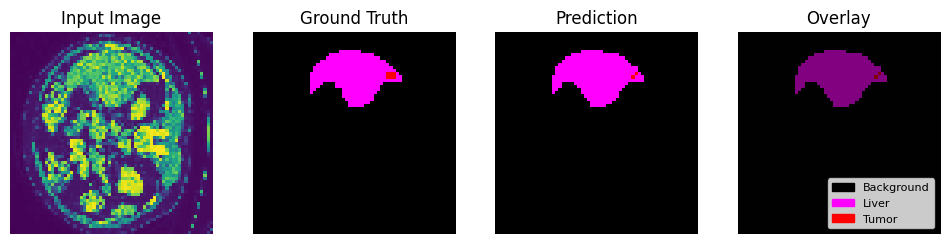

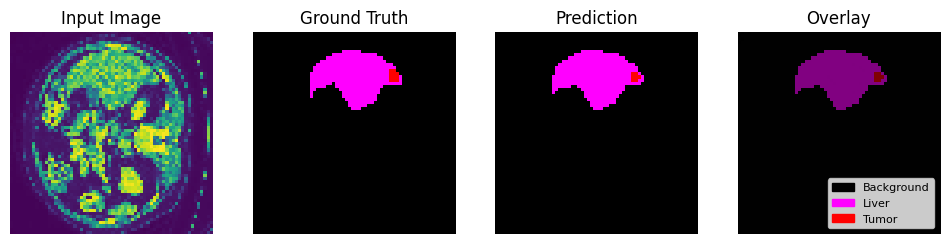

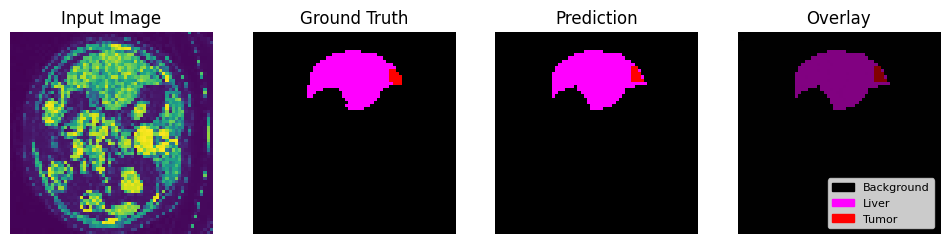

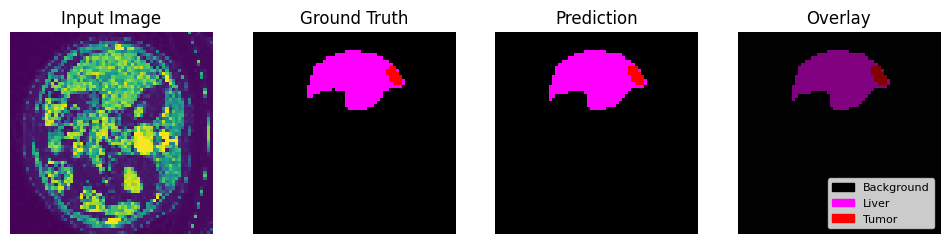

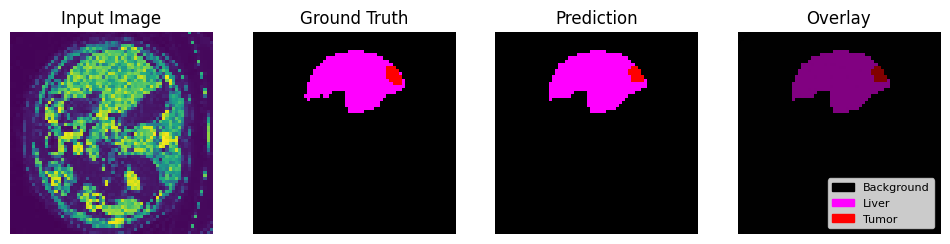

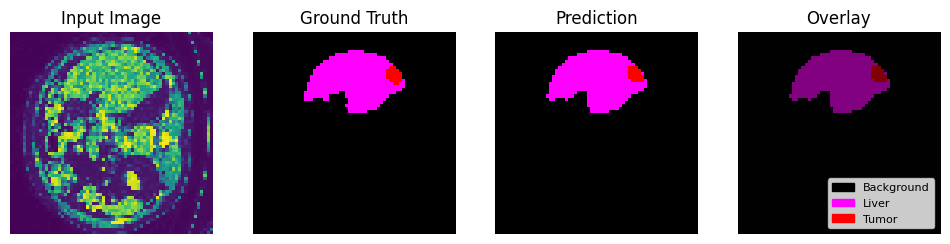

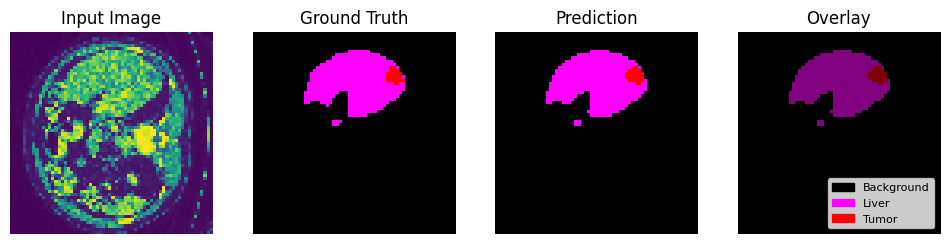

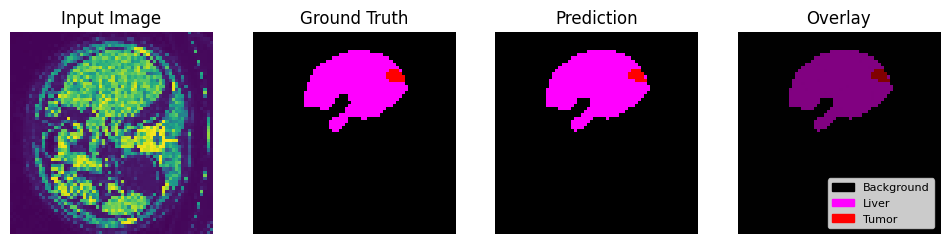

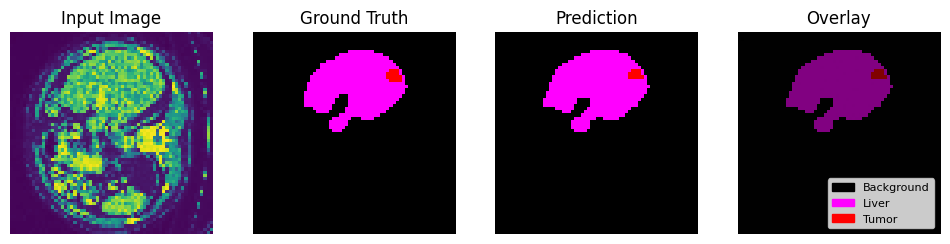

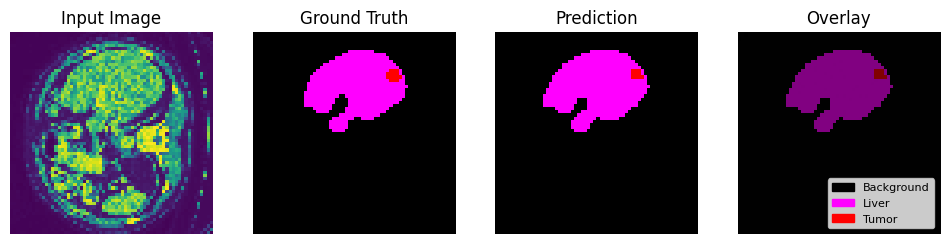

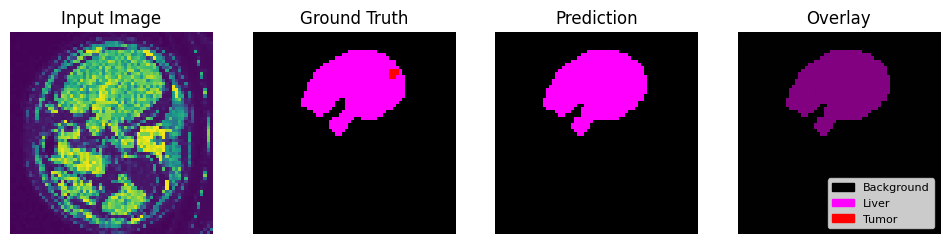

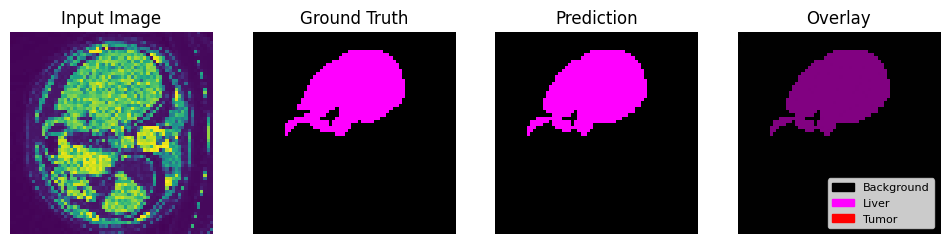

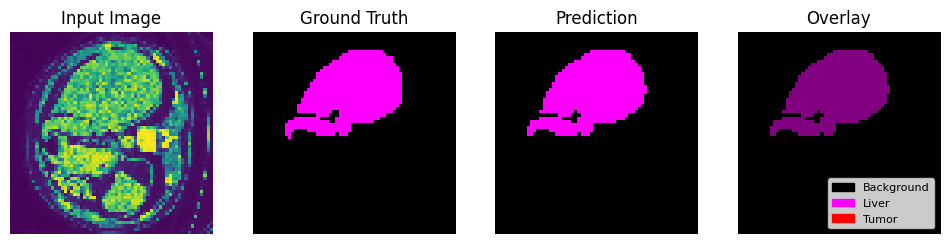

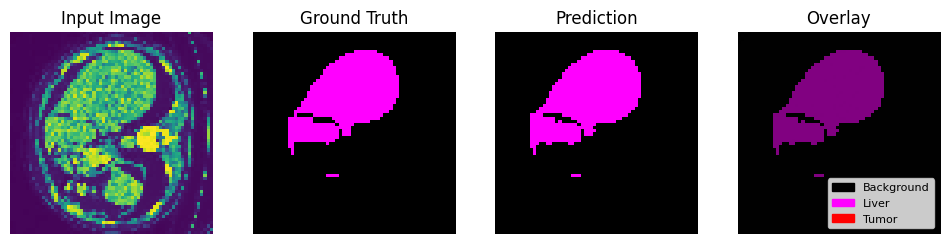

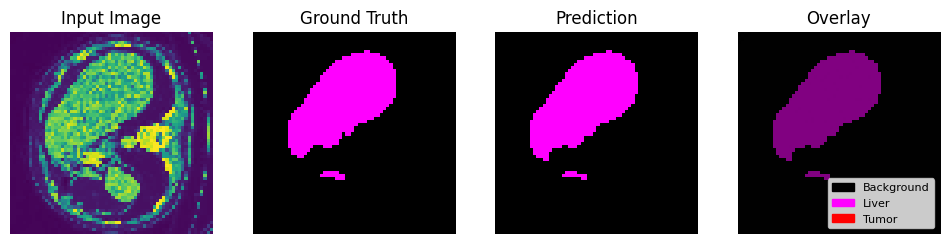

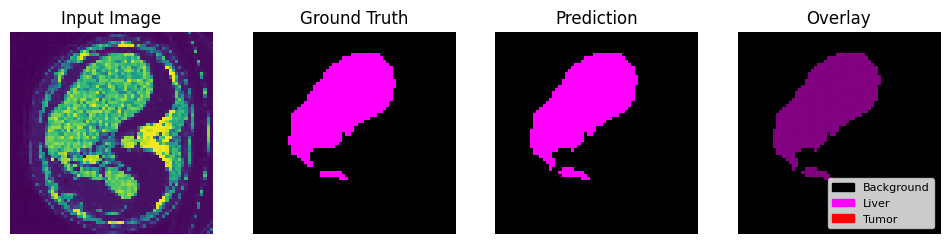

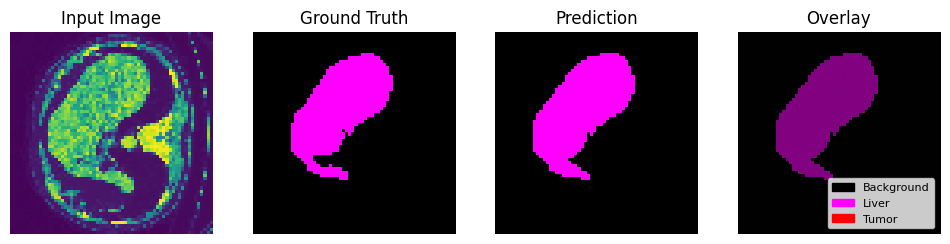

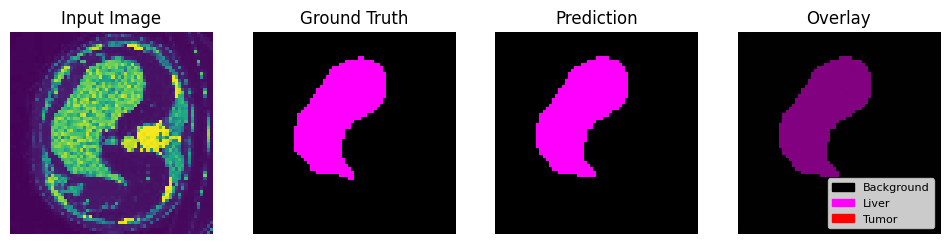

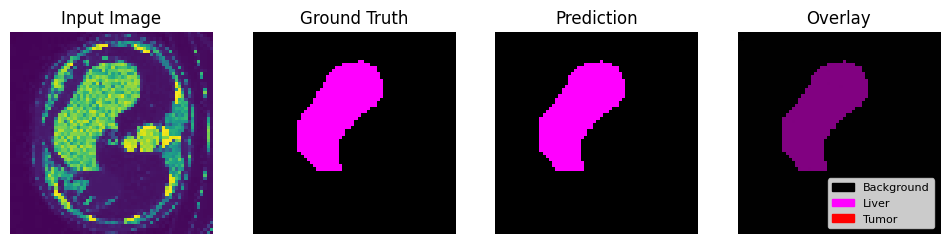

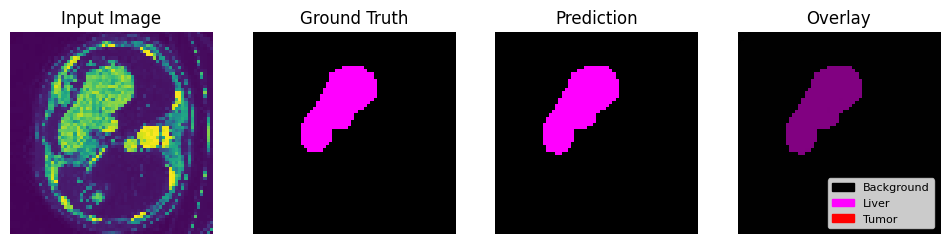

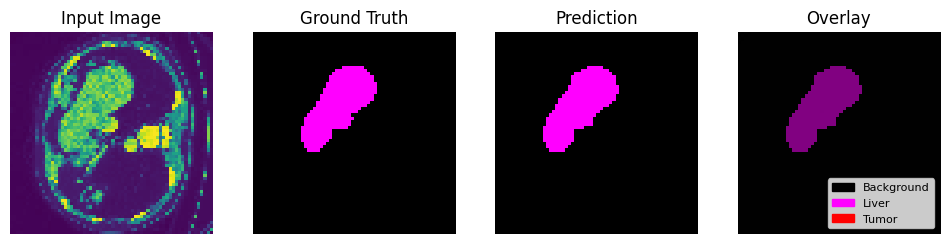

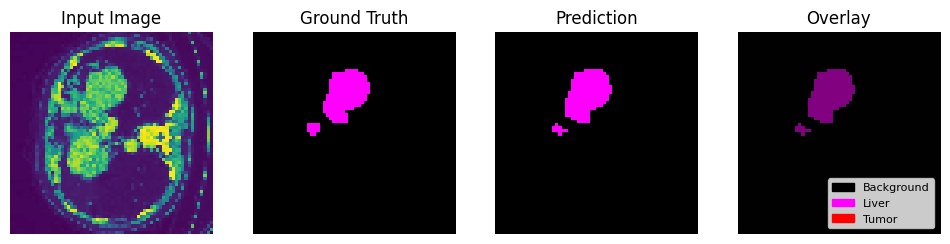

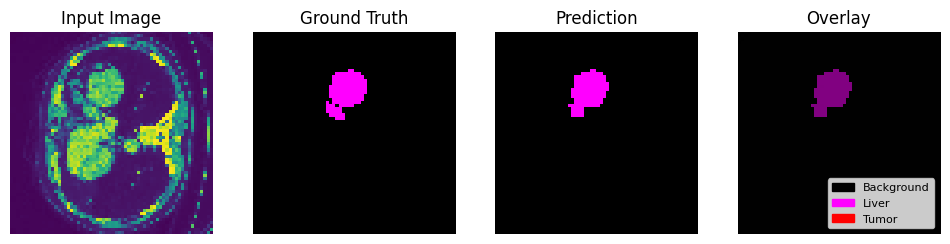

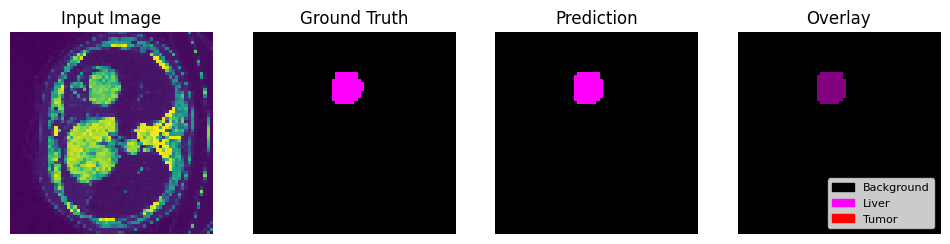

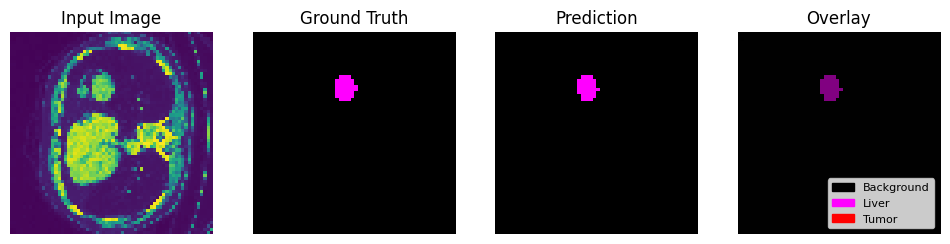

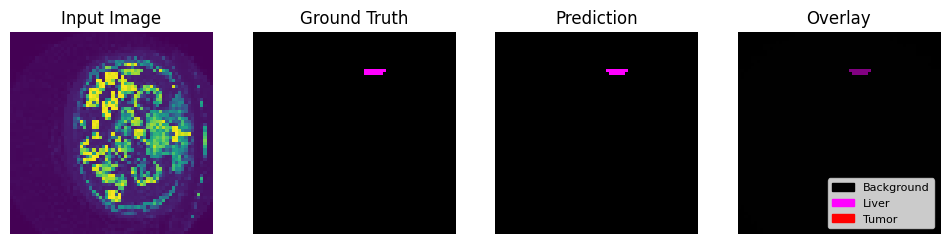

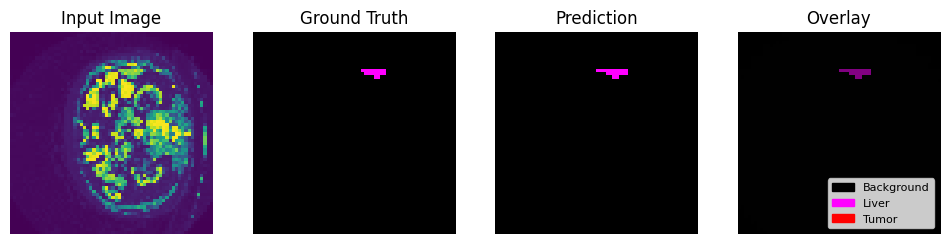

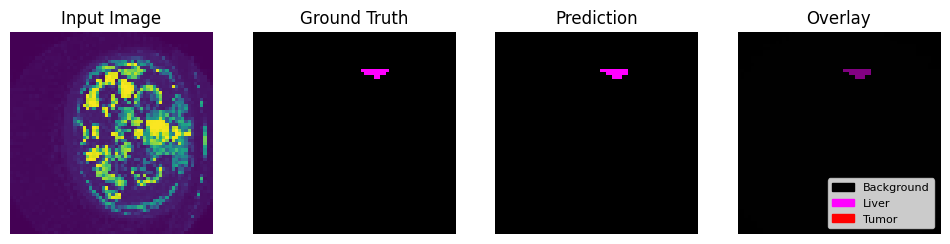

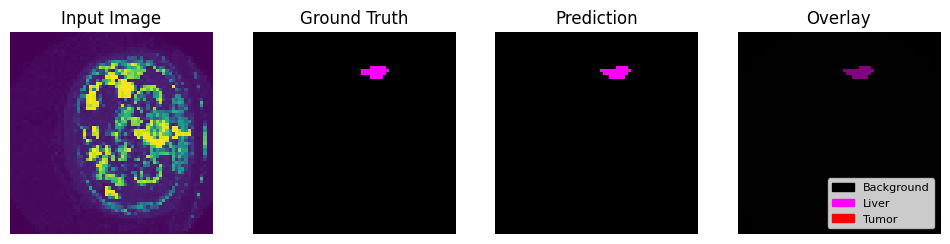

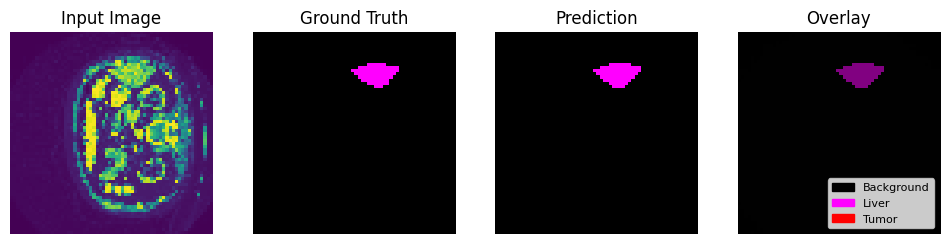

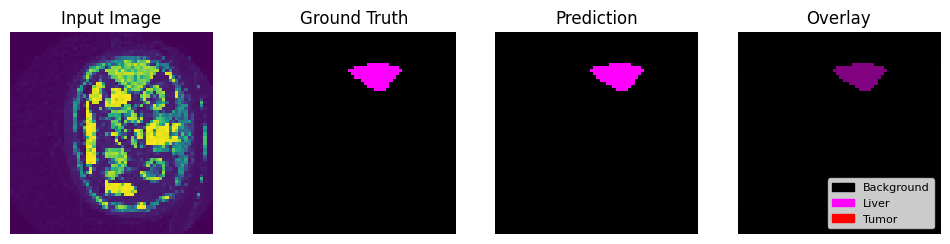

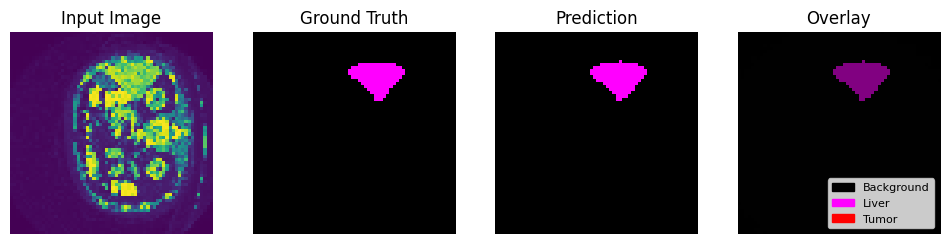

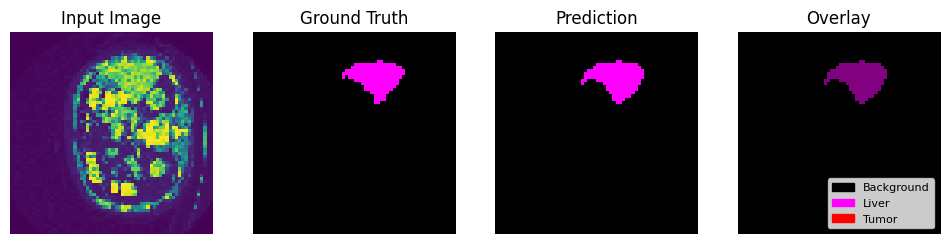

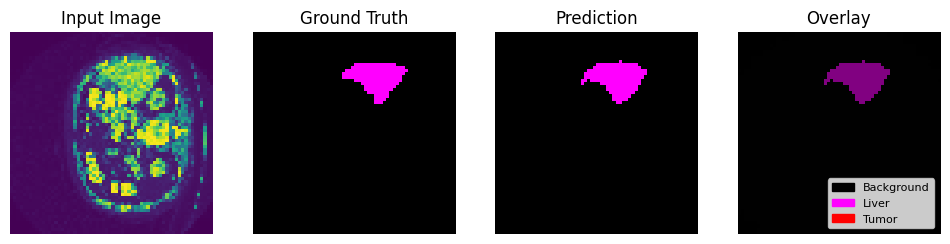

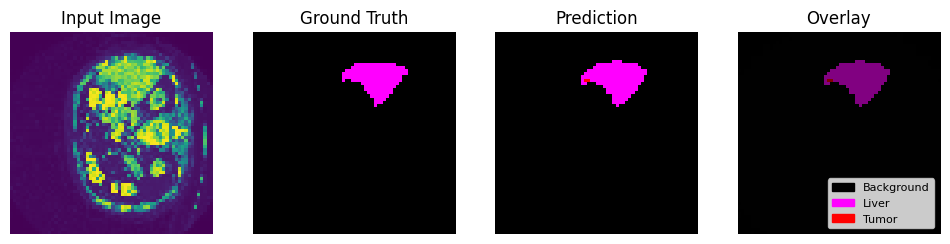

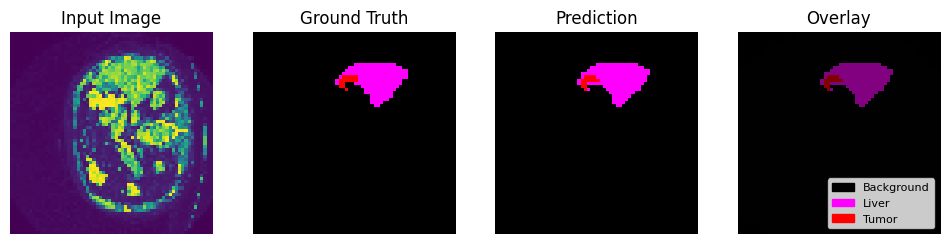

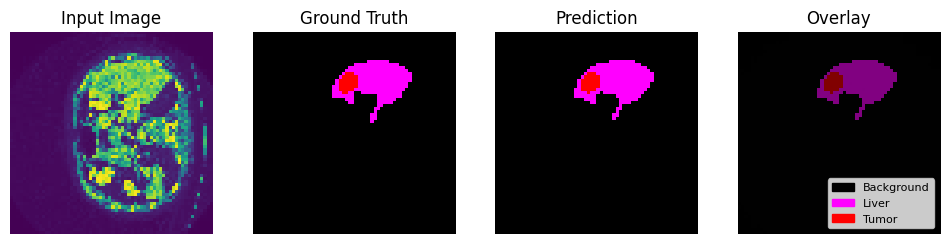

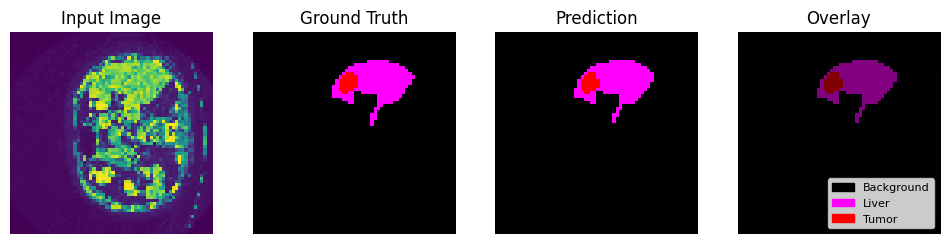

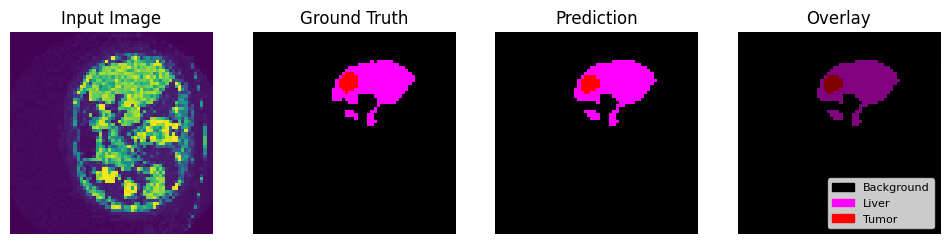

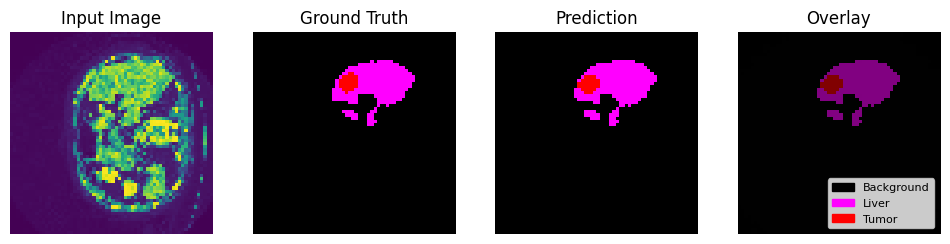

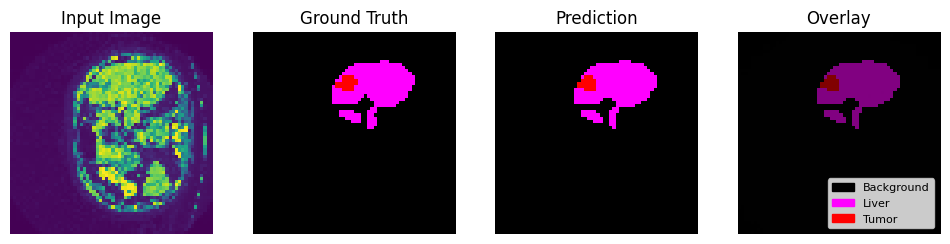

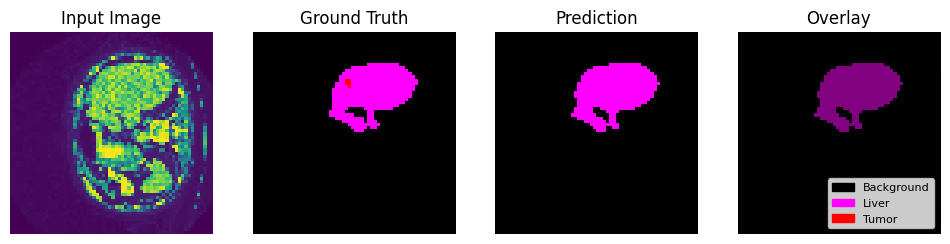

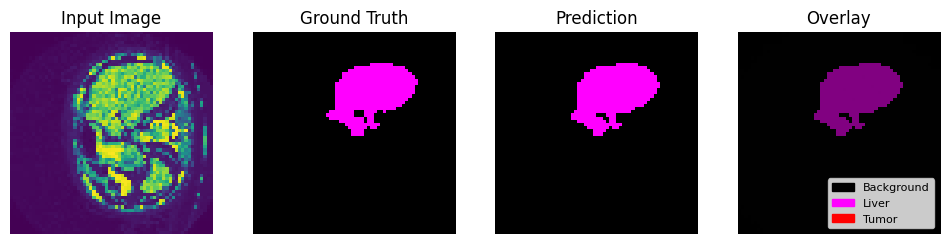

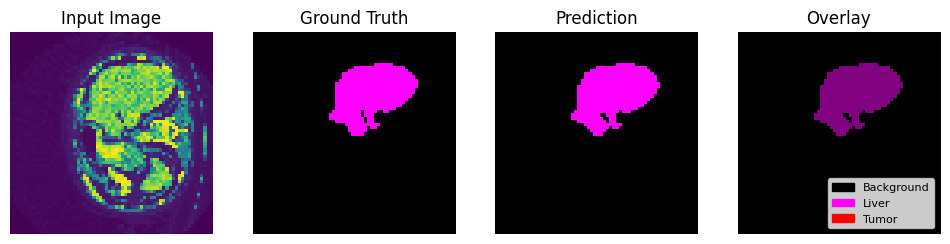

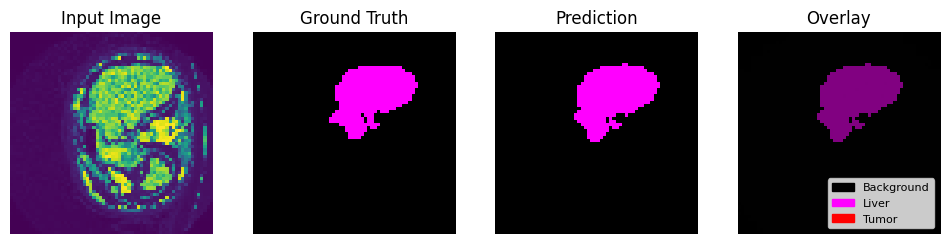

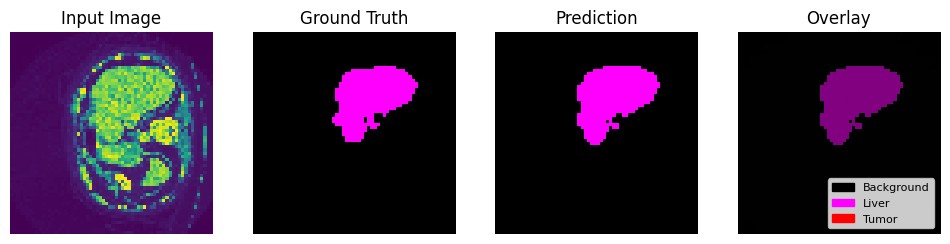

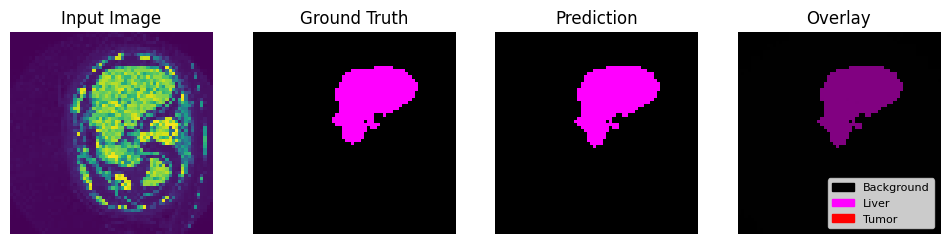

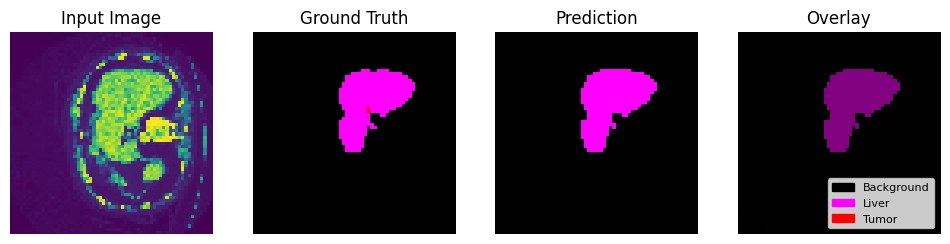

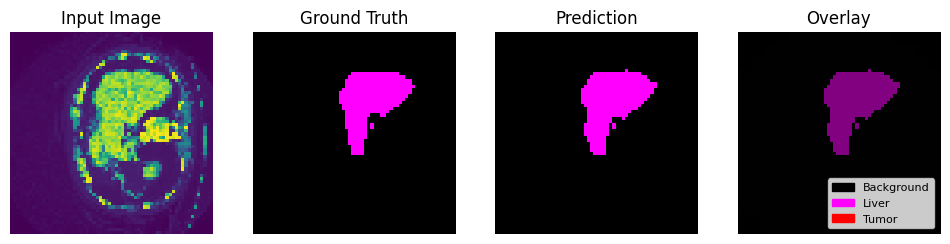

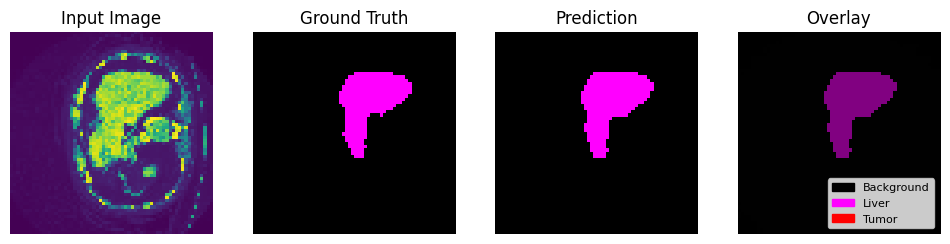

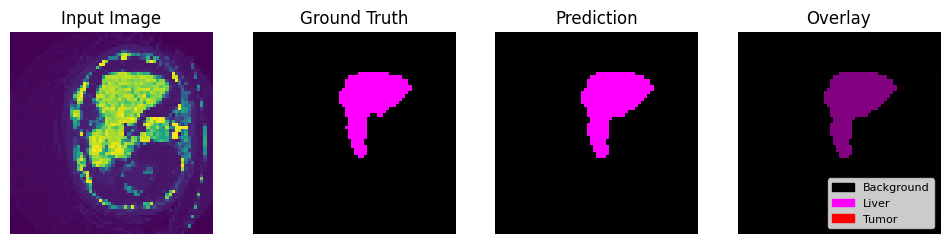

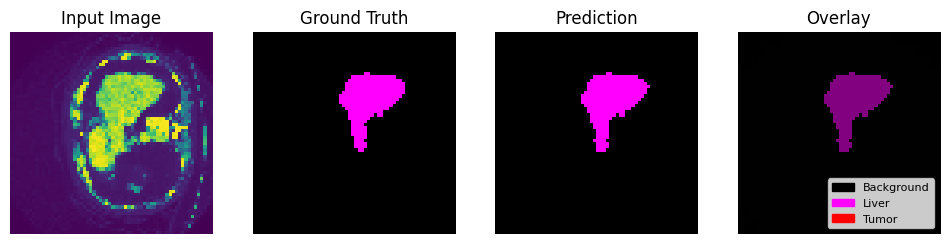

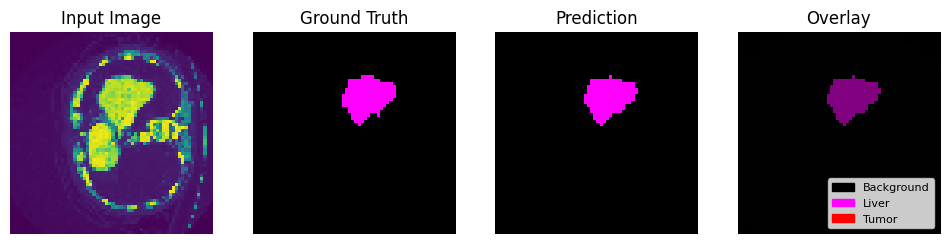

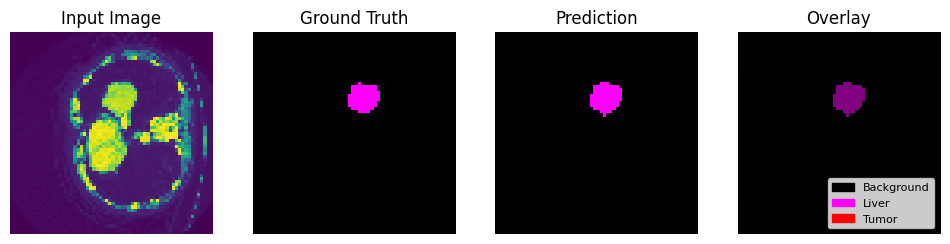

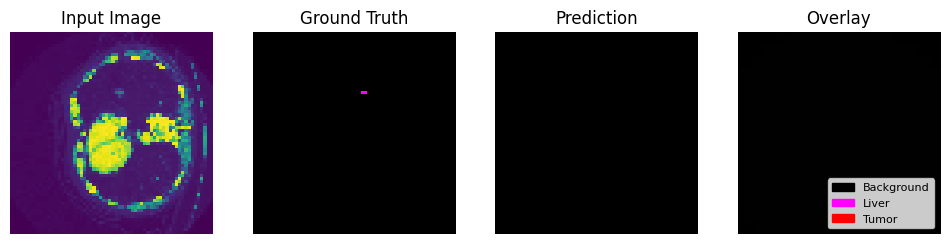

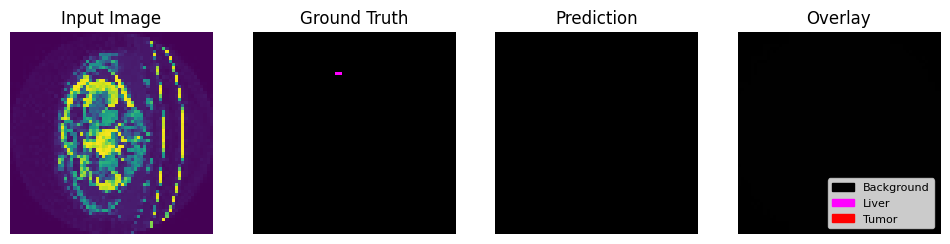

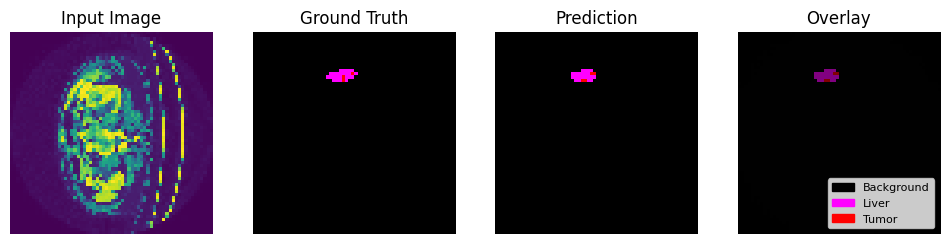

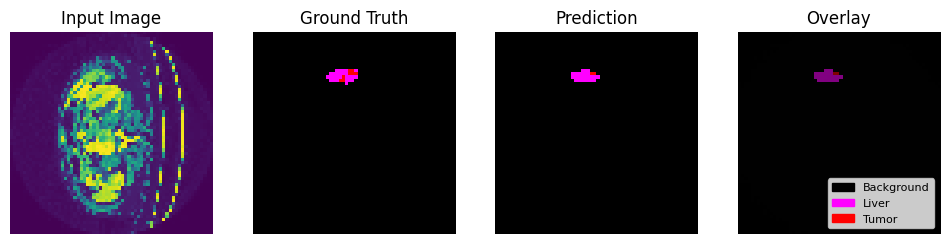

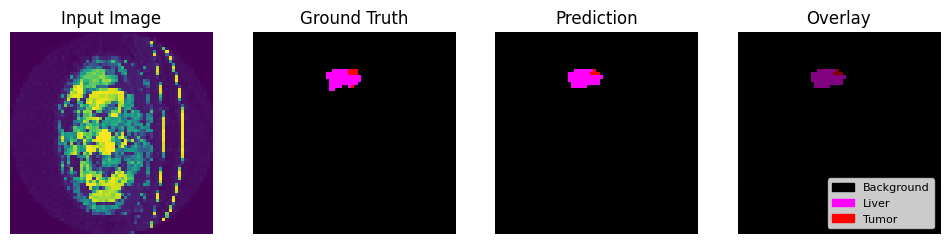

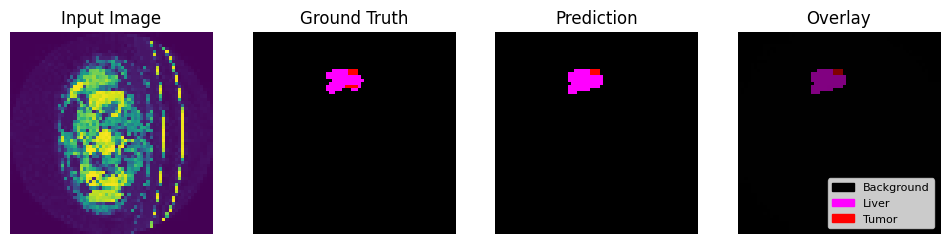

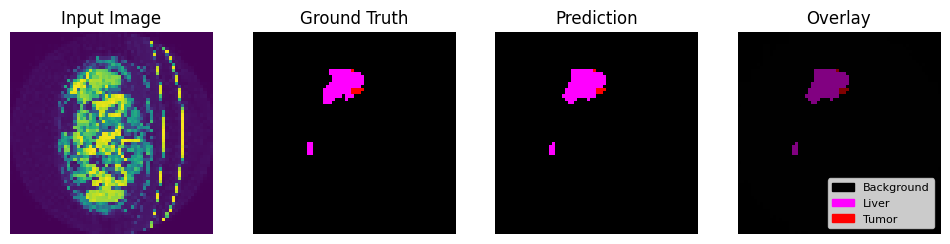

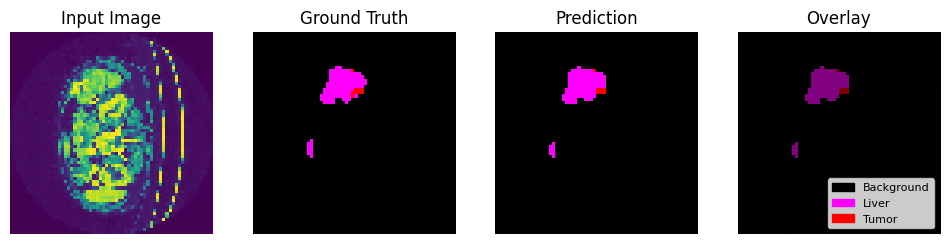

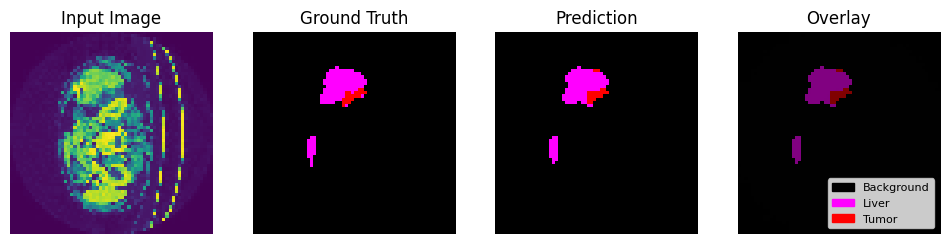

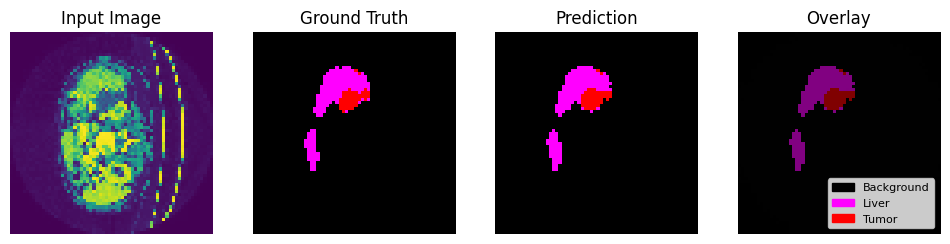

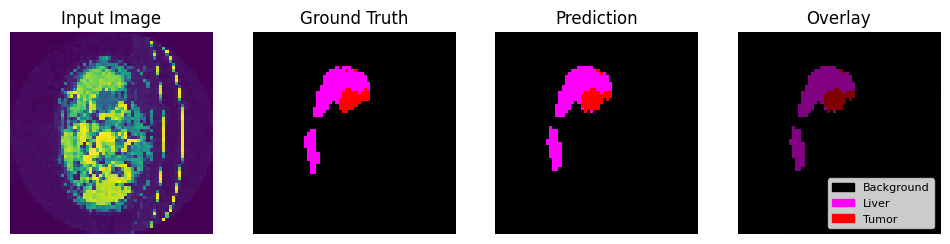

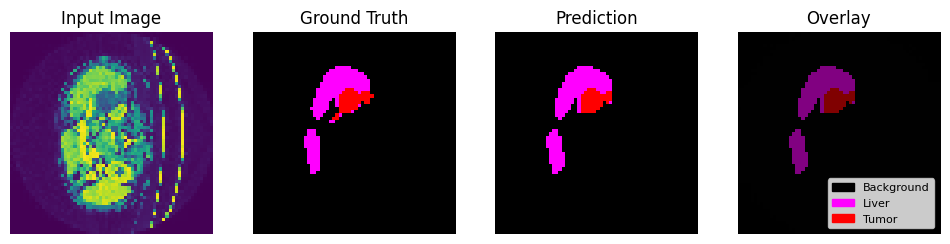

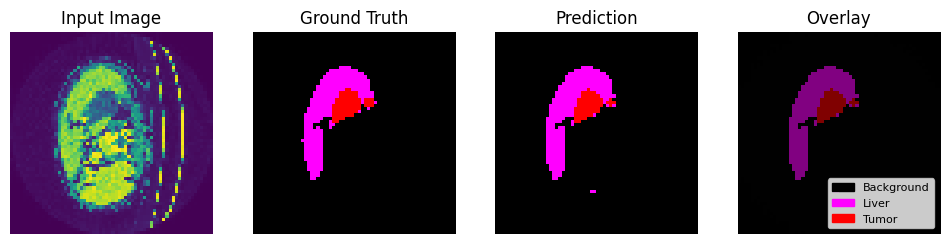

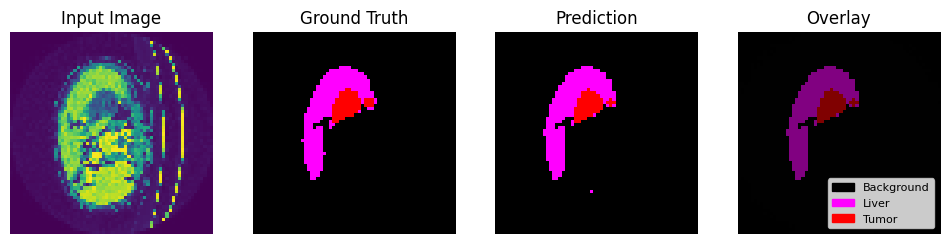

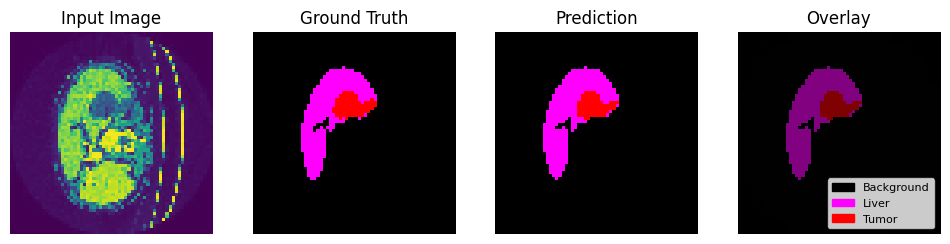

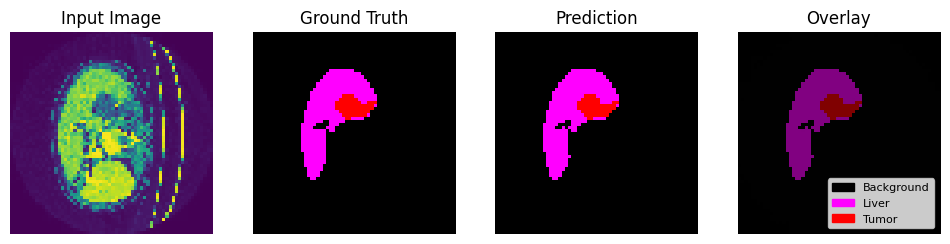

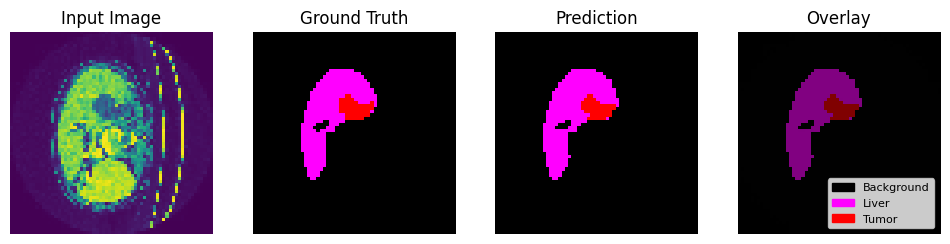

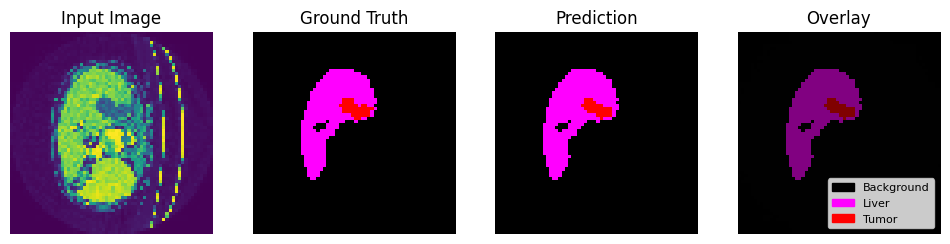

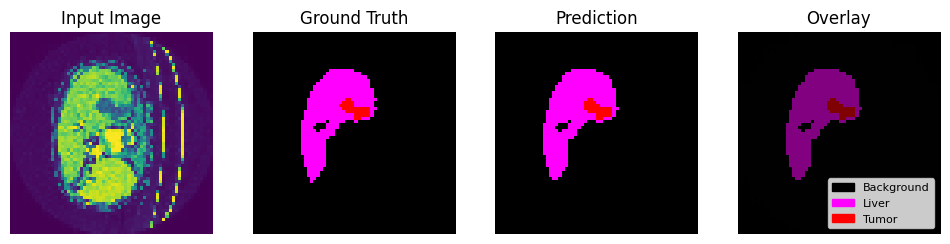

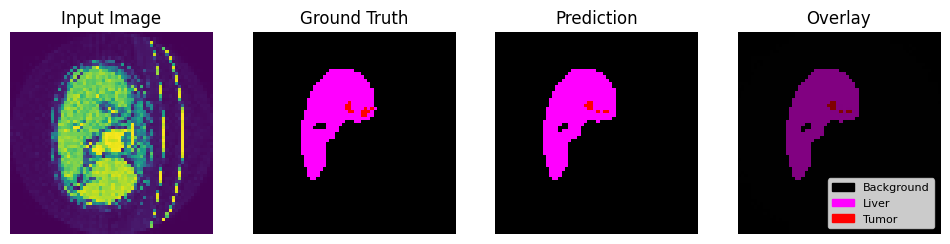

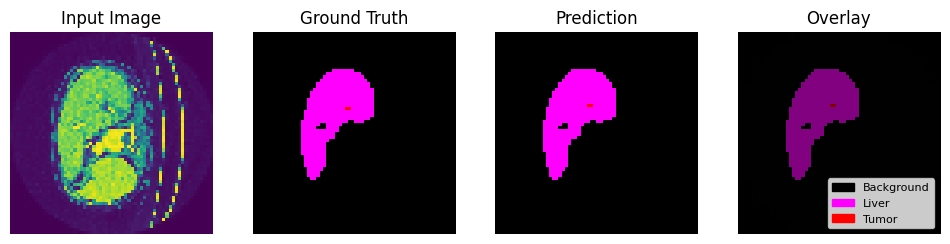

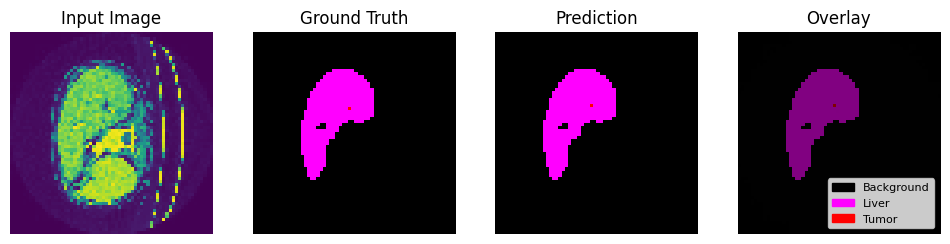

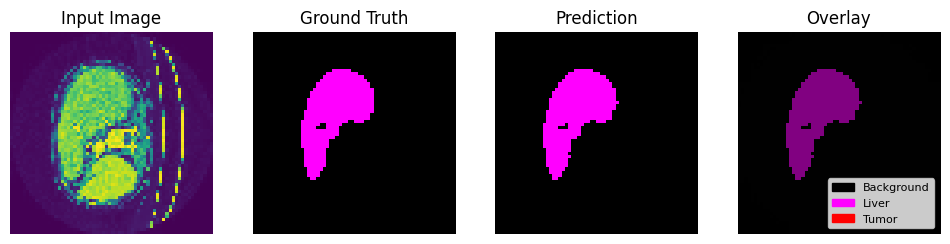

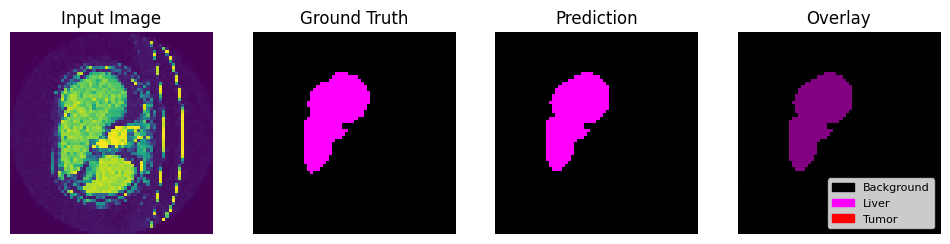

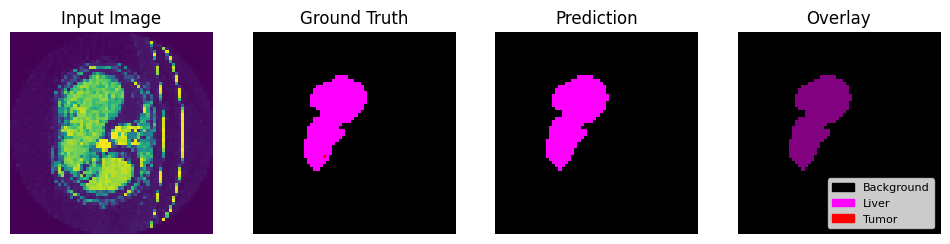

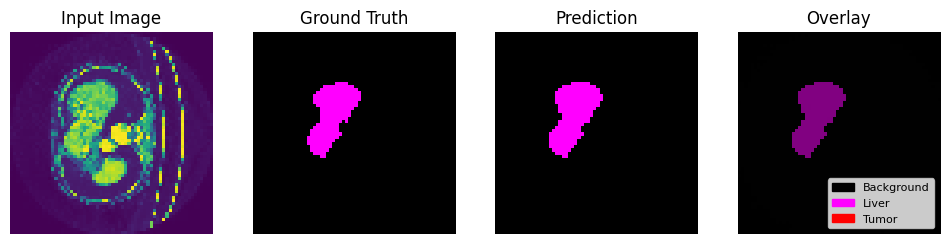

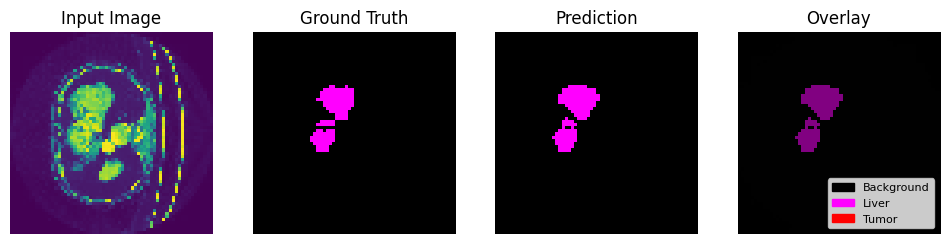

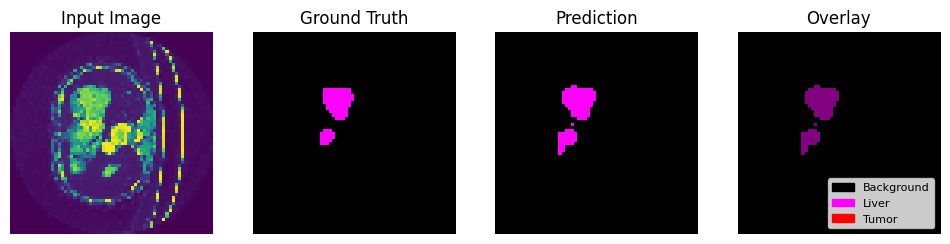

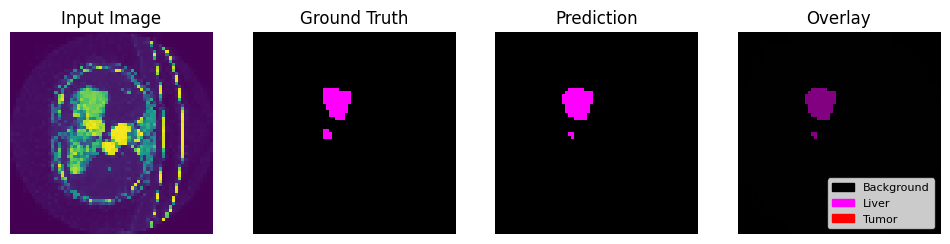

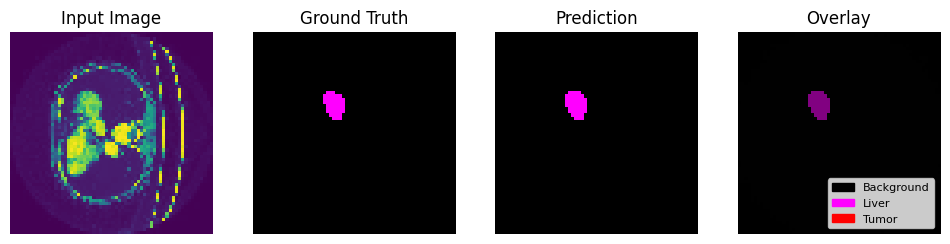

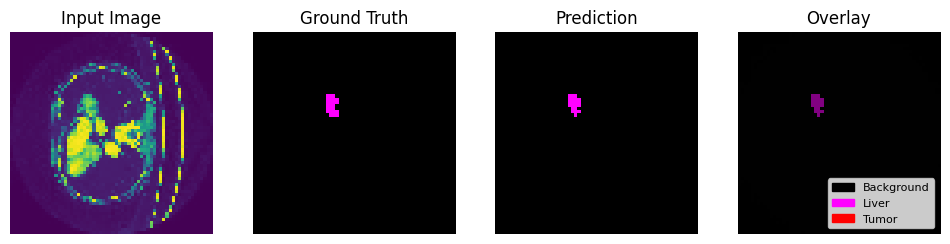

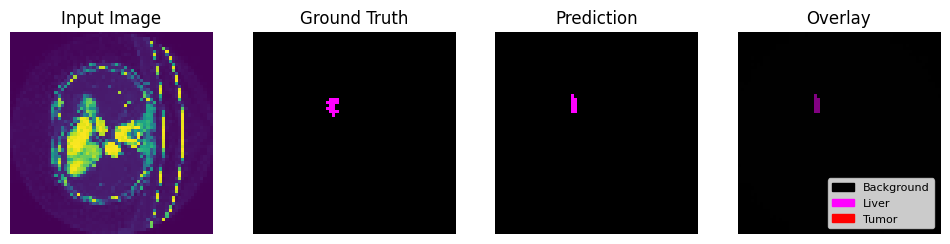

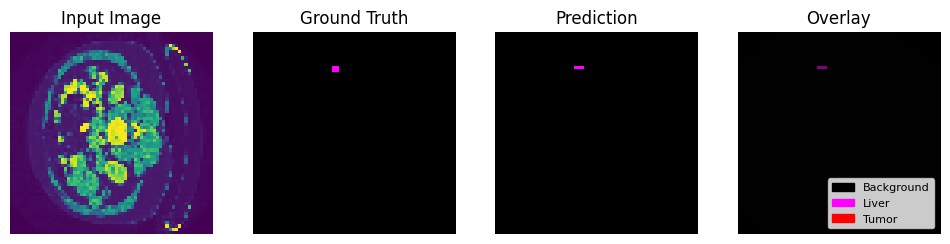

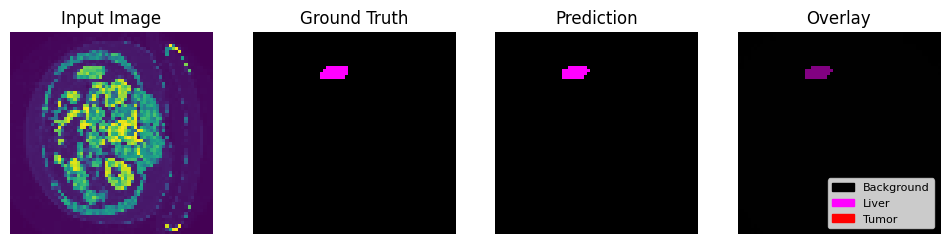

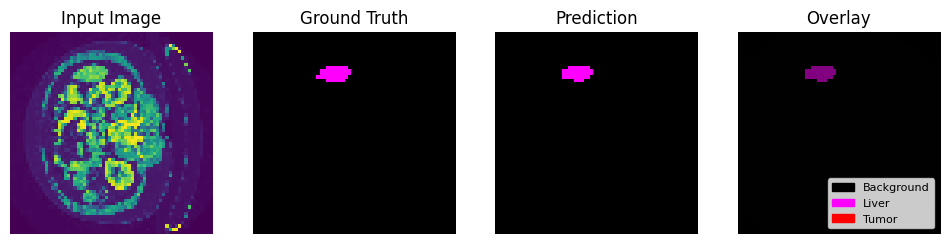

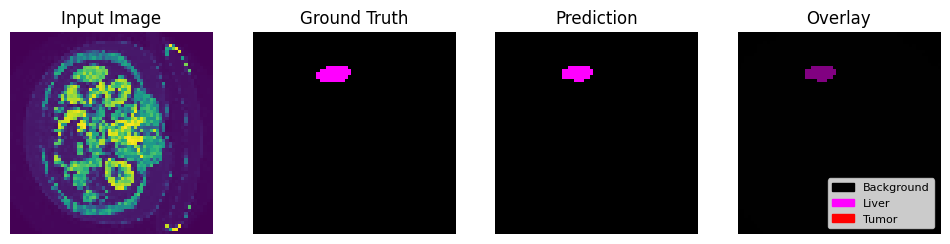

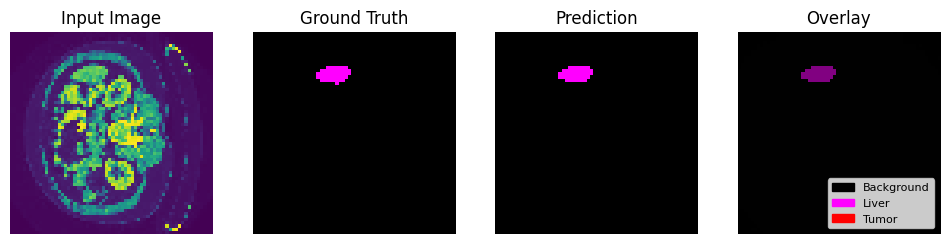

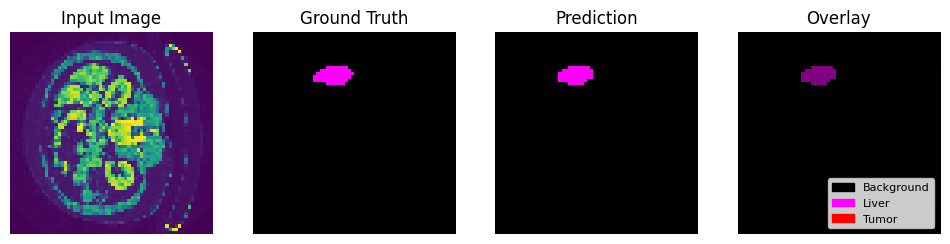

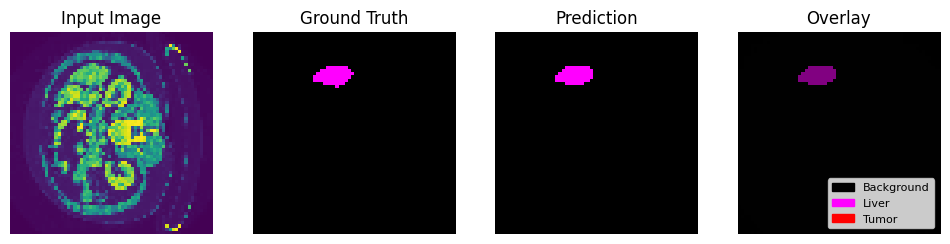

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

LABEL_COLORS = {
    0: (0, 0, 0),       # Background = Black
    1: (255, 0, 255),   # Liver = Magenta
    2: (255, 0, 0),     # Tumor = Red
}

legend_handles = [
    mpatches.Patch(color=np.array(color)/255.0, label=name)
    for (label_id, color), name in zip(LABEL_COLORS.items(), ["Background", "Liver", "Tumor"])
]


def colorize_mask(mask):
    mask = np.array(mask).astype(np.uint8)
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        color_mask[mask == label] = color
    return color_mask

def overlay_mask(image, mask, alpha=0.5):

    if image.ndim == 2:  
        image_rgb = np.stack([image]*3, axis=-1)
        image_rgb = (image_rgb*255).astype(np.uint8)
    else:
        image_rgb = (image*255).astype(np.uint8)
    
    mask_rgb = np.zeros_like(image_rgb, dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        mask_rgb[mask == label] = color

    overlay = (alpha * mask_rgb + (1-alpha) * image_rgb).astype(np.uint8)
    return overlay

def visualize_predictions_multi(model, dataloader, device, n_images=4, alpha=0.5):
    model.eval()
    images_shown = 0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)  
            
            images = images.cpu().numpy()
            masks = masks.cpu().numpy()
            preds = preds.cpu().numpy()
            
            for i in range(images.shape[0]):
                if np.sum(masks[i] > 0) == 0:
                    continue
                
                img = np.transpose(images[i], (1,2,0)) if images[i].shape[0]>1 else images[i,0] 
                
                gt_color = colorize_mask(masks[i])
                pred_color = colorize_mask(preds[i])
                
                overlay = overlay_mask(img, preds[i], alpha=alpha)
             
                fig, axes = plt.subplots(1,4, figsize=(12,5))
                
                axes[0].imshow(img if img.ndim==2 else img)
                axes[0].set_title("Input Image")
                axes[0].axis('off')
                
                axes[1].imshow(gt_color)
                axes[1].set_title("Ground Truth")
                axes[1].axis('off')
                
                axes[2].imshow(pred_color)
                axes[2].set_title("Prediction")
                axes[2].axis('off')
                
                axes[3].imshow(overlay)
                axes[3].set_title("Overlay")
                axes[3].axis('off')
                
                axes[3].legend(handles=legend_handles, loc='lower right', fontsize=8)
                
                plt.show()
                
                images_shown += 1
                if images_shown >= n_images:
                    return


visualize_predictions_multi(model, val_loader, device, n_images=200, alpha=0.5)

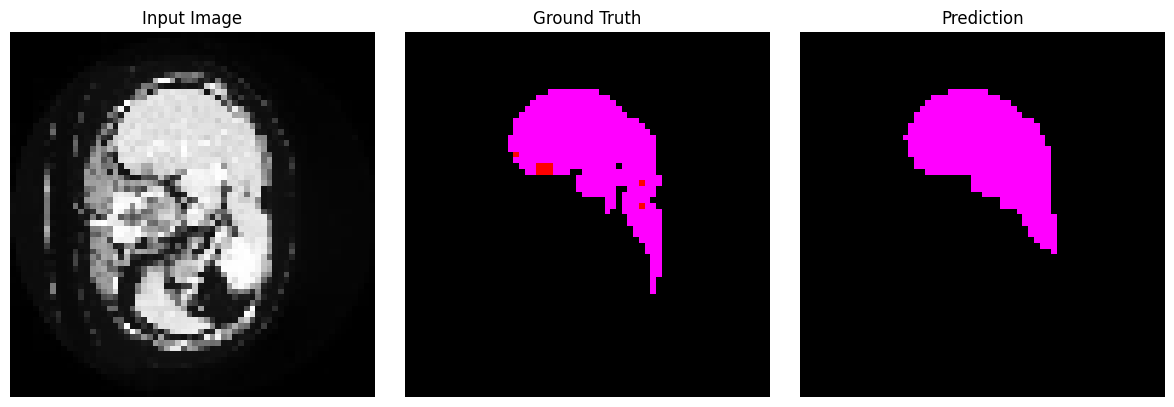

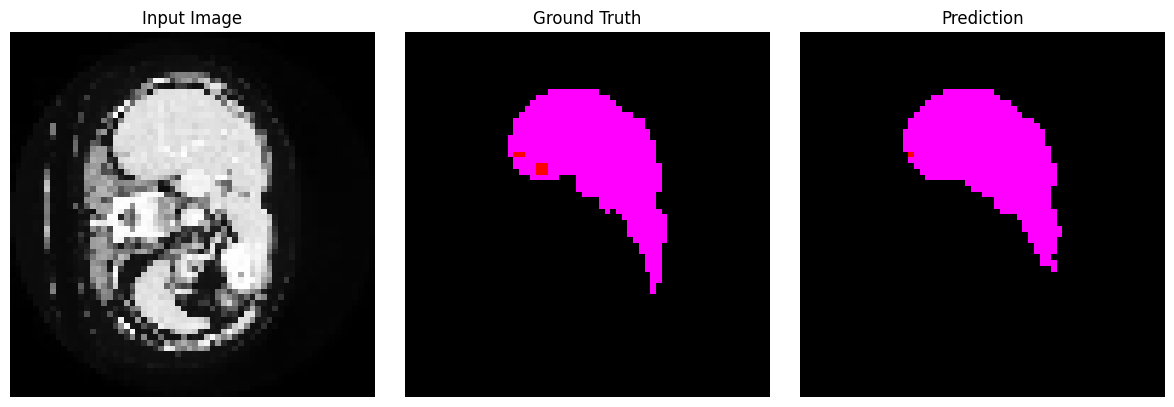

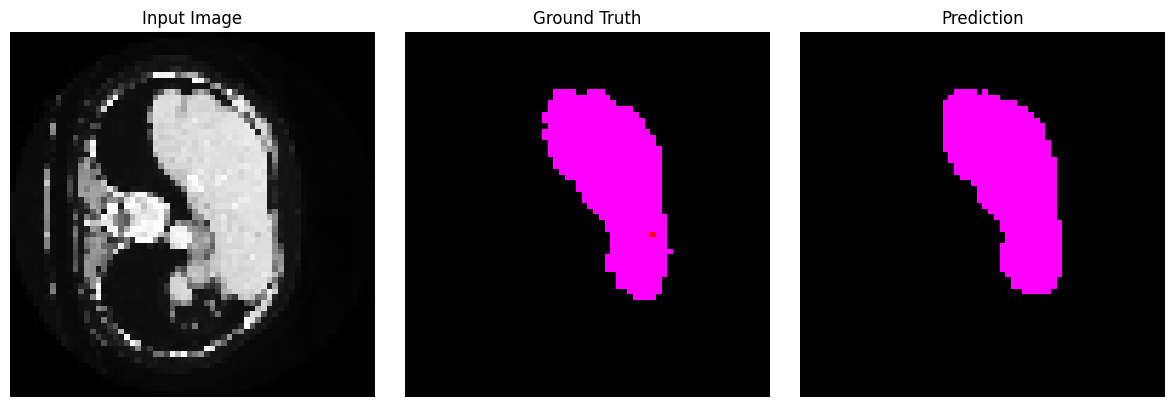

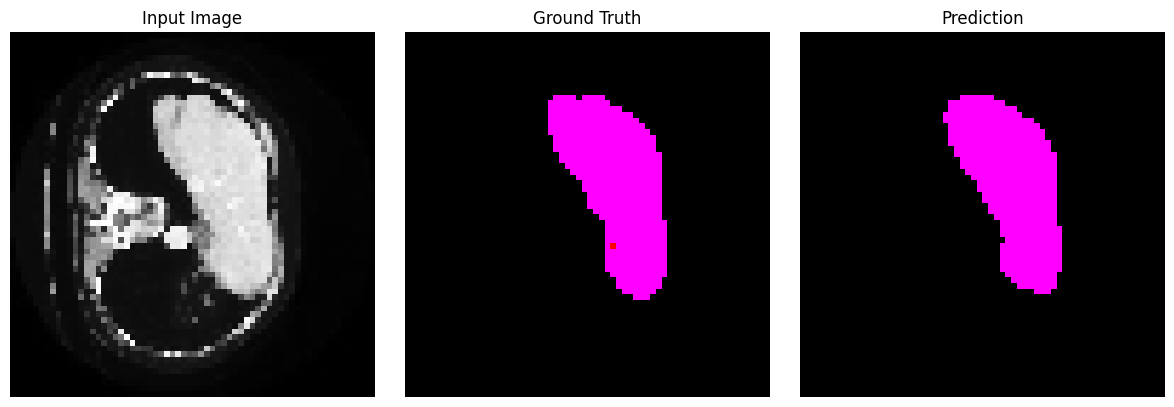

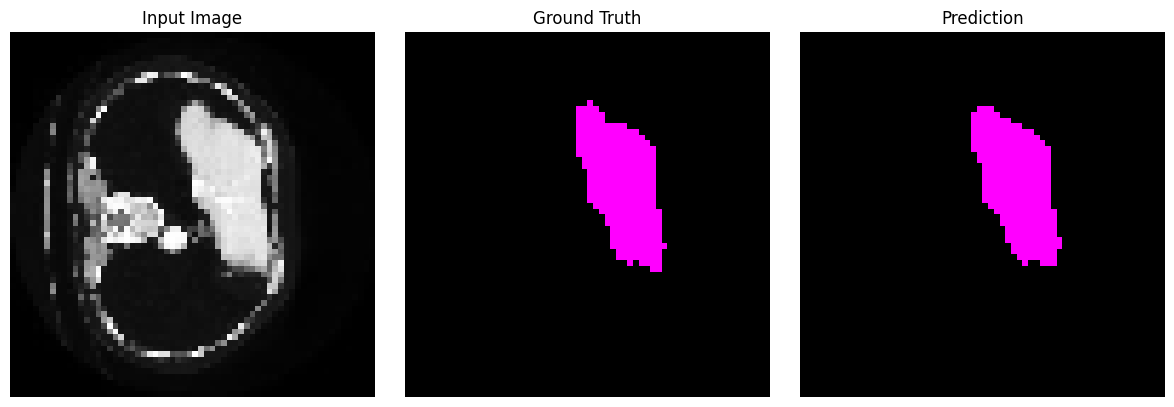

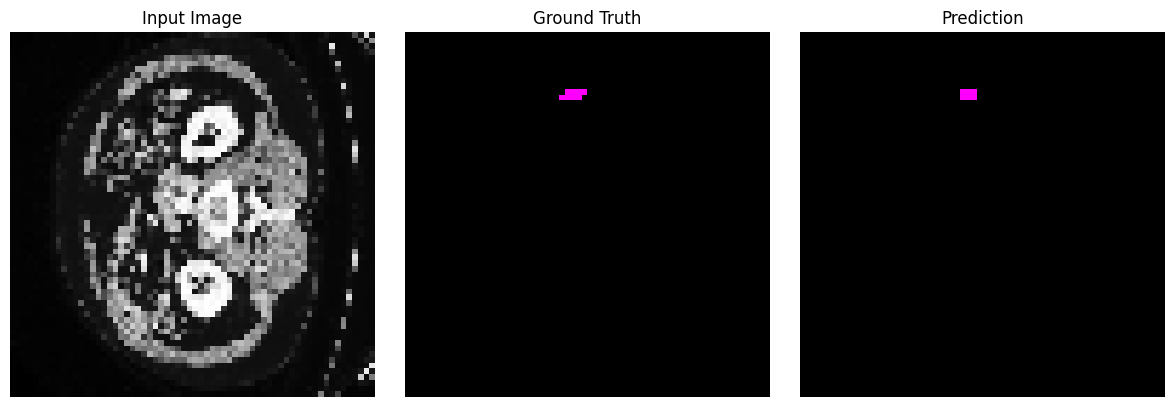

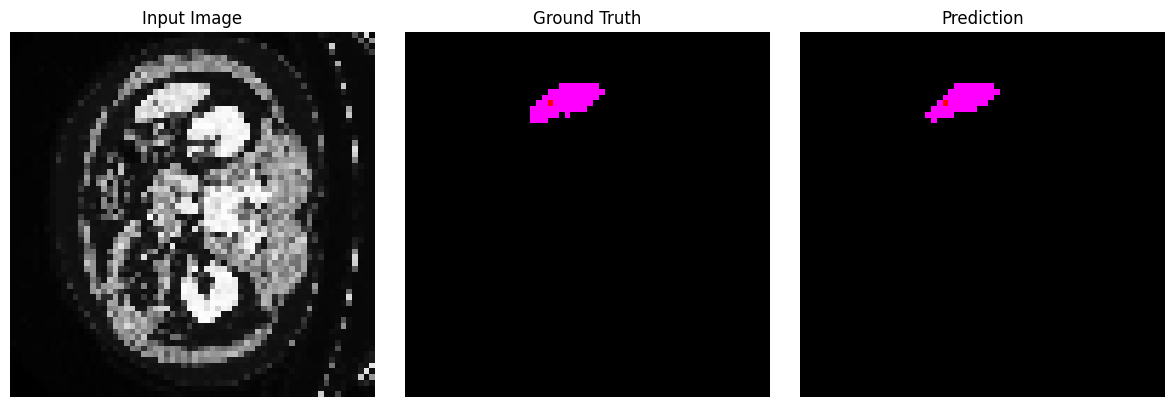

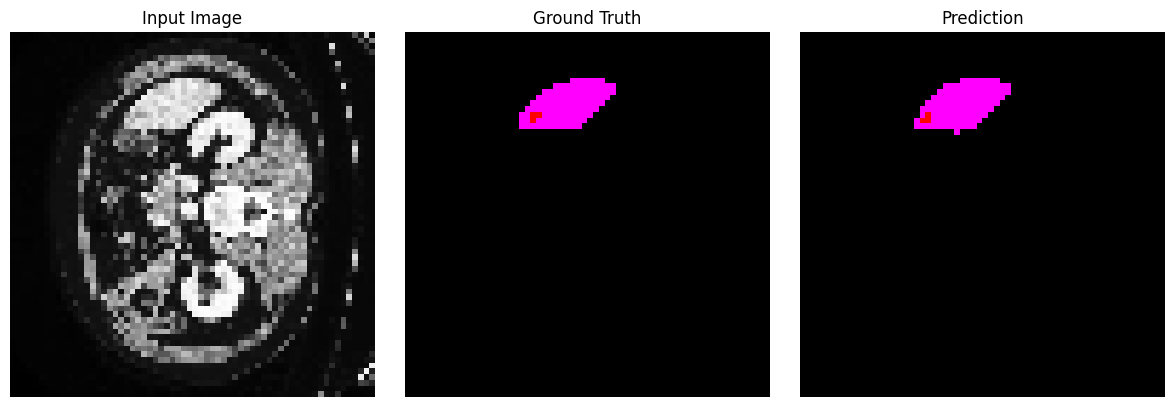

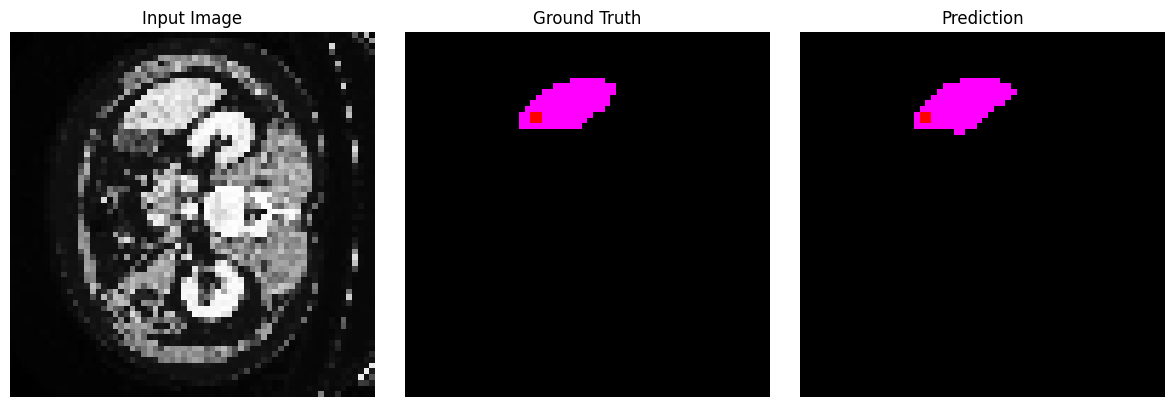

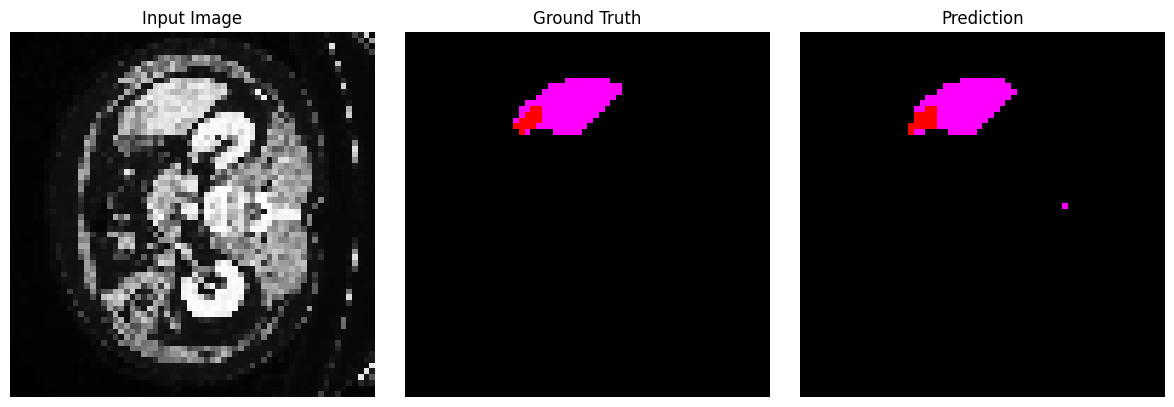

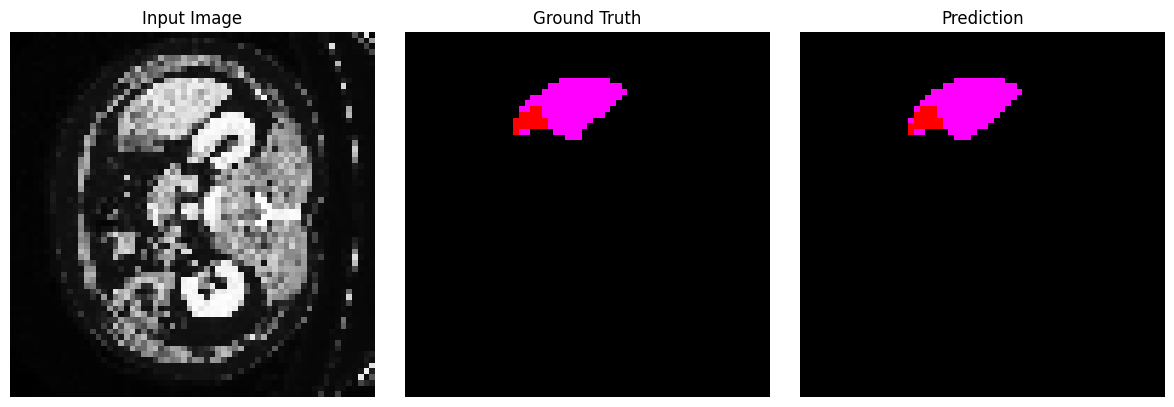

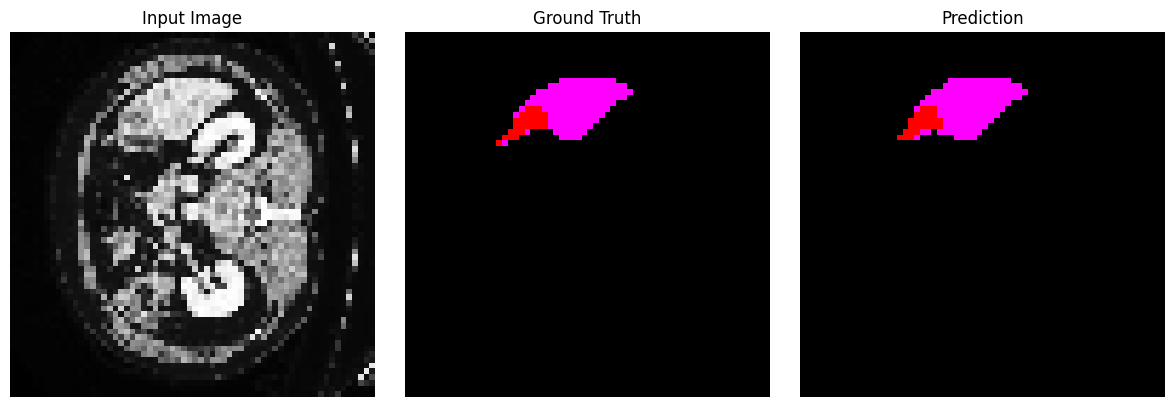

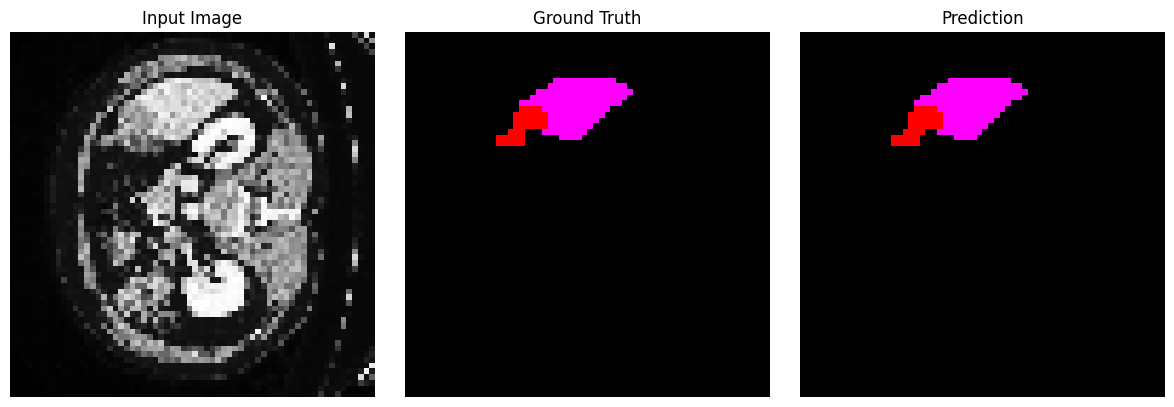

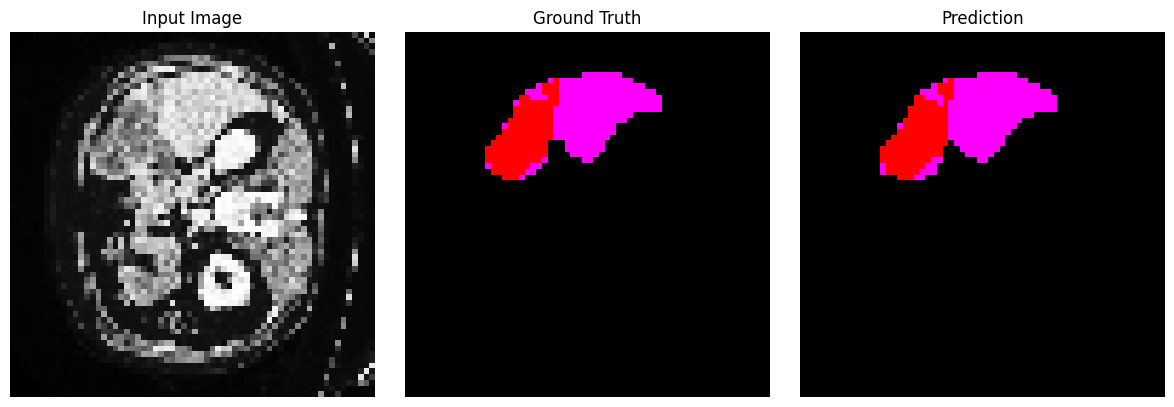

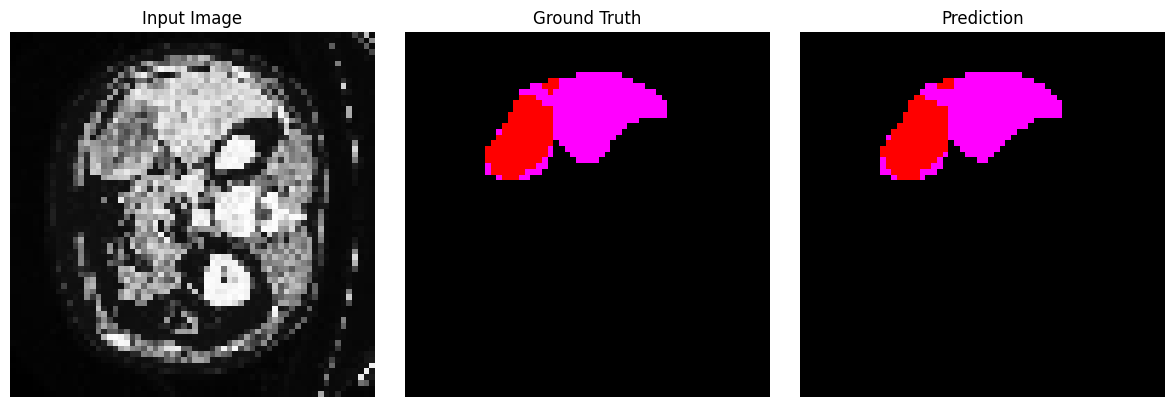

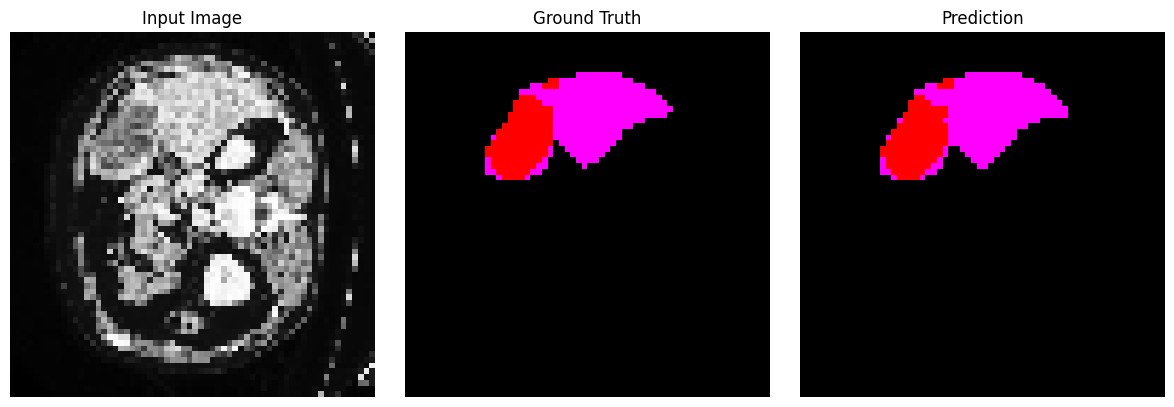

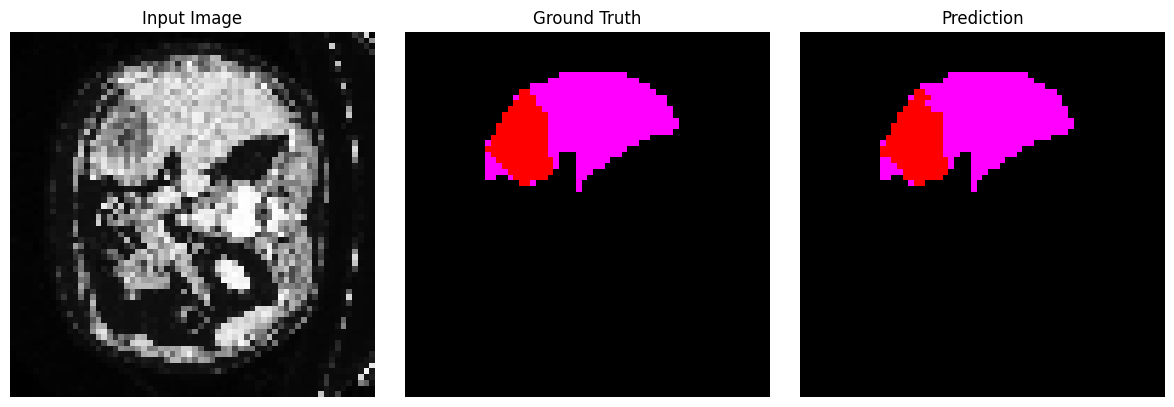

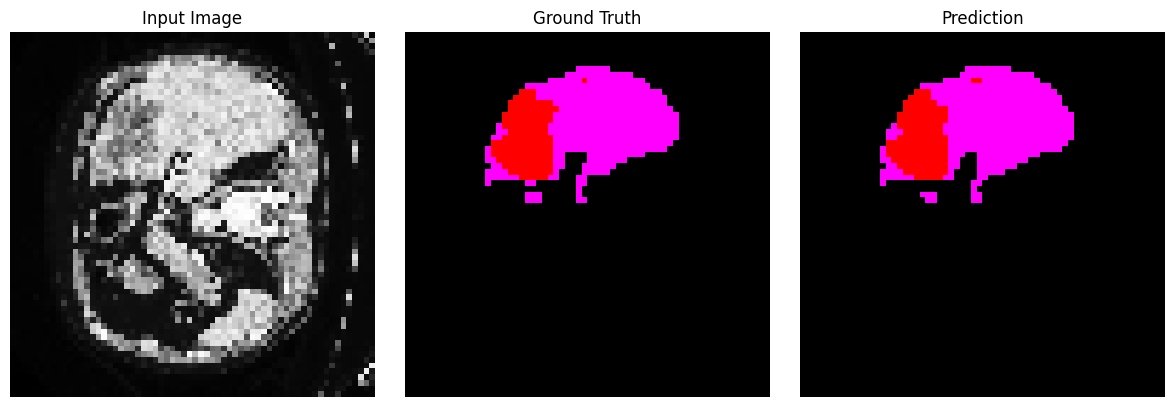

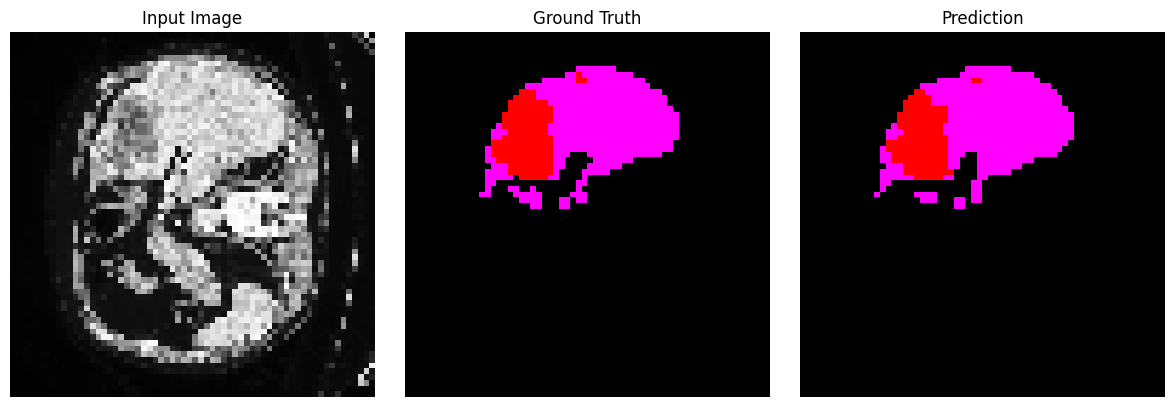

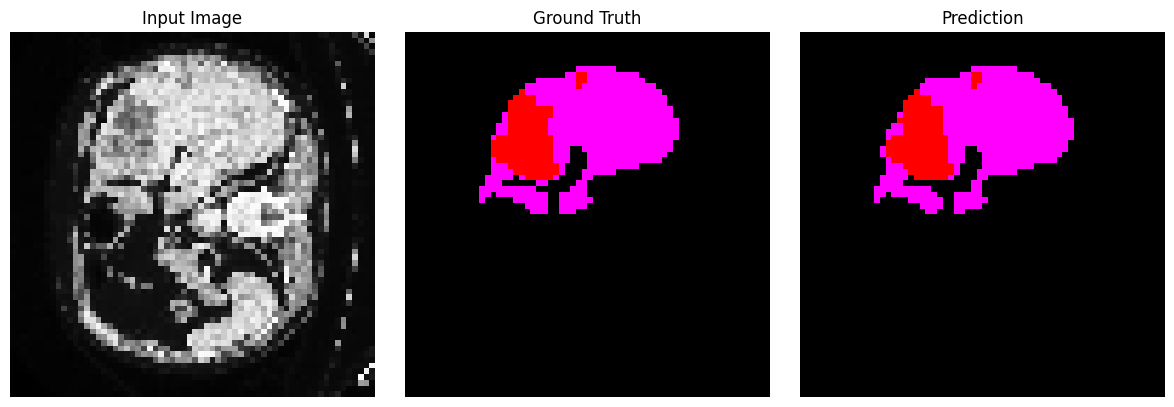

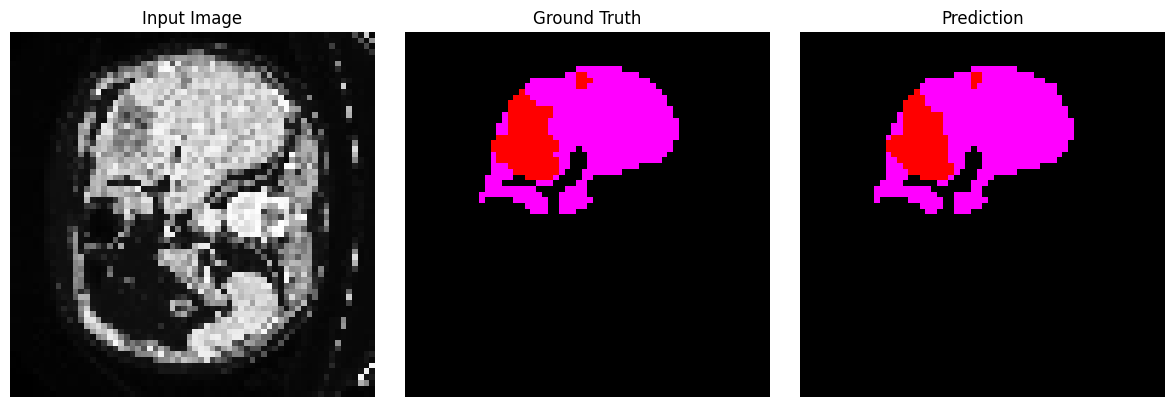

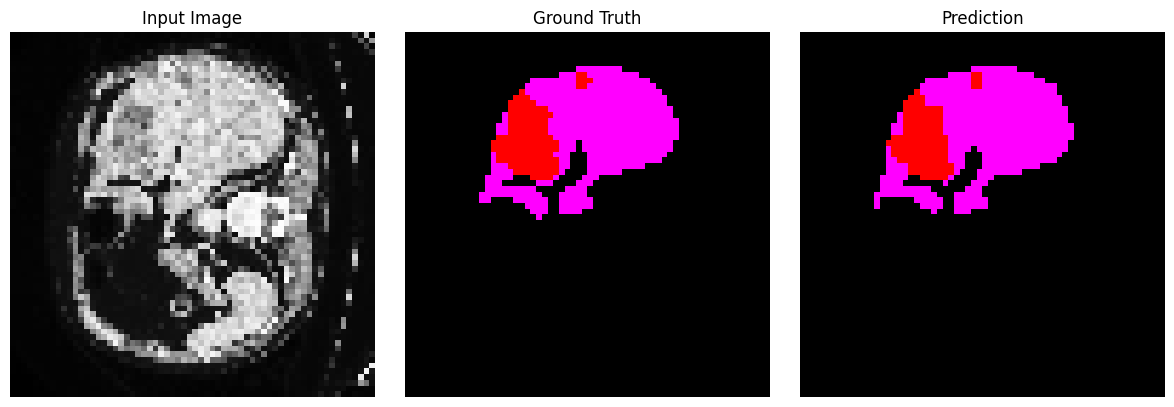

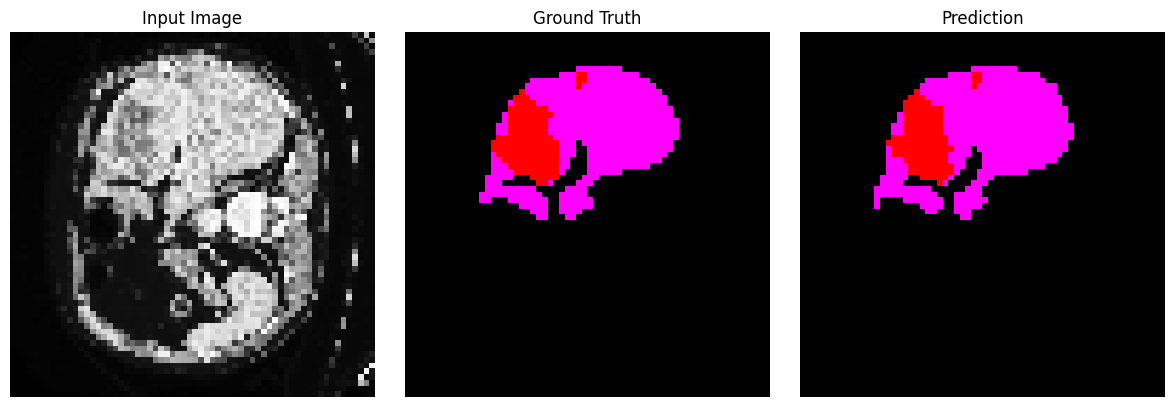

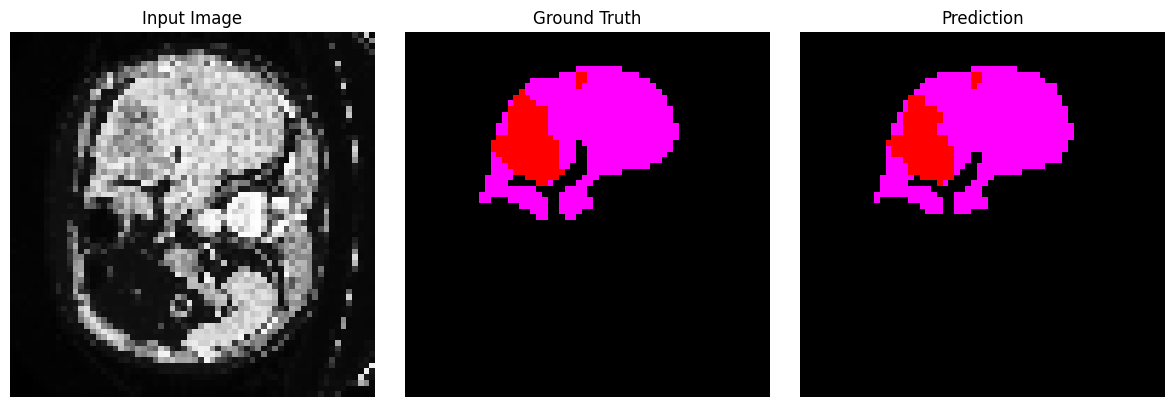

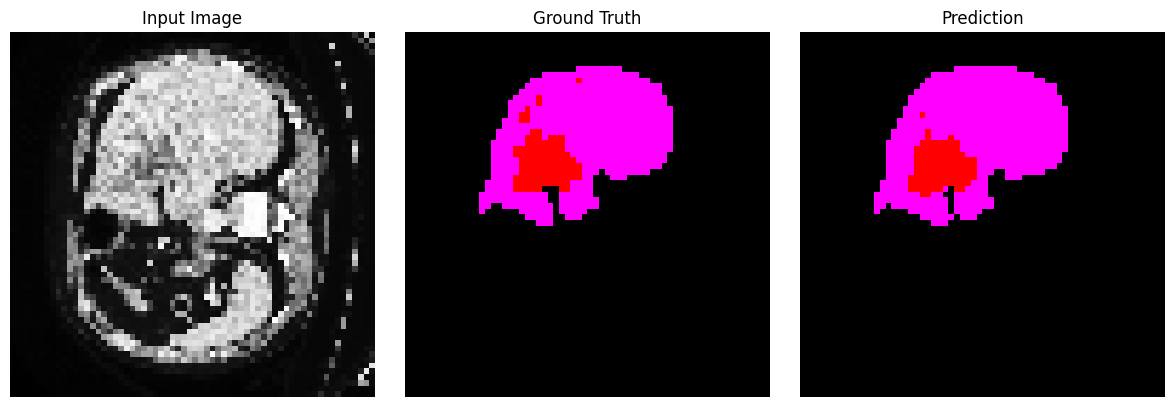

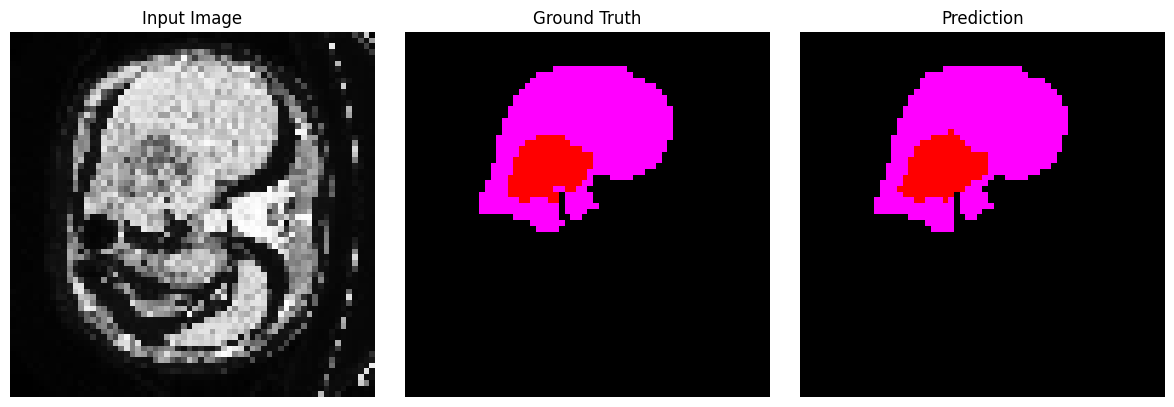

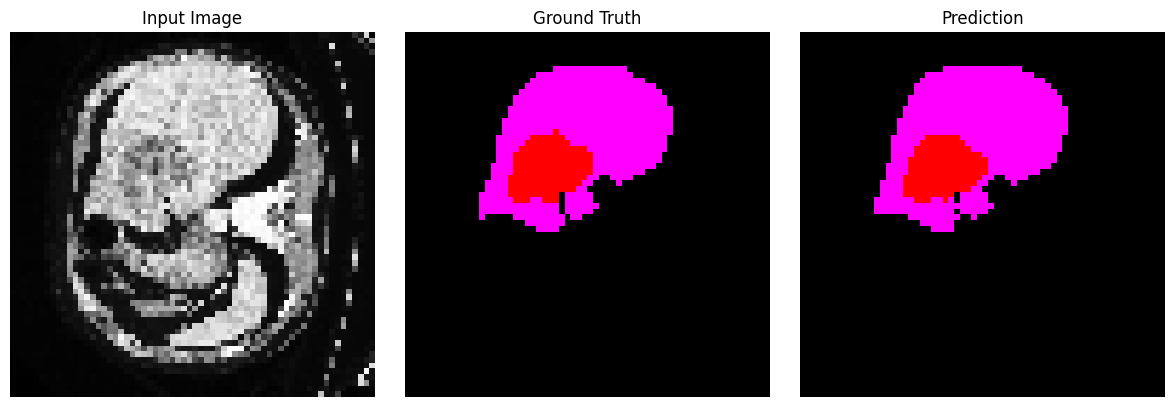

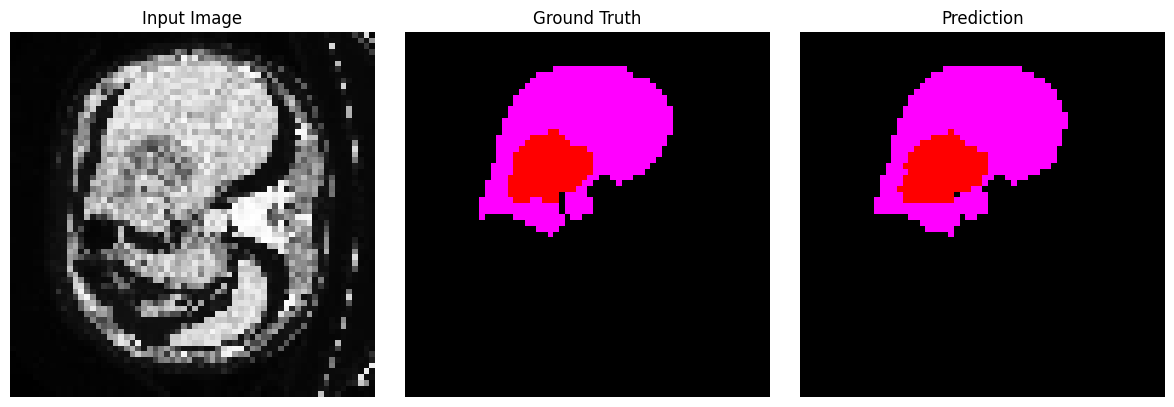

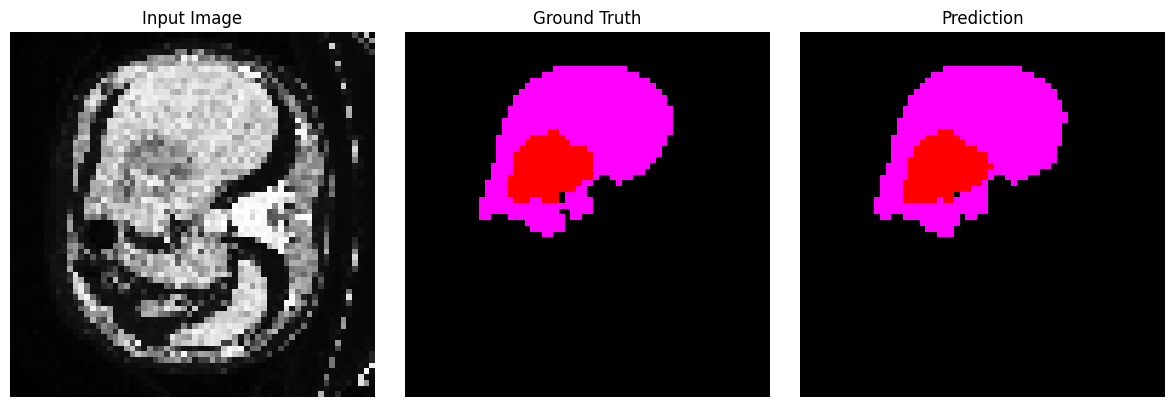

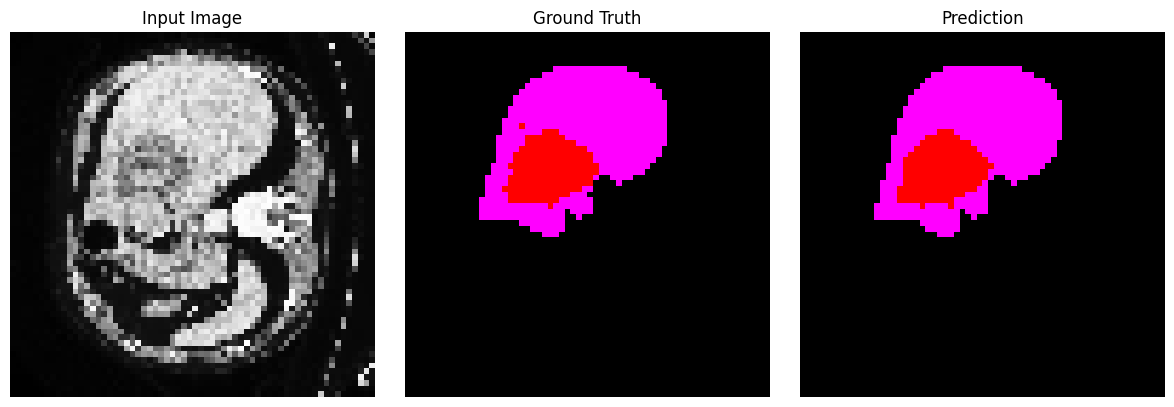

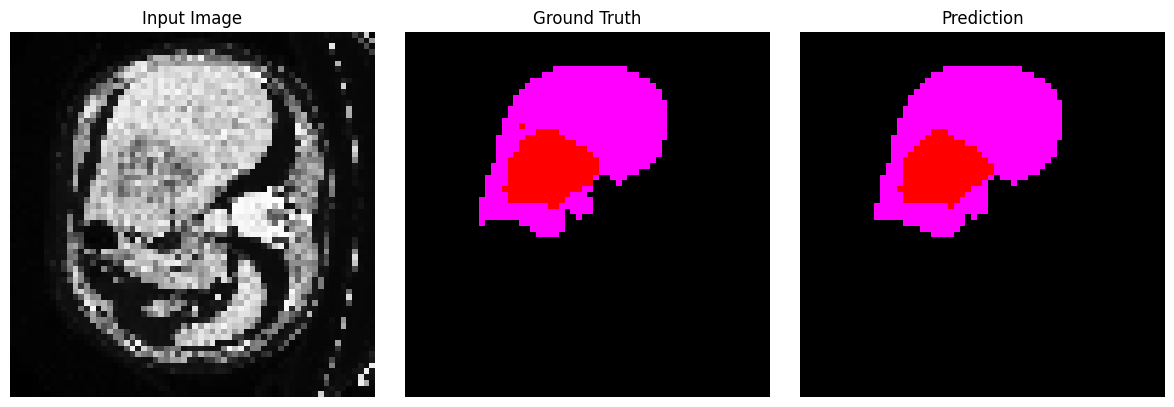

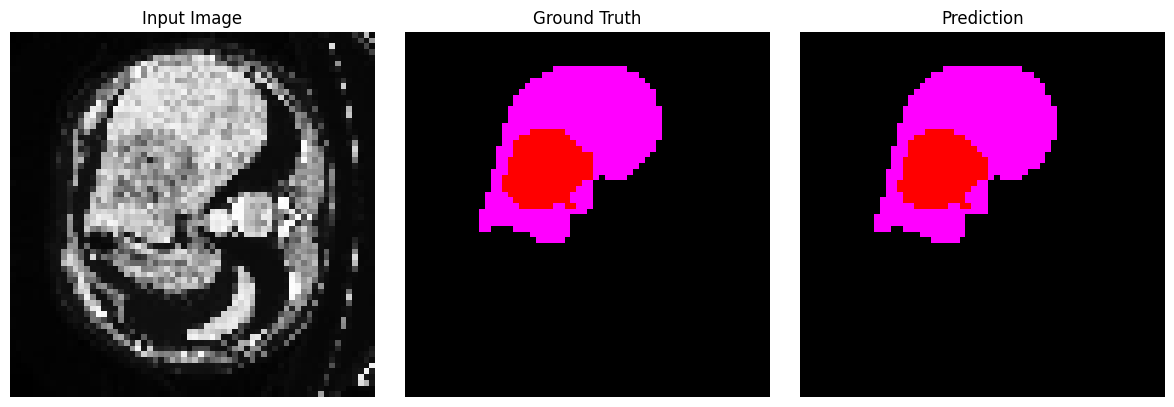

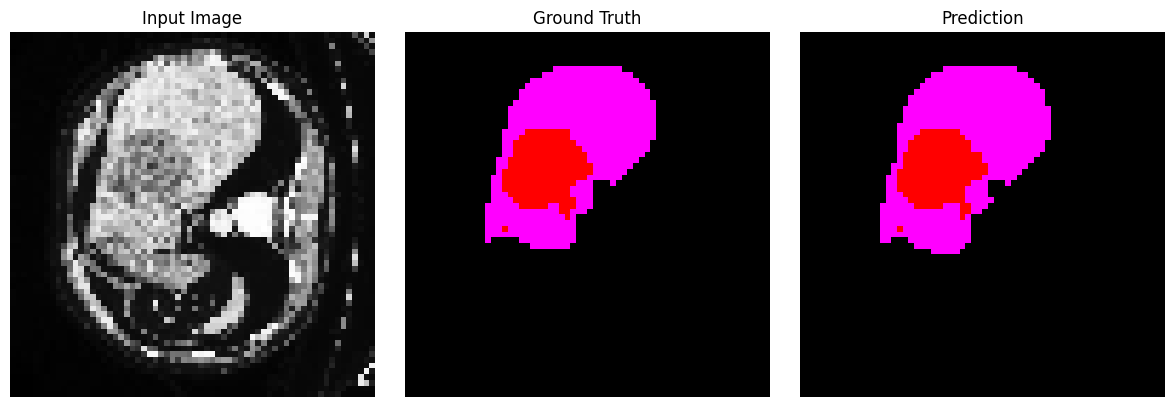

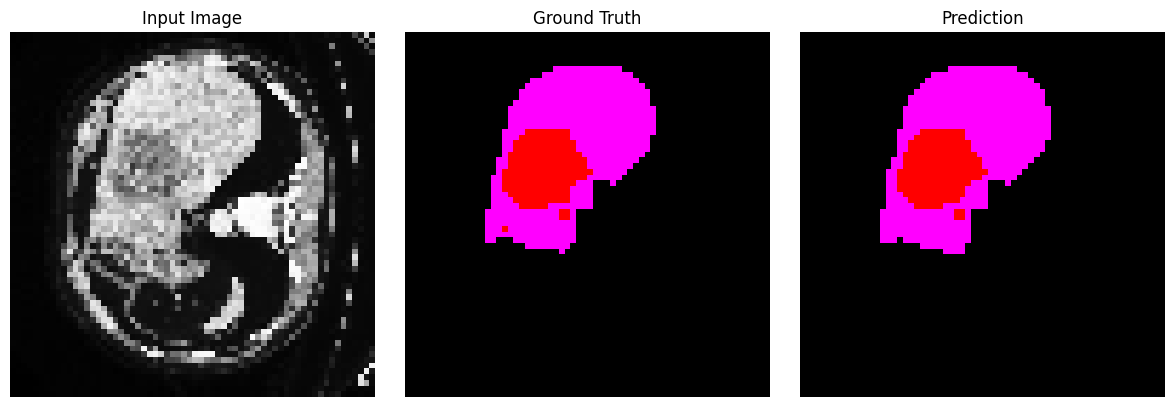

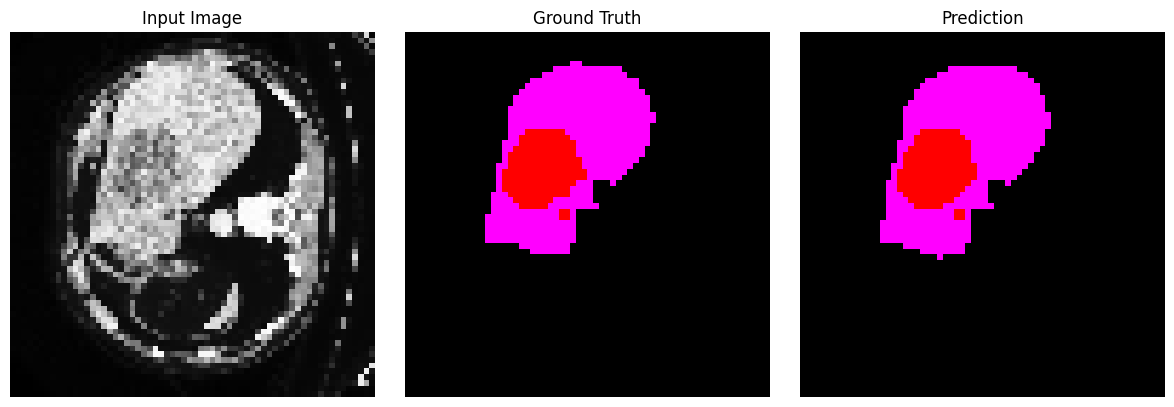

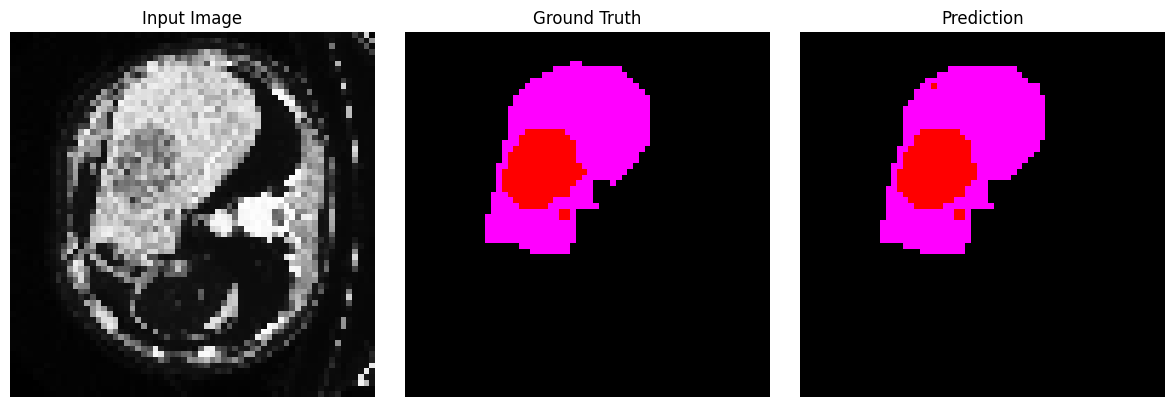

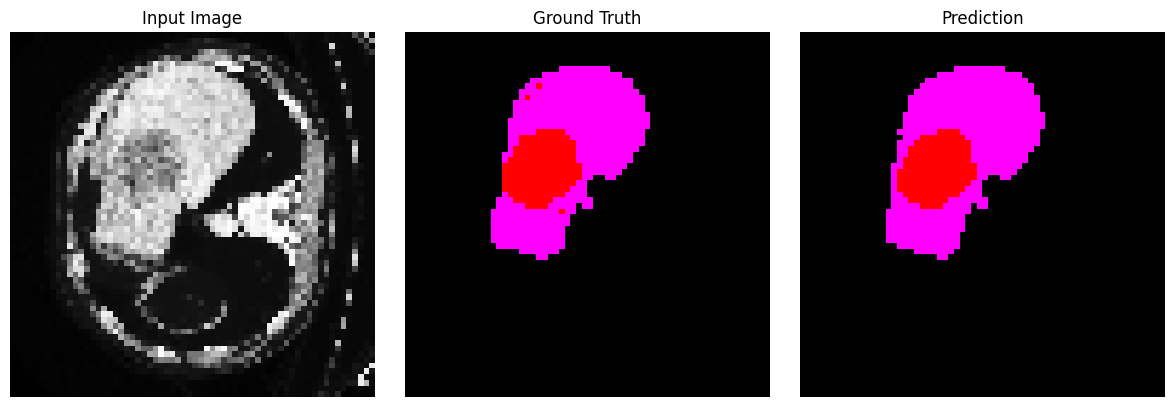

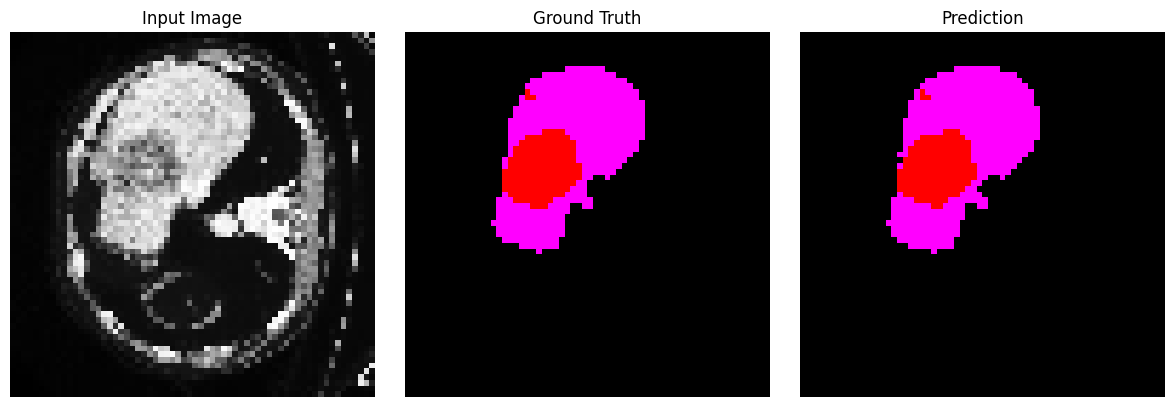

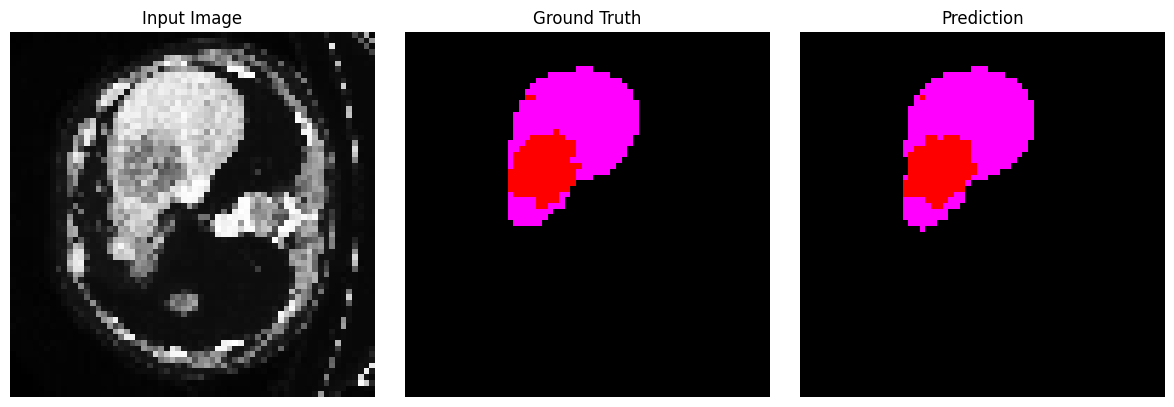

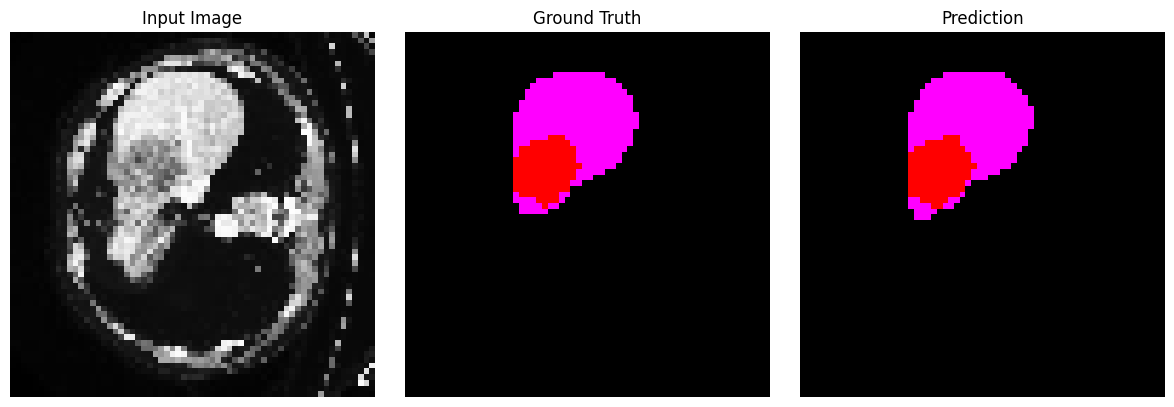

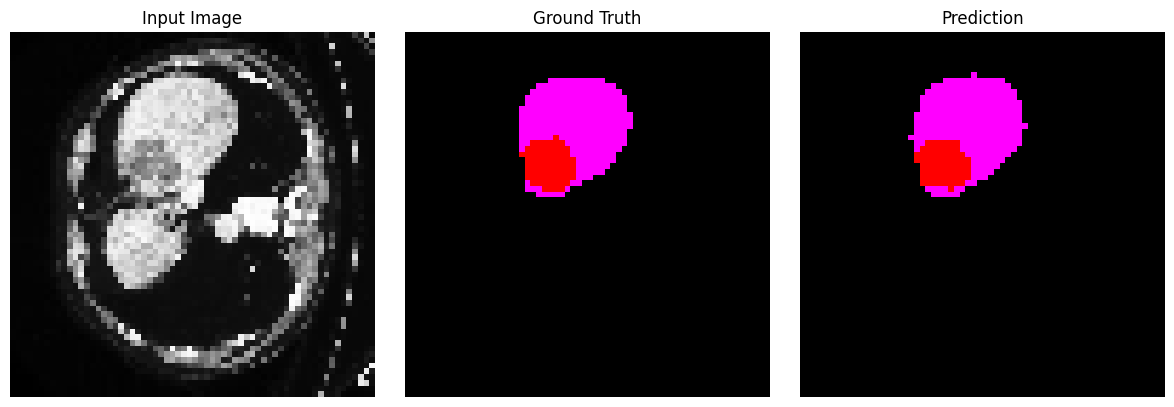

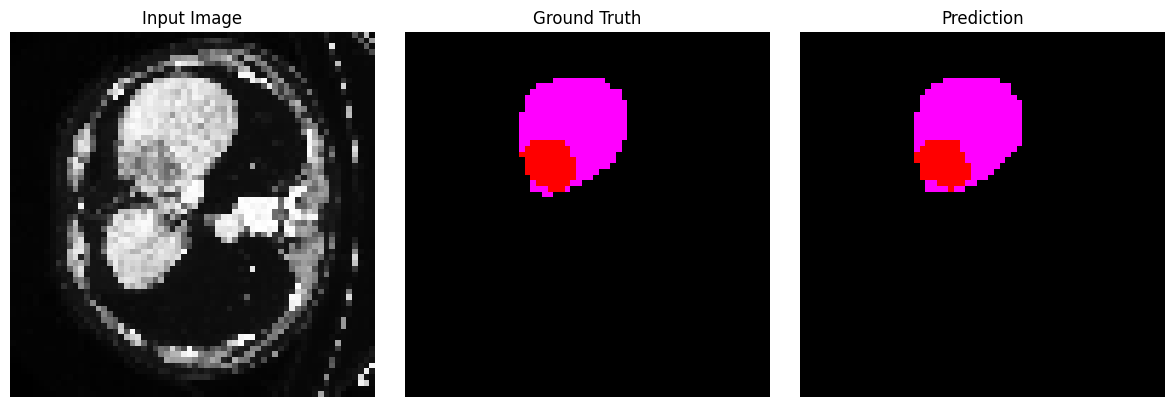

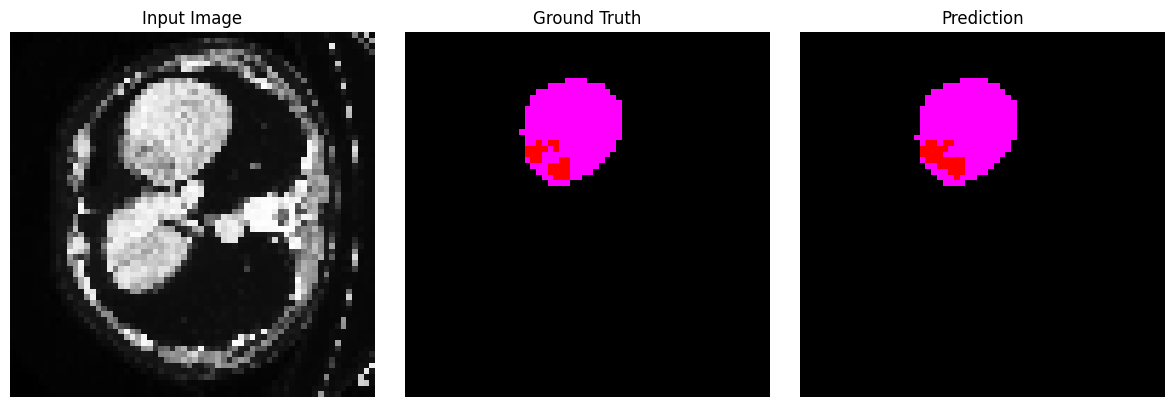

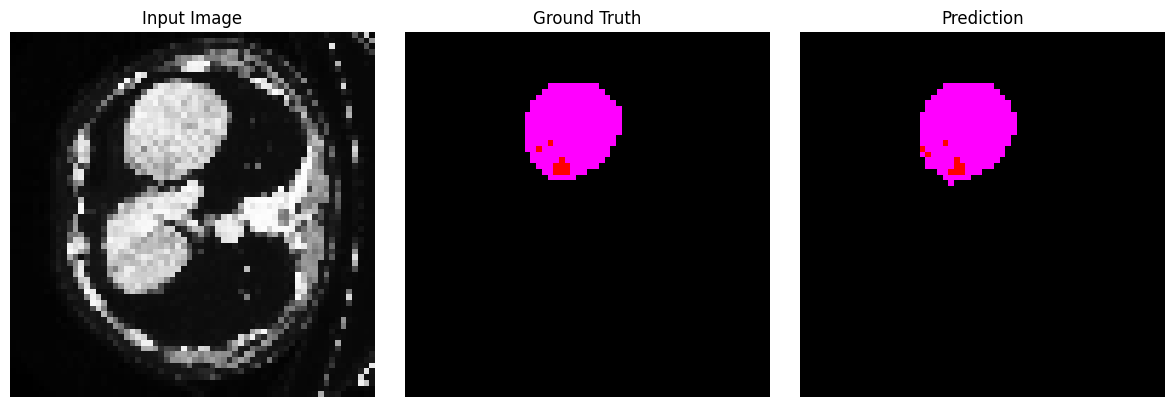

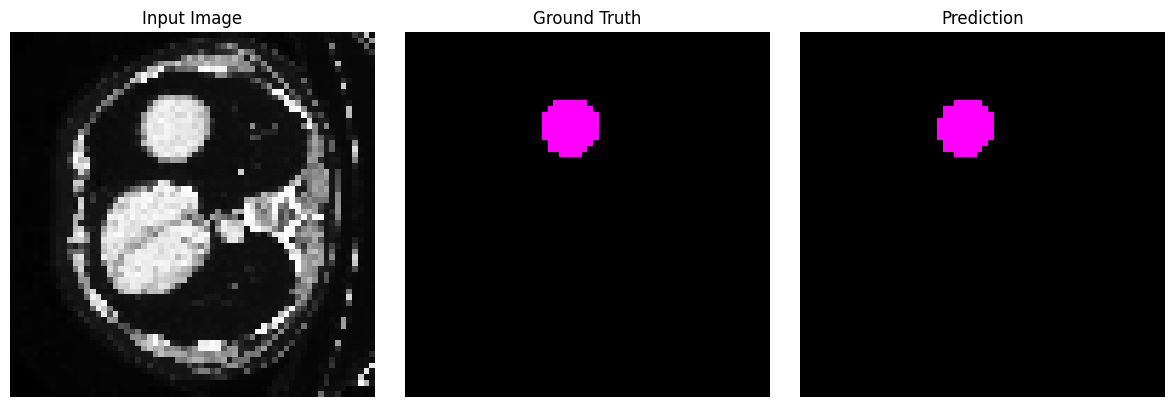

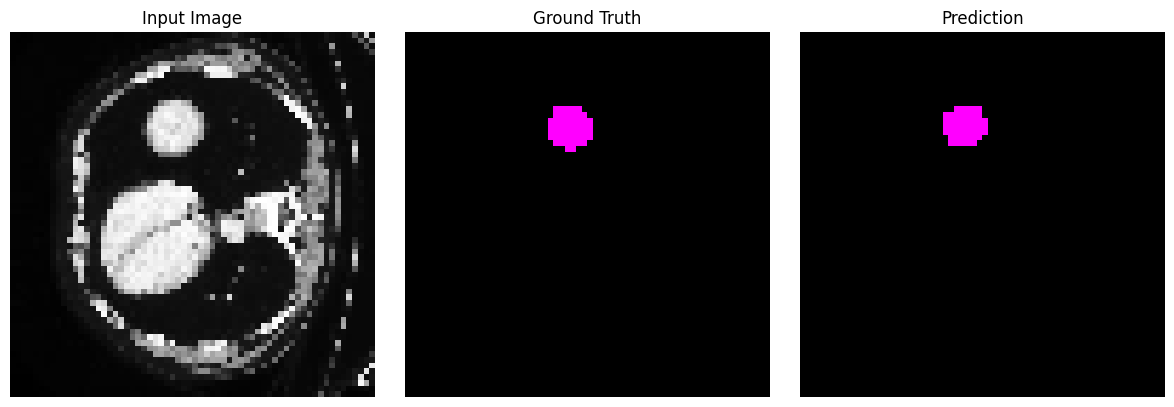

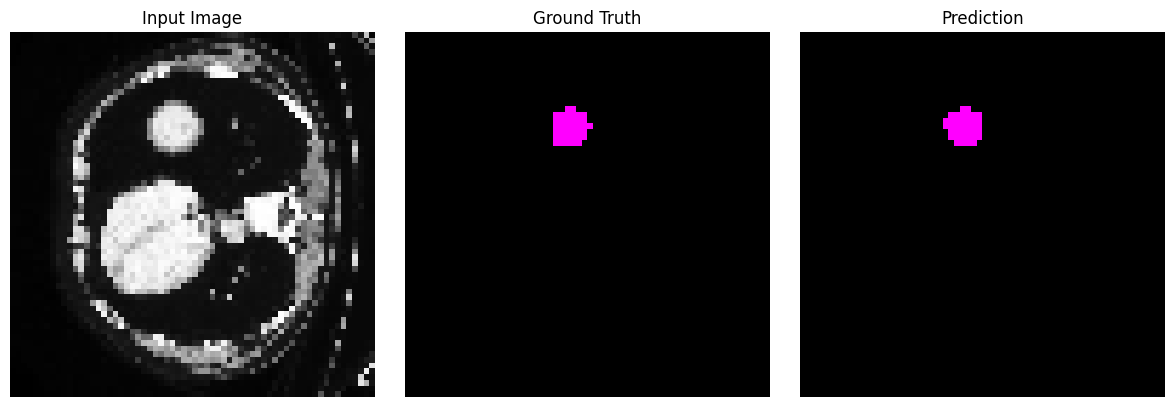

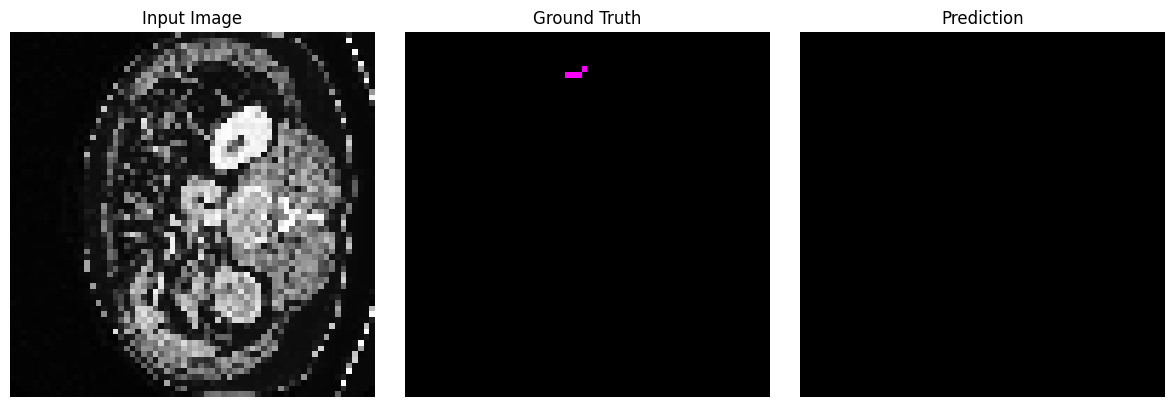

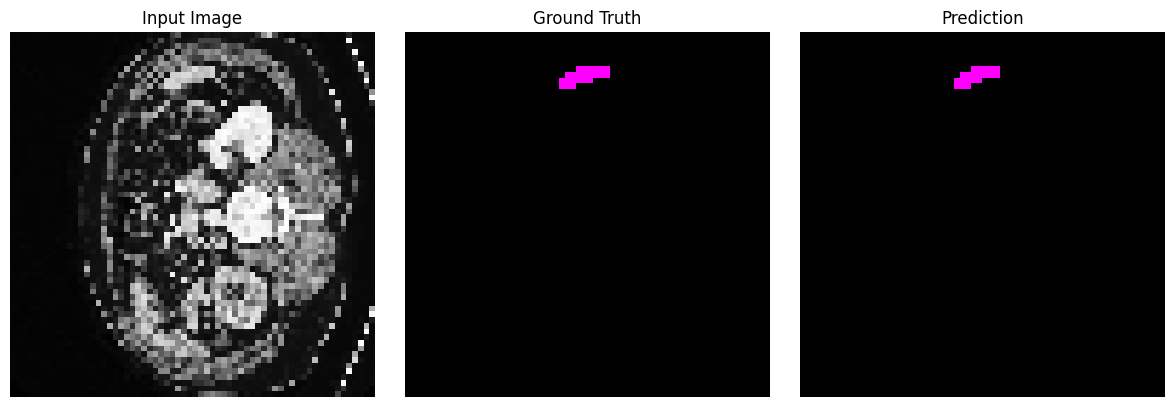

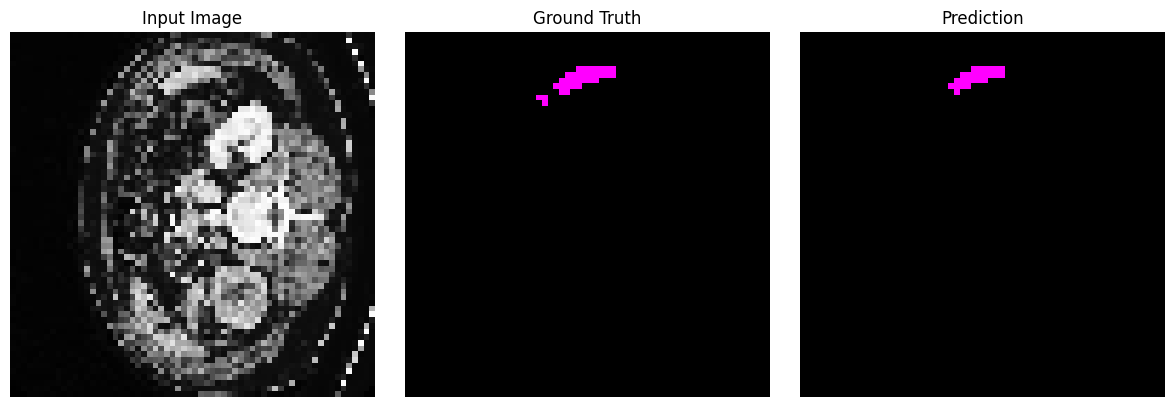

In [21]:
def run_inference_with_mask(model, dataloader, num_samples=5):
    model.eval()
    images_shown = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)  
            preds = torch.argmax(outputs, dim=1)
            
            images = images.cpu().numpy()
            labels = labels.cpu().numpy()
            preds = preds.cpu().numpy()
            
            for i in range(images.shape[0]):
                if np.sum(labels[i] > 0) == 0:
                    continue
                
                img = np.transpose(images[i], (1,2,0)) if images[i].shape[0]>1 else images[i,0]
                
                fig, axs = plt.subplots(1,3, figsize=(12,4))
                
                axs[0].imshow(img, cmap="gray")
                axs[0].set_title("Input Image")
                axs[0].axis('off')
                
                axs[1].imshow(colorize_mask(labels[i]))
                axs[1].set_title("Ground Truth")
                axs[1].axis('off')
                
                axs[2].imshow(colorize_mask(preds[i]))
                axs[2].set_title("Prediction")
                axs[2].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                images_shown += 1
                if images_shown >= num_samples:
                    return
run_inference_with_mask(model, val_loader, num_samples=50)

In [19]:
import torch
import torch.nn.functional as F

def dice_per_class(preds, targets, num_classes, eps=1e-7):
    targets = targets.long()  

    preds_onehot = F.one_hot(preds.argmax(dim=1), num_classes=num_classes).permute(0,3,1,2).float()
    targets_onehot = F.one_hot(targets, num_classes=num_classes).permute(0,3,1,2).float()

    dice_scores = []
    for c in range(num_classes):
        pred_c = preds_onehot[:, c]
        target_c = targets_onehot[:, c]

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + eps) / (union + eps)
        dice_scores.append(dice.item())

    return dice_scores

model.eval()
num_classes = 3  # 0: Background, 1: Liver, 2: Tumour

all_dice = torch.zeros(num_classes)
num_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)  # [B, C, H, W]
        batch_dice = dice_per_class(outputs, masks, num_classes=num_classes)
        all_dice += torch.tensor(batch_dice)
        num_batches += 1

avg_dice = (all_dice / num_batches).tolist()

organ_names = ["Background", "Liver", "Tumour"]
for name, dice in zip(organ_names, avg_dice):
    print(f"{name}: {dice*100:.2f}%")

Background: 99.95%
Liver: 97.19%
Tumour: 82.83%
